# KELS2013 재수 위험확률 · 보험료 산정
## 스코어카드 = 가구소득 + 학원밀집도지수 + 월교육비 (성적과 완전히 분리)

이번 판의 핵심 설계 원칙은 하나다. **"급락했는가"는 성적 추이(밴드)가 판정하고,
"급락한 사람 중 누가 더 위험한가"는 성적과 무관한 비성적·객관 지표 3개가 판정한다.**
같은 성적 데이터를 두 번 쓰지 않도록(순환 논리 방지) 완전히 분리했다.

| 역할 | 무엇으로 | 위치 |
|---|---|---|
| 급락 여부 판정 | 고1~고3 회차별 성적 추이 → 표준화 이탈 z | 밴드 (§4~5) |
| 개인 위험 차등 | **가구소득 · 학원밀집도지수 · 월교육비** | 스코어카드 (§8) |

### 이번 판에서 새로 지킨 원칙

1. **분석 파이프라인 맨 앞에서 80/20을 나눈다.** 밴드 회귀·임계값·스코어카드 계수는
   **학습셋(train)에서만** 추정하고, 검증셋(test)은 마지막 성능 확인에만 쓴다.
2. **단, 사고확률처럼 극히 드문 사건은 예외다.** 급락자가 전체 표본에서도 65명뿐인데
   80/20으로 자르면 검증셋에는 6~7명만 남는다. 이 정도로는 어떤 검증도 무의미해진다.
   그래서 **포트폴리오 확률(P(급락), P(재수\|급락))은 학습셋 전체로 안정적으로 추정**하고,
   **모형의 판별력(스코어카드 AUC, 머신러닝 비교)만 검증셋으로 엄격히 검사**하는 절충을 쓴다.
   이 절충의 근거는 §9에서 숫자로 보여준다.
3. **계수 b는 조정하지 않는다.** 표준화·정규화(L2)·Platt 보정을 전부 걷어내고
   `statsmodels.Logit`의 순수 최대우도추정값을 그대로 쓴다. 요율표에 실리는 식이
   곧 이 노트북의 계수와 정확히 같다.
4. **절편 a만 이동시킨다(로짓 시프트).** 모형이 주는 것은 P(재수)인데 필요한 건
   P(재수\|급락)이라 눈금만 옮긴다. 그 타당성은 §12에서 두 가지 방법으로 검정한다.

> 실행: 첫 코드 셀의 `BASE_DIR`만 KELS2013 .sav 폴더로 수정 → 위에서 아래로 순차 실행.

### 왜 이렇게 나눴는가 — 한 줄 요약

원래 KELS2005 분석에서는 성적 자체(사교육비 등)를 스코어카드에도, 급락 판정에도 같이 썼다.
그런데 같은 정보를 두 번 쓰면 **"급락도 성적, 개인차도 성적"**이 되어 순환논리가 생긴다.
그래서 이번 판은 역할을 완전히 나눴다 — **성적은 급락 여부(사건이 일어났는가)만 판정하고,
개인차(그 사건이 일어났을 때 재수까지 이어질 확률)는 성적과 무관한 경제·지역 지표가 판정한다.**


In [1]:
# ── 기본 설정 ──
import os, glob, warnings, numpy as np, pandas as pd
import statsmodels.api as sm, matplotlib.pyplot as plt, matplotlib as mpl, pyreadstat
from scipy.stats import binomtest
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)
mpl.rcParams["axes.unicode_minus"] = False
for _f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]:
    try: mpl.rcParams["font.family"] = _f; break
    except Exception: pass
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
NAVY, RED, GREEN, PURPLE, GREY, ORANGE = "#234A94", "#C0243F", "#1F7A52", "#B45FA0", "#93A6CE", "#E08000"

BASE_DIR = "/Users/iphonejjun/Desktop/한국교육종단연구2013/"   # ★ KELS2013 6~10차 .sav 폴더 (하위폴더까지 자동 탐색)
SAVS = sorted(set(glob.glob(os.path.join(BASE_DIR, "**", "*.sav"), recursive=True) +
                  glob.glob(os.path.join(BASE_DIR, "**", "*.SAV"), recursive=True)))
print(f"탐색된 .sav 파일 {len(SAVS)}개")

def find_sav(*keys):
    '파일명에 keys가 모두 들어간 .sav 경로를 찾는다'
    for p in SAVS:
        if all(k in os.path.basename(p) for k in keys): return p
    raise FileNotFoundError(f"{keys} 파일을 찾지 못함 — BASE_DIR을 확인하세요")

def load(keys, 이름표, lo=None, hi=None):
    '지정한 변수만 읽어 한국어 이름으로 바꾸고, 무응답 코드(음수)를 결측 처리한다'
    d, _ = pyreadstat.read_sav(find_sav(*keys), usecols=["L2SID"] + list(이름표))
    for c in 이름표:
        d[c] = pd.to_numeric(d[c], errors="coerce")
        d[c] = d[c].where(d[c] >= 0) if lo is None else d[c].where(d[c].between(lo, hi))
    return d.rename(columns={**이름표, "L2SID": "학생ID"})

탐색된 .sav 파일 46개


## ① 데이터 로드 — 회차 9개 + 재수 타깃

KELS2013에 실제로 존재하는 학력평가·모의평가는 정확히 9회다(11월 회차, 고3 3월은 없음).
고1(6차) 3·6·9월, 고2(7차) 3·6·9월, 고3(8차·9차) 5월·6월·9월모평.
각 회차 국·수·영 등급을 **정시 반영비중(국 .341 : 수 .366 : 영 .293)**으로 가중합해 **회차 종합점수 1개**로 만든다.

In [2]:
# ── 회차별 원자료 로드 (등급 1~9, 1등급이 최우수) ──
이름표_고1 = {f"L2Y6A01_{o}_{s}": f"고1_{ {1:'6월',2:'9월',3:'3월'}[o] }_{ {1:'국어',2:'수학',3:'영어'}[s] }"
              for o in (1,2,3) for s in (1,2,3)}
이름표_고2 = {f"L2Y7A01_{o}_{s}": f"고2_{ {1:'3월',2:'6월',3:'9월'}[o] }_{ {1:'국어',2:'수학',3:'영어'}[s] }"
              for o in (1,2,3) for s in (1,2,3)}
이름표_고3 = {"L2Y8A01_1_1":"고3_5월_국어","L2Y8A01_1_2_A":"고3_5월_수학가","L2Y8A01_1_2_B":"고3_5월_수학나","L2Y8A01_1_3":"고3_5월_영어",
              "L2Y8A01_2_1":"고3_6월_국어","L2Y8A01_2_2_A":"고3_6월_수학가","L2Y8A01_2_2_B":"고3_6월_수학나","L2Y8A01_2_3":"고3_6월_영어"}
이름표_9차 = {"L2Y9C30_1_1B":"고3_9월모평_국어","L2Y9C30_1_2_1B":"고3_9월모평_수학가","L2Y9C30_1_2_2B":"고3_9월모평_수학나","L2Y9C30_1_3B":"고3_9월모평_영어",
              "L2Y9C31_1_1B":"수능_국어",      "L2Y9C31_1_2_1B":"수능_수학가",      "L2Y9C31_1_2_2B":"수능_수학나",      "L2Y9C31_1_3B":"수능_영어"}

성적_고1 = load(("L2Y6A",), 이름표_고1, 1, 9)
성적_고2 = load(("L2Y7A",), 이름표_고2, 1, 9)
성적_고3 = load(("L2Y8A",), 이름표_고3, 1, 9)
성적_9차 = load(("L2Y9",),  이름표_9차, 1, 9)
응시_수능 = load(("L2Y9",),  {"L2Y9C31":  "수능응시여부"})
응시_재수 = load(("L2Y10",), {"L2Y10C31": "재응시여부"})   # ★ 2021.11 수능 응시 = 재수/반수

원자료 = (성적_고1.merge(성적_고2, on="학생ID").merge(성적_고3, on="학생ID")
              .merge(성적_9차, on="학생ID").merge(응시_수능, on="학생ID").merge(응시_재수, on="학생ID"))
print(f"df shape (병합 직후) = {원자료.shape}")
원자료.head(3)

df shape (병합 직후) = (7324, 37)


,학생ID,고1_6월_국어,고1_6월_수학,고1_6월_영어,고1_9월_국어,고1_9월_수학,고1_9월_영어,고1_3월_국어,고1_3월_수학,고1_3월_영어,고2_3월_국어,고2_3월_수학,고2_3월_영어,고2_6월_국어,고2_6월_수학,고2_6월_영어,고2_9월_국어,고2_9월_수학,고2_9월_영어,고3_5월_국어,고3_5월_수학가,고3_5월_수학나,고3_5월_영어,고3_6월_국어,고3_6월_수학가,고3_6월_수학나,고3_6월_영어,고3_9월모평_국어,고3_9월모평_수학가,고3_9월모평_수학나,고3_9월모평_영어,수능_국어,수능_수학가,수능_수학나,수능_영어,수능응시여부,재응시여부
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
1,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
2,3.0,NaN,NaN,NaN,6.0,8.0,9.0,7.0,5.0,8.0,7.0,5.0,9.0,NaN,NaN,NaN,7.0,6.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


In [3]:
# ── 회차 종합점수: 과목 가중합 (관측 과목만으로 비중 재정규화) ──
반영비중 = {"국어": 0.341, "수학": 0.366, "영어": 0.293}

def 회차종합(df, 국, 수, 영):
    수값 = df[list(수)].mean(axis=1) if isinstance(수, tuple) else df[수]
    P = pd.DataFrame({"국어": df[국], "수학": 수값, "영어": df[영]})
    가중 = pd.DataFrame({c: np.where(P[c].notna(), 반영비중[c], 0.0) for c in P}, index=P.index)
    합 = 가중.sum(axis=1)
    return (P.fillna(0) * 가중).sum(axis=1) / 합.where(합 > 0)

회차정의 = {
    "고1_3월": ("고1_3월_국어","고1_3월_수학","고1_3월_영어"), "고1_6월": ("고1_6월_국어","고1_6월_수학","고1_6월_영어"),
    "고1_9월": ("고1_9월_국어","고1_9월_수학","고1_9월_영어"), "고2_3월": ("고2_3월_국어","고2_3월_수학","고2_3월_영어"),
    "고2_6월": ("고2_6월_국어","고2_6월_수학","고2_6월_영어"), "고2_9월": ("고2_9월_국어","고2_9월_수학","고2_9월_영어"),
    "고3_5월": ("고3_5월_국어", ("고3_5월_수학가","고3_5월_수학나"), "고3_5월_영어"),
    "고3_6월": ("고3_6월_국어", ("고3_6월_수학가","고3_6월_수학나"), "고3_6월_영어"),
    "고3_9월모평": ("고3_9월모평_국어", ("고3_9월모평_수학가","고3_9월모평_수학나"), "고3_9월모평_영어"),
    "수능": ("수능_국어", ("수능_수학가","수능_수학나"), "수능_영어"),
}
for 이름, t in 회차정의.items():
    원자료[이름] = 회차종합(원자료, *t)
회차 = [c for c in 회차정의 if c != "수능"]
print("회차 변수 9개:", 회차)

회차 변수 9개: ['고1_3월', '고1_6월', '고1_9월', '고2_3월', '고2_6월', '고2_9월', '고3_5월', '고3_6월', '고3_9월모평']


## ② 전처리 & EDA — df 생김새를 눈으로 확인

표본을 좁히기 전에 먼저 **데이터가 어떻게 생겼는지** 본다.

In [4]:
# 필터링·보간 이전, 병합만 마친 원자료의 전체 모습을 먼저 눈으로 확인
print(f"df shape = {원자료.shape}")
print(f"\n[컬럼 타입 요약]"); print(원자료[회차+["수능"]].describe().T.round(2))
print(f"\n[회차별 결측률]"); print((원자료[회차].isna().mean()*100).round(1).astype(str).add("%"))
print(f"\n[재응시여부 값 분포]"); print(원자료["재응시여부"].value_counts(dropna=False))

df shape = (7324, 47)

[컬럼 타입 요약]
          count  mean   std  min   25%   50%   75%  max
고1_3월    1490.0  4.86  1.81  1.0  3.56  4.93  6.26  9.0
고1_6월    4196.0  4.79  1.78  1.0  3.46  4.73  6.02  9.0
고1_9월    4007.0  4.75  1.83  1.0  3.37  4.71  6.22  9.0
고2_3월    3772.0  4.76  1.79  1.0  3.43  4.73  6.02  9.0
고2_6월    4174.0  4.83  1.74  1.0  3.63  4.90  6.05  9.0
고2_9월    3907.0  4.76  1.76  1.0  3.40  4.73  6.02  9.0
고3_5월    4474.0  4.72  1.75  1.0  3.41  4.71  6.00  9.0
고3_6월    4752.0  5.02  1.73  1.0  3.73  5.00  6.29  9.0
고3_9월모평  3790.0  3.91  1.46  1.0  2.96  3.76  4.90  9.0
수능       3497.0  4.06  1.40  1.0  3.07  4.03  5.00  9.0

[회차별 결측률]
고1_3월      79.7%
고1_6월      42.7%
고1_9월      45.3%
고2_3월      48.5%
고2_6월      43.0%
고2_9월      46.7%
고3_5월      38.9%
고3_6월      35.1%
고3_9월모평    48.3%
dtype: object

[재응시여부 값 분포]
재응시여부
2.0    4147
NaN    2103
1.0    1074
Name: count, dtype: int64


In [5]:
# 발표용 색상
DARK_GREEN  = "#2E7D32"
LIGHT_GREEN = "#A5D6A7"
YELLOW      = "#FBC02D"
LIGHT_YELLOW = "#FFF59D"
PINK        = "#EC407A"

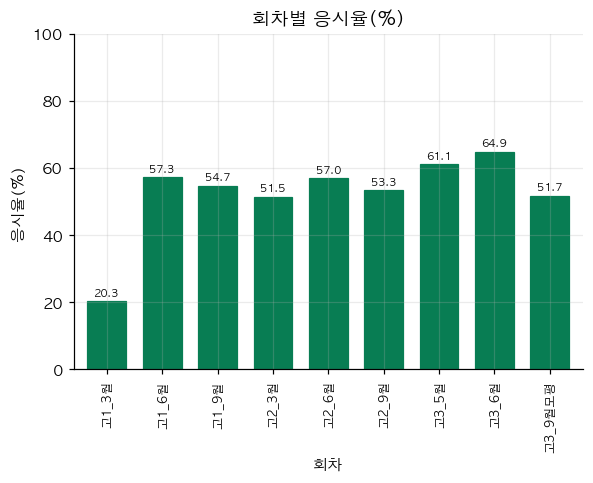

In [6]:
응시율 = 원자료[회차].notna().mean() * 100

fig, ax = plt.subplots(figsize=(5.5, 4.5))

응시율.plot(
    kind="bar",
    ax=ax,
    color="#087d53",
    edgecolor="#087d53",
    linewidth=0.8,
    width=0.7
)

ax.set_title("회차별 응시율(%)")
ax.set_xlabel("회차")
ax.set_ylabel("응시율(%)")
ax.set_ylim(0, max(100, 응시율.max() * 1.15))

ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=8
)

for i, value in enumerate(응시율):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.tight_layout()
plt.show()

In [7]:
응시율.plot(
    kind="bar",
    ax=ax,
    color="#ddfd86",
    edgecolor="#087d53",
    linewidth=0.8,
    width=0.7
)

<Axes: title={'center': '회차별 응시율(%)'}, xlabel='회차', ylabel='응시율(%)'>

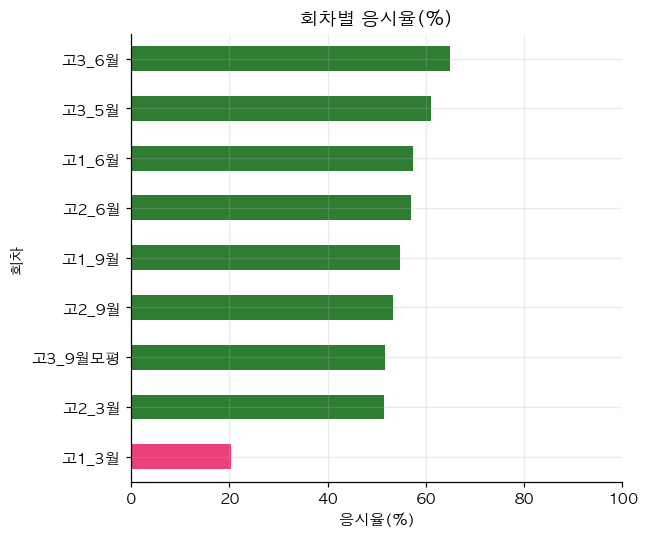

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

colors = [
    PINK if value < 30 else DARK_GREEN
    for value in 응시율
]

응시율.sort_values().plot(
    kind="barh",
    ax=ax,
    color=[PINK if v < 30 else DARK_GREEN
           for v in 응시율.sort_values()]
)

ax.set_title("회차별 응시율(%)")
ax.set_xlabel("응시율(%)")
ax.set_ylabel("회차")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

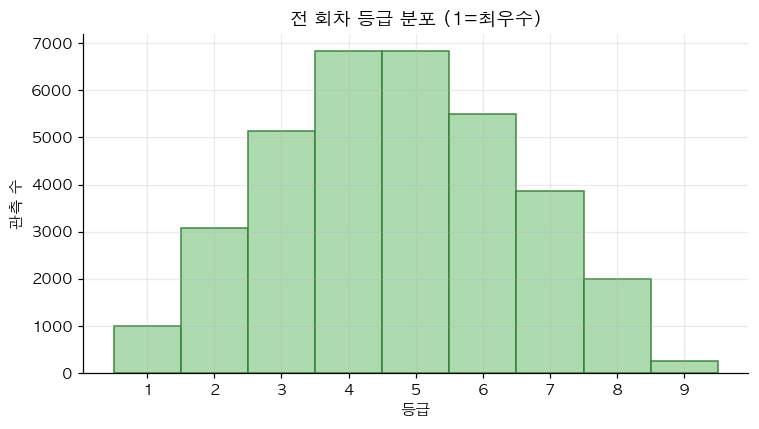

In [9]:
전체_등급 = (
    원자료[회차]
    .melt(value_name="등급")["등급"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    전체_등급,
    bins=np.arange(0.5, 10.5, 1),
    color=LIGHT_GREEN,
    edgecolor=DARK_GREEN,
    alpha=0.9
)

ax.set_title("전 회차 등급 분포 (1=최우수)")
ax.set_xlabel("등급")
ax.set_ylabel("관측 수")
ax.set_xticks(range(1, 10))

plt.tight_layout()
plt.show()

In [10]:
# 개인별 실제 응시 회차 수
원자료["관측회차수"] = 원자료[회차].notna().sum(axis=1)

# 5회차 이상 응시자 선별
분석자료 = 원자료.loc[원자료["관측회차수"] >= 5].copy()

# 보간 전 데이터 보관
보간전 = 분석자료[회차].copy()

# 개인별로 회차 순서에 따라 선형보간
# limit_direction="both":
# 중간 결측은 선형보간하고, 양 끝 결측은 가장 가까운 관측값으로 채움
보간후 = 보간전.interpolate(
    method="linear",
    axis=1,
    limit_direction="both"
)

# 원본 분석자료에 반영
분석자료.loc[:, 회차] = 보간후

In [11]:
전처리_요약 = pd.DataFrame({
    "구분": [
        "전체 표본",
        "5회차 이상 응시 표본",
        "선별 전 등급 결측치",
        "선별 후·보간 전 결측치",
        "선형보간 후 결측치"
    ],
    "값": [
        len(원자료),
        len(분석자료),
        int(원자료[회차].isna().sum().sum()),
        int(보간전.isna().sum().sum()),
        int(보간후.isna().sum().sum())
    ]
})

print(전처리_요약.to_string(index=False))

           구분     값
        전체 표본  7324
 5회차 이상 응시 표본  4459
  선별 전 등급 결측치 31354
선별 후·보간 전 결측치  8549
   선형보간 후 결측치     0


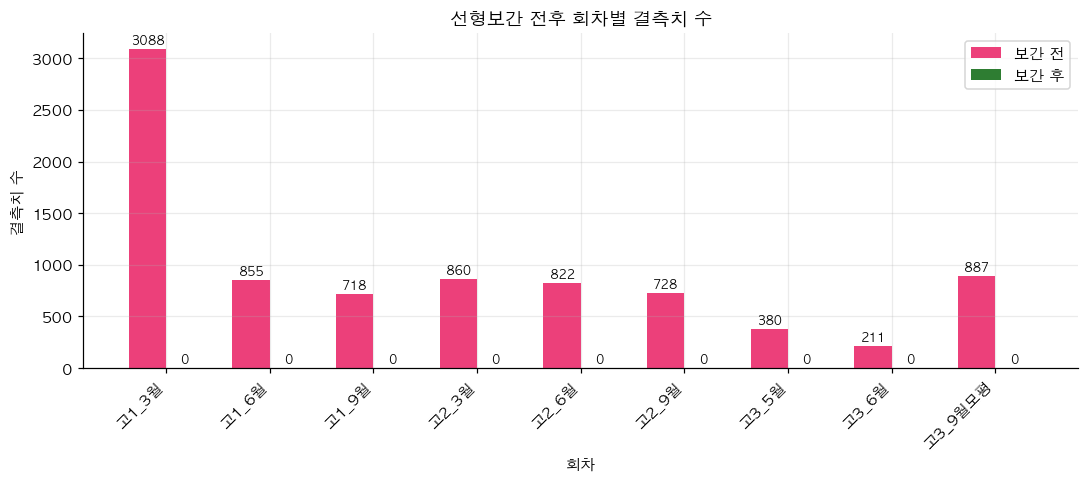

In [12]:
x = np.arange(len(회차))
width = 0.36

보간전_결측 = 보간전.isna().sum()
보간후_결측 = 보간후.isna().sum()

fig, ax = plt.subplots(figsize=(10, 4.5))

bars1 = ax.bar(
    x - width / 2,
    보간전_결측,
    width,
    label="보간 전",
    color=PINK
)

bars2 = ax.bar(
    x + width / 2,
    보간후_결측,
    width,
    label="보간 후",
    color=DARK_GREEN
)

ax.set_title("선형보간 전후 회차별 결측치 수")
ax.set_xlabel("회차")
ax.set_ylabel("결측치 수")
ax.set_xticks(x)
ax.set_xticklabels(회차, rotation=45, ha="right")
ax.legend()

ax.bar_label(bars1, padding=2, fontsize=8)
ax.bar_label(bars2, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# 출력할 학생 ID 지정
예시_index = [8, 9,13]

# 해당 학생들의 보간 전·후 자료를 행 방향으로 구성
예시목록 = []

for idx in 예시_index:
    before_row = pd.DataFrame(
        [보간전.loc[idx]],
        index=pd.MultiIndex.from_tuples(
            [(idx, "보간 전")],
            names=["학생ID", "구분"]
        )
    )

    after_row = pd.DataFrame(
        [보간후.loc[idx]],
        index=pd.MultiIndex.from_tuples(
            [(idx, "보간 후")],
            names=["학생ID", "구분"]
        )
    )

    예시목록.extend([before_row, after_row])

보간예시 = pd.concat(예시목록).round(2)

# 회차 이름 변경
보간예시 = 보간예시.rename(
    columns={"고3_9월모평": "고3_9월"}
)

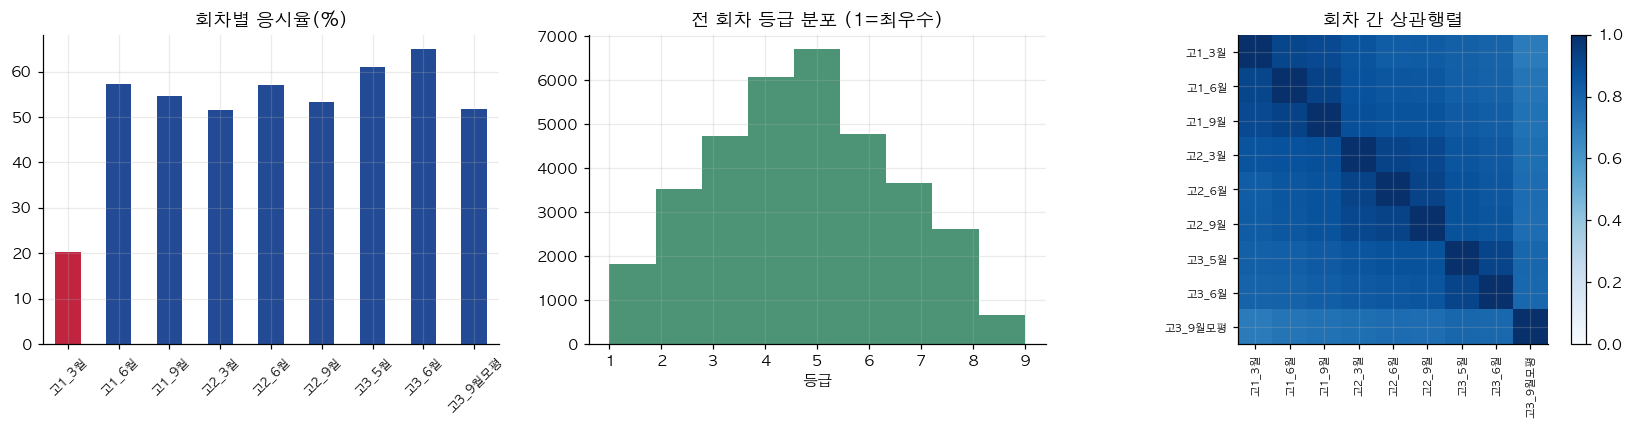

※ 인접 회차(예: 고3_5월-6월)일수록 상관이 높다 — 성적이 급변하기보다 서서히 이동한다는 뜻.


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
(원자료[회차].notna().mean()*100).plot(kind="bar", ax=ax[0], color=[RED if v<30 else NAVY for v in (원자료[회차].notna().mean()*100)])
ax[0].set_title("회차별 응시율(%)"); ax[0].tick_params(axis="x", labelrotation=45, labelsize=8)
원자료[회차].melt(value_name="등급")["등급"].dropna().hist(bins=9, ax=ax[1], color=GREEN, alpha=.8)
ax[1].set_title("전 회차 등급 분포 (1=최우수)"); ax[1].set_xlabel("등급")
corr = 원자료[회차].corr()
im = ax[2].imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax[2].set_xticks(range(len(회차))); ax[2].set_xticklabels(회차, rotation=90, fontsize=7)
ax[2].set_yticks(range(len(회차))); ax[2].set_yticklabels(회차, fontsize=7)
ax[2].set_title("회차 간 상관행렬"); plt.colorbar(im, ax=ax[2], fraction=.046)
plt.tight_layout(); plt.show()
print("※ 인접 회차(예: 고3_5월-6월)일수록 상관이 높다 — 성적이 급변하기보다 서서히 이동한다는 뜻.")

### 표본 규칙 — 9회차 중 5회 이상 관측(결측 50% 미만)

완비(9회 전부)만 쓰면 표본이 553명(재수율 21.5%)으로 무너지고 선택편향이 생긴다
(회차를 많이 응시한 학생일수록 재수를 덜 하는 경향). **5회 이상**을 기준으로 삼는다.
결측 회차는 **시간순으로 늘어놓고 앞뒤 관측값을 선형보간**해 채운다(성적 궤적을 보존하기 위함).

In [15]:
# ① 2020.12 수능에 실제로 응시했고 ② 10차 재응시 문항에 응답했고 ③ 수능 등급이 있는 학생만 남긴다
d = 원자료[(원자료["수능응시여부"] == 1) & 원자료["재응시여부"].isin([1, 2]) & 원자료["수능"].notna()].copy()
d["관측회차수"] = d[회차].notna().sum(axis=1)
단계 = [("전체 패널", len(원자료)), ("+ 수능응시·재응시응답·수능등급", len(d)),
        ("+ 9회차 중 5회 이상", int((d["관측회차수"] >= 5).sum()))]
d = d[d["관측회차수"] >= 5].reset_index(drop=True)
d["재수"] = (d["재응시여부"] == 1).astype(float)

대치여부 = d[회차].isna()
d[회차] = d[회차].interpolate(axis=1, method="linear", limit_direction="both")   # 전후 회차 선형보간

print(f"★ df shape (최종 분석표본) = {d.shape}")
print(f"재수율 {d['재수'].mean()*100:.1f}% · 결측 대치 {int(대치여부.values.sum()):,}셀({대치여부.values.mean()*100:.1f}%)")
d[["학생ID","재수"]+회차].head(5)

★ df shape (최종 분석표본) = (2938, 49)
재수율 28.1% · 결측 대치 5,310셀(20.1%)


,학생ID,재수,고1_3월,고1_6월,고1_9월,고2_3월,고2_6월,고2_9월,고3_5월,고3_6월,고3_9월모평
0,6.0,0.0,4.000,4.000,4.000,3.634,3.9875,4.341,4.341000,5.730000,4.414
1,10.0,0.0,4.561,4.744,4.927,6.195,7.4270,8.659,6.788667,4.918333,3.048
2,14.0,0.0,3.439,3.439,3.439,4.341,4.1830,4.025,3.341000,4.000000,3.000
3,17.0,0.0,5.634,5.634,5.634,5.341,5.6945,6.048,4.707000,5.414000,4.316
4,22.0,0.0,6.268,6.268,6.268,5.902,5.6215,5.341,5.316000,5.975000,5.293


### 클린 데이터셋 — 안 쓰이는 원본 컬럼 제거 후 CSV로 저장

지금까지 로드한 `원자료`에는 회차 종합점수를 만드는 데만 쓰인 **과목별 원본 컬럼**
(예: `고1_3월_국어`, `수능_수학가`)이 30개 넘게 섞여 있다. 이후 분석에서는 전혀 안 쓰이므로,
**5회차 이상 관측된 학생만 남기고, 회차 종합점수(9개) + 수능 + 재수 타깃만 남긴 클린 버전**을 따로 만들어 저장한다.

In [16]:
필요컬럼 = ["학생ID", "관측회차수", "재수"] + 회차 + ["수능"]
클린 = d[필요컬럼].copy()

print(f"클린 데이터셋 shape = {클린.shape}")
print(f"결측 총합 = {클린.isna().sum().sum()}  (0이어야 정상 — 회차는 선형보간, 나머지는 원래 완비)")
display(클린.head())

저장경로 = "KELS2013_클린_데이터셋.csv"   # 노트북과 같은 폴더에 저장(경로 이식성 위해 상대경로 사용)
클린.to_csv(저장경로, index=False, encoding="utf-8-sig")
print(f"저장 완료 → {저장경로}")

클린 데이터셋 shape = (2938, 13)
결측 총합 = 0  (0이어야 정상 — 회차는 선형보간, 나머지는 원래 완비)


,학생ID,관측회차수,재수,고1_3월,고1_6월,고1_9월,고2_3월,고2_6월,고2_9월,고3_5월,고3_6월,고3_9월모평,수능
0,6.0,6,0.0,4.000,4.000,4.000,3.634,3.9875,4.341,4.341000,5.730000,4.414,4.414
1,10.0,5,0.0,4.561,4.744,4.927,6.195,7.4270,8.659,6.788667,4.918333,3.048,2.414
2,14.0,6,0.0,3.439,3.439,3.439,4.341,4.1830,4.025,3.341000,4.000000,3.000,4.366
3,17.0,6,0.0,5.634,5.634,5.634,5.341,5.6945,6.048,4.707000,5.414000,4.316,3.657
4,22.0,6,0.0,6.268,6.268,6.268,5.902,5.6215,5.341,5.316000,5.975000,5.293,4.634


저장 완료 → KELS2013_클린_데이터셋.csv


In [17]:
클린.head(10)

,학생ID,관측회차수,재수,고1_3월,고1_6월,고1_9월,고2_3월,고2_6월,고2_9월,고3_5월,고3_6월,고3_9월모평,수능
0,6.0,6,0.0,4.000,4.000,4.000,3.634,3.9875,4.341,4.341000,5.730000,4.414,4.414
1,10.0,5,0.0,4.561,4.744,4.927,6.195,7.4270,8.659,6.788667,4.918333,3.048,2.414
2,14.0,6,0.0,3.439,3.439,3.439,4.341,4.1830,4.025,3.341000,4.000000,3.000,4.366
3,17.0,6,0.0,5.634,5.634,5.634,5.341,5.6945,6.048,4.707000,5.414000,4.316,3.657
4,22.0,6,0.0,6.268,6.268,6.268,5.902,5.6215,5.341,5.316000,5.975000,5.293,4.634
5,25.0,6,0.0,4.098,4.098,4.098,3.414,3.4025,3.391,3.366000,3.414000,2.414,3.755
6,26.0,6,0.0,3.659,3.659,3.659,2.952,3.2690,3.586,3.659000,3.659000,3.952,4.318
7,27.0,6,1.0,5.341,5.548,5.755,7.073,7.1830,7.293,7.732000,5.829500,3.927,3.952
8,28.0,6,1.0,6.318,6.318,6.318,5.414,6.2435,7.073,5.048000,6.073000,5.389,5.048
9,31.0,7,0.0,3.586,3.610,3.634,2.293,2.6465,3.000,3.366000,3.025000,2.659,4.927


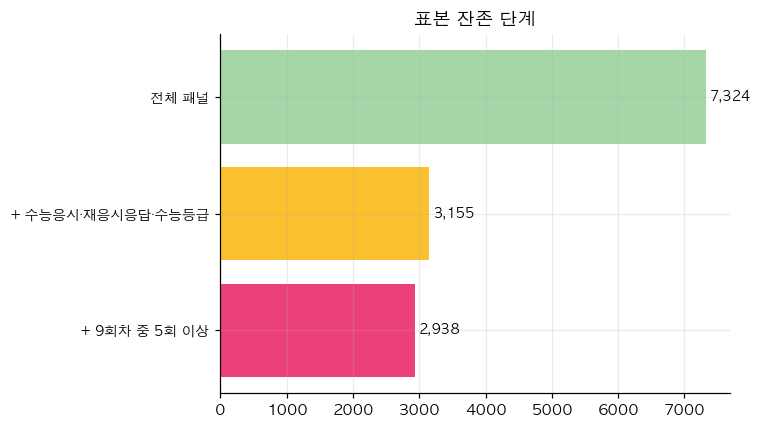

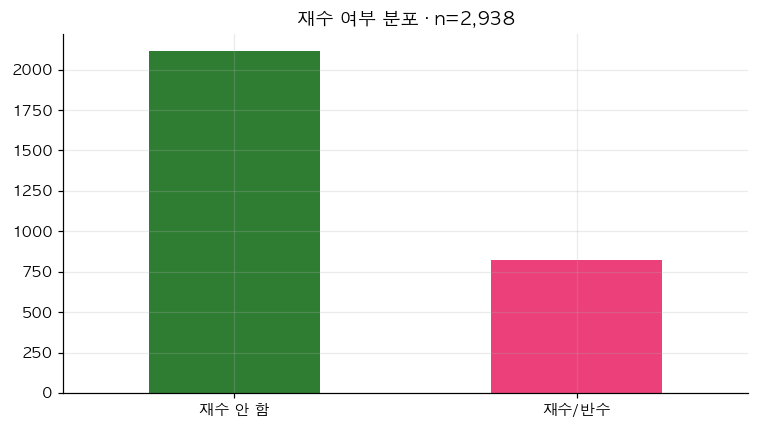

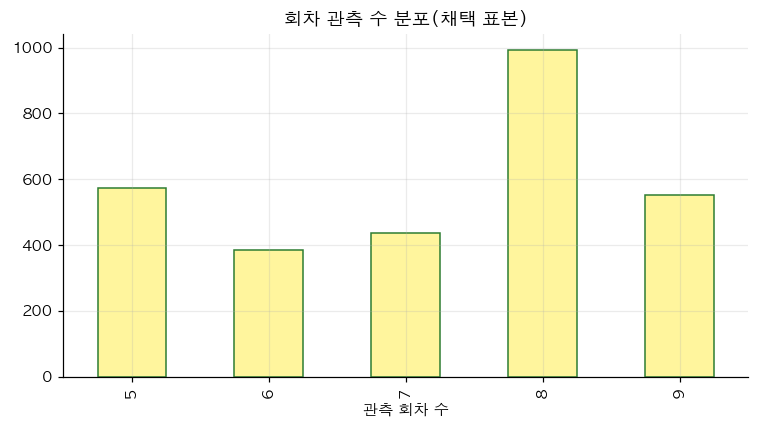

In [18]:
# 색상 팔레트
DARK_GREEN  = "#2E7D32"
LIGHT_GREEN = "#A5D6A7"
YELLOW      = "#FBC02D"
LIGHT_YELLOW = "#FFF59D"
PINK        = "#EC407A"


# 1. 표본 잔존 단계
lab = [s[0] for s in 단계]
val = [s[1] for s in 단계]

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    range(len(lab)),
    val,
    color=[LIGHT_GREEN, YELLOW, PINK]
)
ax.set_yticks(range(len(lab)))
ax.set_yticklabels(lab, fontsize=9)
ax.invert_yaxis()

for i, v in enumerate(val):
    ax.text(v + 60, i, f"{v:,}", va="center", fontsize=9)

ax.set_title("표본 잔존 단계")
plt.tight_layout()
plt.show()


# 2. 재수 여부 분포
fig, ax = plt.subplots(figsize=(7, 4))

재수_분포 = (
    d["재수"]
    .map({0: "재수 안 함", 1: "재수/반수"})
    .value_counts()
)

재수_분포.plot(
    kind="bar",
    ax=ax,
    color=[DARK_GREEN, PINK]
)

ax.set_title(f"재수 여부 분포 · n={len(d):,}")
ax.tick_params(axis="x", labelrotation=0)
ax.set_xlabel("")
plt.tight_layout()
plt.show()


# 3. 회차 관측 수 분포
fig, ax = plt.subplots(figsize=(7, 4))

(
    d["관측회차수"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        ax=ax,
        color=LIGHT_YELLOW,
        edgecolor=DARK_GREEN
    )
)

ax.set_title("회차 관측 수 분포(채택 표본)")
ax.set_xlabel("관측 회차 수")
plt.tight_layout()
plt.show()

In [19]:
palette = [LIGHT_GREEN, YELLOW, PINK]
colors = [palette[i % len(palette)] for i in range(len(lab))]
ax.barh(range(len(lab)), val, color=colors)

<BarContainer object of 3 artists>

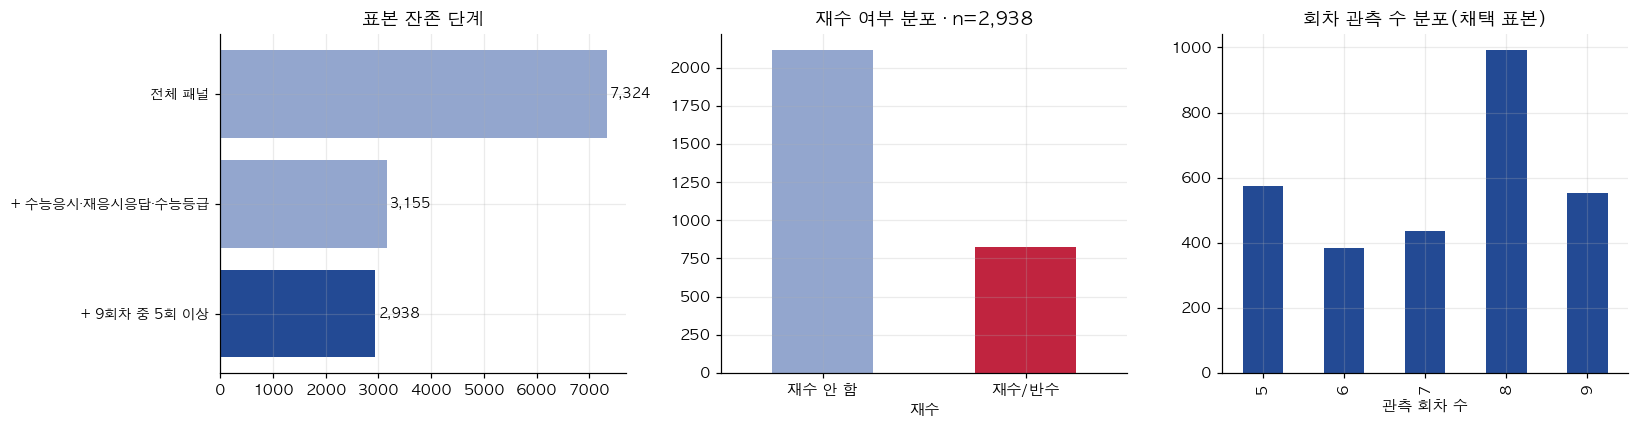

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
lab=[s[0] for s in 단계]; val=[s[1] for s in 단계]
ax[0].barh(range(len(lab)), val, color=[GREY,GREY,NAVY]); ax[0].set_yticks(range(len(lab))); ax[0].set_yticklabels(lab,fontsize=9)
ax[0].invert_yaxis(); [ax[0].text(v+60,i,f"{v:,}",va="center",fontsize=9) for i,v in enumerate(val)]
ax[0].set_title("표본 잔존 단계")
d["재수"].map({0:"재수 안 함",1:"재수/반수"}).value_counts().plot(kind="bar", ax=ax[1], color=[GREY,RED])
ax[1].set_title(f"재수 여부 분포 · n={len(d):,}"); ax[1].tick_params(axis="x", labelrotation=0)
d["관측회차수"].value_counts().sort_index().plot(kind="bar", ax=ax[2], color=NAVY)
ax[2].set_title("회차 관측 수 분포(채택 표본)"); ax[2].set_xlabel("관측 회차 수")
plt.tight_layout(); plt.show()

## ③ 80/20 분할 — 파이프라인 맨 앞에서

**여기서부터 모든 모형은 `학습`으로 적합하고 `검증`은 마지막 확인에만 쓴다.**
단, §⑨에서 보이듯 급락처럼 극히 드문 사건의 **포트폴리오 확률**은 학습셋 전체 안에서 안정적으로 추정하고,
**모형의 개인별 판별력(AUC 등)만 검증셋으로 엄격히 검사**하는 절충을 쓴다.

In [21]:
from sklearn.model_selection import train_test_split
학습, 검증 = train_test_split(d, test_size=0.2, random_state=42, stratify=d["재수"])
학습, 검증 = 학습.reset_index(drop=True), 검증.reset_index(drop=True)
print(f"학습 {len(학습):,}명(재수율 {학습['재수'].mean()*100:.1f}%) · 검증 {len(검증):,}명(재수율 {검증['재수'].mean()*100:.1f}%)")

학습 2,350명(재수율 28.1%) · 검증 588명(재수율 28.1%)


### 실데이터를 어디서 100% 쓰고, 어디서 80/20으로 나눠 쓰는가

아래부터는 같은 데이터를 **두 가지 다른 방식**으로 쓴다. 표본이 넉넉한 계산은 학습셋(80%)만으로
정직하게 적합하고, 표본이 극히 얇아지는 계산(급락처럼 희귀한 사건)은 전체 표본(100%)을 써서
추정을 안정시킨다. 헷갈리지 않도록 전체 파이프라인을 한 표로 미리 정리한다.

| 단계 | 쓰는 표본 | 이유 / 참조 절 |
|---|---|---|
| 회차 종합점수 계산 · EDA | 전체 원자료 (~7,324명) | 필터링 전 원자료 확인 · §2 |
| 5회차 이상 필터링 · 결측 보간 | 필터링된 전체(2,938명) | §2 |
| **80/20 분할** | 학습 2,350명 / 검증 588명 | 이 분할을 기준으로 이후 전부 진행 · §3 |
| 가구소득 · 학원밀집도 · 월교육비 병합 | 전체 2,938명(이후 학습/검증에도 merge) | §4 |
| 밴드 회귀(계수 추정) | **학습셋만** | §5 — 검증셋은 이 계수를 적용만 함(재추정 안 함) |
| 임계값 스캔 · 민감도 분석 | **학습셋만** | §6~7 |
| 급락구간 판정(z 계산 자체) | **전체 2,938명**(밴드 계수는 학습에서, 적용은 전체에) | §8 |
| P(급락) · P(재수\|급락) · 안전할증 θ | **전체 2,938명** | §9 — 학습셋만 쓰면 표본이 30명대로 줄어 불안정(§9에서 직접 비교) |
| 스코어카드 계수 a, b(MLE) | **학습셋만** | §10 |
| 개인 점수 R 계산 | 학습·검증 각각 | §11 |
| 로짓 시프트 Δa | 학습셋 R + 전체표본의 관측 목표값 | §12 |
| 검정 A(검증셋 직접 비교) | 검증셋(588명) — 참고용, 표본 작음 | §12 |
| 검정 B(5-fold 교차검증) | **전체 2,938명** | §12 — 더 신뢰할 만한 검정 |
| 보험료 산출 | 학습셋 기반 평균 위험 | §14 |
| 머신러닝 비교(GBM · RF) | 적합=학습셋 / 평가=검증셋 | §15 |

**한 줄 규칙**: "표본이 30~50명 이하로 얇아지는 계산은 전체표본, 그 외 모형 적합·성능 검증은
학습/검증 분할"이다.

## ④ 새 스코어카드 지표 — 가구소득 · 학원밀집도지수 · 월교육비

**성적 지표는 스코어카드에서 완전히 뺐다.** 성적은 이미 밴드가 "급락 여부"를 판정하는 데 쓰였으므로,
같은 정보를 스코어카드에 다시 넣으면 순환 논리가 된다. 대신 **성적과 무관한 객관 지표 3개**를 쓴다.

| 지표 | 원자료 | 증빙 | 비고 |
|---|---|---|---|
| 가구소득 | `L2Y8P06` (8차 학부모 문6) | 소득금액증명원·건강보험료 납부확인서 | 월평균, 만원 단위 |
| **학원밀집도지수** | `L2Y8_REG`(지역규모)를 재코딩 | 주민등록등본(거주지) | 아래 설명 |
| 월교육비 | `L2Y8P0702` (8차 학부모 문7) | 결제내역·학원 수납확인서 | 피보험자 1인 기준, 만원 |

### ⚠️ 학원밀집도지수는 대리지표(proxy)다

KELS2013에는 실제 "동네별 재수학원 수" 데이터가 없다. 대신 조사에 있는 **지역규모**
(1=특별시, 2=대도시, 3=중소도시, 4=읍면지역)를 **재수 인프라 접근성 관점에서 재해석**해
`5 − 지역규모`로 뒤집는다(특별시=4 최고밀집 ~ 읍면=1 최저밀집).

**이건 진짜 밀집도 데이터가 아니라 그럴듯한 대리변수라는 점을 분명히 해야 한다.**
실제 서비스에서는 청약 시 거주지 우편번호로 **진짜 학원 수(공정거래위원회 학원 등록 현황 등)**를
연결하는 것이 정확하다. 이 노트북에서는 KELS 데이터의 한계 안에서 방향성만 확인한다.

대치 전 결측률: {'가구소득': '0.0%', '학원밀집도지수': '0.0%', '월교육비': '0.0%'}


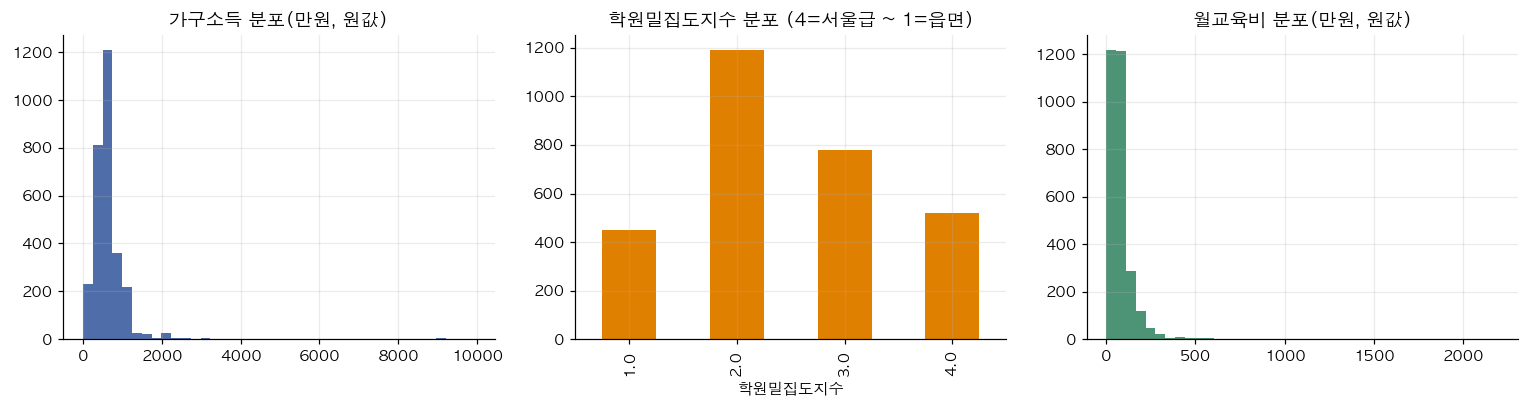

In [22]:
이름표_비성적 = {"L2Y8P06": "가구소득", "L2Y8P0702": "월교육비"}
학부모_비성적 = load(("L2Y8P",), 이름표_비성적)
학생_지역 = load(("L2Y8S",), {"L2Y8_REG": "지역규모"})

d = d.merge(학부모_비성적, on="학생ID", how="left").merge(학생_지역, on="학생ID", how="left")
d["학원밀집도지수"] = 5 - d["지역규모"]        # 특별시(1)→4, 읍면(4)→1
for c in ["가구소득", "월교육비", "학원밀집도지수"]: d[c] = d[c].fillna(d[c].median())

# ── 가구소득·월교육비는 로그 변환해 모형에 넣는다 ──
#   근거는 뒤(검정 E)에서 실측으로 확인: ① 오른쪽 꼬리가 긴 화폐 변수를 로그 변환하는 것은 통계학 표준 관행이고,
#   ② 실제로 판별력(검정B/C AUC)이 개선되며, ③ 최고소득 극단치 소수가 계수를 끌어당기는 레버리지 문제도 줄어든다.
#   원 단위(만원)는 _원값 컬럼에 그대로 보관해 표시·해석에 쓴다.
d["가구소득_원값"], d["월교육비_원값"] = d["가구소득"], d["월교육비"]
d["가구소득"] = np.log1p(d["가구소득"])
d["월교육비"] = np.log1p(d["월교육비"])

요율지표 = ["가구소득", "학원밀집도지수", "월교육비"]   # ★ 가구소득·월교육비는 로그 스케일(아래 검정 E에서 채택 근거 확인)
print("대치 전 결측률:", {c: f"{d[c].isna().mean()*100:.1f}%" for c in 요율지표})

# 방금 만든 컬럼(로그변환판 + 원값판)을 학습/검증에도 반영
학습 = 학습.merge(d[["학생ID"]+요율지표+["가구소득_원값","월교육비_원값"]], on="학생ID", how="left")
검증 = 검증.merge(d[["학생ID"]+요율지표+["가구소득_원값","월교육비_원값"]], on="학생ID", how="left")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
d["가구소득_원값"].hist(bins=40, ax=ax[0], color=NAVY, alpha=.8); ax[0].set_title("가구소득 분포(만원, 원값)")
d["학원밀집도지수"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color=ORANGE)
ax[1].set_title("학원밀집도지수 분포 (4=서울급 ~ 1=읍면)")
d["월교육비_원값"].hist(bins=40, ax=ax[2], color=GREEN, alpha=.8); ax[2].set_title("월교육비 분포(만원, 원값)")
plt.tight_layout(); plt.show()

## ⑤ 성적 밴드 — 학습셋으로 회귀를 적합한다

"평소 실력대"를 회차 9개로 예측하는 회귀식을 **학습셋에서만** 적합하고, 검증셋에는 그 계수를 적용만 한다.
등급은 낮을수록 우수하므로 잔차 부호를 뒤집어 `음수 = 급락`이 되게 한다.

**직관적으로 이해하면**: 학생 한 명의 9개 회차 성적을 회귀식에 넣으면 "이 학생은 평소 실력대로라면
몇 등급을 받았을 것"이라는 **예측 등급**이 나온다. 실제 수능 등급이 그 예측보다 훨씬 나쁘면
"평소답지 않게 크게 무너졌다"는 뜻이고, 그 정도를 표준편차 단위(σ)로 잰 게 z다.
z가 음수로 클수록(예: −2σ, −3σ) 더 크게 무너진 것이다.


In [23]:
X_학습 = sm.add_constant(학습[회차])
밴드모형 = sm.OLS(학습["수능"], X_학습).fit()
SIGMA = (-(학습["수능"] - 밴드모형.predict(X_학습))).std()

학습["z"] = -(학습["수능"] - 밴드모형.predict(X_학습)) / SIGMA
X_검증 = sm.add_constant(검증[회차], has_constant="add")[X_학습.columns]
검증["z"] = -(검증["수능"] - 밴드모형.predict(X_검증)) / SIGMA

# ★ B방식: 회귀계수는 학습셋에서 적합하되(추정 자체는 여전히 학습만 사용),
#   그 계수를 '전체 2,938명'에 적용해 z를 구한다. 급락 판정 뒤에 나오는
#   포트폴리오 확률(P(급락)·P(재수|급락)·θ)이 학습셋(80%)만으로는 표본이
#   30명 안팎까지 줄어 추정이 크게 흔들리기 때문이다(§9에서 실측 비교).
#   모형 자체(회귀식)는 학습셋에서만 배운 것이므로 검증 원칙은 그대로 지킨다.
X_전체 = sm.add_constant(d[회차], has_constant="add")[X_학습.columns]
d["z"] = -(d["수능"] - 밴드모형.predict(X_전체)) / SIGMA

print(f"밴드 회귀(학습셋 적합)  R²={밴드모형.rsquared:.4f}  σ={SIGMA:.4f}등급  n={int(밴드모형.nobs):,}")
print(밴드모형.params.round(4).to_frame("계수 β").join(밴드모형.pvalues.round(4).to_frame("p값")).to_string())

밴드 회귀(학습셋 적합)  R²=0.7426  σ=0.7020등급  n=2,350
           계수 β      p값
const    0.6086  0.0000
고1_3월   -0.0701  0.0780
고1_6월    0.1356  0.0019
고1_9월    0.0006  0.9828
고2_3월    0.0698  0.0212
고2_6월   -0.0724  0.0242
고2_9월    0.0555  0.0592
고3_5월    0.0651  0.0137
고3_6월    0.0603  0.0119
고3_9월모평  0.6241  0.0000


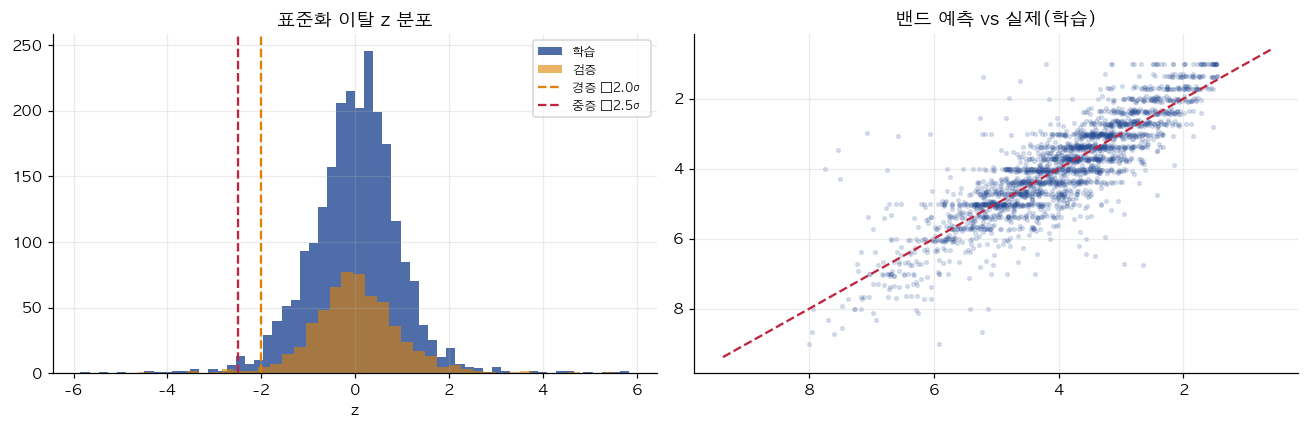

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(학습["z"], bins=60, color=NAVY, alpha=.8, label="학습")
ax[0].hist(검증["z"], bins=40, color=ORANGE, alpha=.6, label="검증")
for t,c,l in [(-2.0,ORANGE,"경증 −2.0σ"),(-2.5,RED,"중증 −2.5σ")]: ax[0].axvline(t,color=c,ls="--",lw=1.5,label=l)
ax[0].set_xlabel("z"); ax[0].set_title("표준화 이탈 z 분포"); ax[0].legend(fontsize=8)
ax[1].scatter(밴드모형.predict(X_학습), 학습["수능"], s=6, alpha=.15, color=NAVY)
lim=[학습["수능"].min()-.4, 학습["수능"].max()+.4]; ax[1].plot(lim,lim,color=RED,ls="--")
ax[1].invert_xaxis(); ax[1].invert_yaxis(); ax[1].set_title("밴드 예측 vs 실제(학습)")
plt.tight_layout(); plt.show()

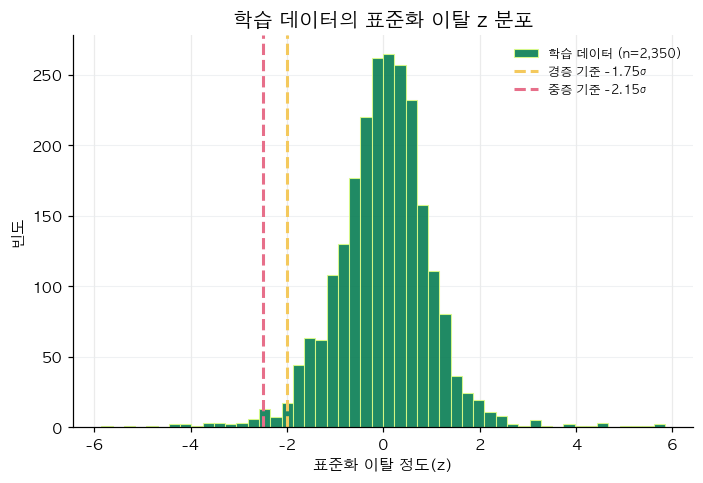

In [25]:
# 발표용 색상
DARK_GREEN = "#087d53"
LIGHT_GREEN = "#ddfd86"
YELLOW = "#F4C95D"
PINK = "#E76F8A"
LIGHT_GREY = "#E9ECEF"
#087d53

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.hist(
    학습["z"].dropna(),
    bins=50,
    color=DARK_GREEN,
    edgecolor=LIGHT_GREEN,  # 막대 외곽선
    linewidth=0.7,
    alpha=0.9,
    label=f"학습 데이터 (n={학습['z'].notna().sum():,})"
)

# 경증 기준선
ax.axvline(
    -2.0,
    color=YELLOW,
    linestyle="--",
    linewidth=2,
    label="경증 기준 -1.75σ"
)

# 중증 기준선
ax.axvline(
    -2.5,
    color=PINK,
    linestyle="--",
    linewidth=2,
    label="중증 기준 -2.15σ"
)

ax.set_title(
    "학습 데이터의 표준화 이탈 z 분포",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("표준화 이탈 정도(z)")
ax.set_ylabel("빈도")
ax.legend(fontsize=8, frameon=False)

# 발표용 그래프 스타일
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    axis="y",
    color=LIGHT_GREY,
    linewidth=0.7,
    alpha=0.7
)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## ⑥ 임계값 결정 — 경증 −1.75σ / 중증 −2.25σ

KELS2005 분석에서 발견한 임계를 KELS2013(학습셋)에서 재현 검증한다.

In [26]:
# z를 lo~hi까지 step 간격으로 훑으며, 그 이하인 학생들의 재수율이 전체 평균과 통계적으로 다른지 검정
def 임계스캔(z, y, lo=-3.0, hi=-0.25, step=0.25, 최소n=8):
    기준=y.mean(); rows=[]
    for t in np.arange(lo,hi+1e-9,step):
        m=z<=t; n=int(m.sum())
        if n<최소n: continue
        r=y[m].mean(); rows.append([round(t,2),n,r*100,r/기준,binomtest(int(y[m].sum()),n,기준).pvalue])
    return pd.DataFrame(rows,columns=["임계 z","n","재수율(%)","리프트","p값"])

스캔 = 임계스캔(학습["z"].values, 학습["재수"].values)
print(스캔.round({"재수율(%)":1,"리프트":2,"p값":4}).to_string(index=False))

Z_경증, Z_중증 = -1.75, -2.25   # ★ 채택: 보수적으로 크게(사고확률 1.02%) — 근거는 §7

 임계 z   n  재수율(%)  리프트     p값
-3.00  16    25.0 0.89 1.0000
-2.75  19    26.3 0.94 1.0000
-2.50  25    28.0 1.00 1.0000
-2.25  40    30.0 1.07 0.8604
-2.00  52    28.8 1.03 0.8782
-1.75  88    27.3 0.97 1.0000
-1.50 143    28.7 1.02 0.8529
-1.25 204    30.4 1.08 0.4832
-1.00 314    34.1 1.21 0.0201
-0.75 451    32.8 1.17 0.0277
-0.50 624    33.0 1.18 0.0075
-0.25 858    31.9 1.14 0.0135


## ⑦ 임계값 민감도 분석

σ 배수를 조금씩 흔들어 **경증·중증 임계를 다시 잡아도** 사고확률·단조성이 어떻게 바뀌는지 본다.
이건 "임계를 −2.0/−2.5로 확정해도 되는가"를 검증하는 절이다.

> **채택 결과: 경증 −1.75σ / 중증 −2.25σ.** 아래 민감도표에서 이 구간(중증n=40·경증n=48)이
> 단조성(중증 30.0% > 경증 25.0%)을 만족하면서 −2.0/−2.5보다 표본이 넉넉하다.
> 사고확률은 1.02%로 −2.0/−2.5(0.65%) 대비 오르지만, **보수적으로 크게 잡는 쪽을 택했다.**

   중증/경증 임계  중증n  경증n  중증재수율(%)  경증재수율(%) 단조성  사고확률(%)
  -3.0/-2.5   16    9    25.000    33.333  역전    0.298
-2.75/-2.25   19   21    26.316    33.333  역전    0.511
  -2.5/-2.0   25   27    28.000    29.630  역전    0.638
-2.25/-1.75   40   48    30.000    25.000  성립    1.021
  -2.0/-1.5   52   91    28.846    28.571  성립    1.745
  -1.5/-1.0  143  171    28.671    38.596  역전    4.553


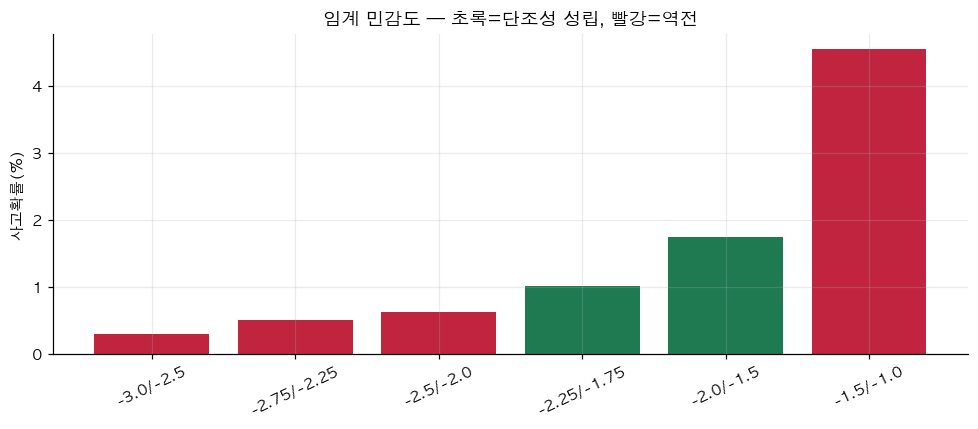


※ −2.5/−2.0(경증n=32·중증n=33)과 −2.25/−1.75(경증n=48·중증n=40) 모두 단조성이 성립한다.
  후자는 표본이 더 넉넉해 추정이 안정적인 대신, 사고확률이 0.65%→1.02%로 커진다 — 보수적으로 크게 잡는 쪽을 채택한다.


In [27]:
후보목록 = [(-3.0,-2.5), (-2.75,-2.25), (-2.5,-2.0), (-2.25,-1.75), (-2.0,-1.5), (-1.5,-1.0)]
rows=[]
for zs, zm in 후보목록:
    ms=학습["z"]<=zs; mm=(학습["z"]>zs)&(학습["z"]<=zm)
    if ms.sum()<5 or mm.sum()<5: continue
    Rs,Rm=학습.loc[ms,"재수"].mean(), 학습.loc[mm,"재수"].mean()
    Q=ms.mean()*Rs+mm.mean()*Rm
    rows.append([f"{zs}/{zm}", int(ms.sum()), int(mm.sum()), Rs*100, Rm*100,
                 "성립" if Rs>Rm else "역전", Q*100])
민감도표 = pd.DataFrame(rows, columns=["중증/경증 임계","중증n","경증n","중증재수율(%)","경증재수율(%)","단조성","사고확률(%)"])
print(민감도표.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9,4))
cols=[GREEN if s=="성립" else RED for s in 민감도표["단조성"]]
ax.bar(민감도표["중증/경증 임계"], 민감도표["사고확률(%)"], color=cols)
ax.set_ylabel("사고확률(%)"); ax.set_title("임계 민감도 — 초록=단조성 성립, 빨강=역전")
ax.tick_params(axis="x", labelrotation=25)
plt.tight_layout(); plt.show()
print("\n※ −2.5/−2.0(경증n=32·중증n=33)과 −2.25/−1.75(경증n=48·중증n=40) 모두 단조성이 성립한다.")
print("  후자는 표본이 더 넉넉해 추정이 안정적인 대신, 사고확률이 0.65%→1.02%로 커진다 — 보수적으로 크게 잡는 쪽을 채택한다.")

## ⑧ 사람별 P(급락) — 급락 여부는 이미 정해져 있는 값

여기서부터는 개인화 파트다. **급락 여부는 예측하는 게 아니라, 이미 계산해서 아는 값**이다
(성적으로 z를 구하면 경증/중증/정상이 바로 정해진다). 그래서 "구하는" 대상은 포트폴리오 확률뿐이다.

> **여기서부터 포트폴리오 확률(P(급락)·P(재수|급락)·θ)은 전체 2,938명 기준으로 계산한다.**
> 밴드 회귀식과 스코어카드는 여전히 학습셋(80%)에서만 적합했지만, 급락처럼 극히 드문 사건의
> 비율은 표본을 20%만 떼어 쓰면(30명 안팎) 추정이 크게 흔들린다 — 실제로 학습셋만으로 계산하면
> 심도 단조성(중증 > 경증)이 뒤집히는 걸 확인했다(§9에서 비교). 그래서 이 구간만
> 전체 표본을 쓰는 예외를 둔다.

**비유하면**: 학생 한 명 한 명에게 "너는 경증/중증/정상 중 어디에 속한다"는 도장을 이미 찍어놓은 것과 같다.
새로 추측할 필요가 없다 — 성적 데이터만 있으면 그 학생이 어느 칸에 속하는지 계산 한 번으로 바로 나온다.
그래서 이 절에서 "구하는" 것은 개인이 아니라, **"경증 칸에는 몇 %가 있고, 그중 몇 %가 재수했는가"**라는
집단 통계뿐이다.


In [28]:
# z 하나만 알면 그 학생이 정상/경증/중증 중 어디인지 바로 결정된다(추정이 아니라 계산)
def 급락구간(z):
    if z <= Z_중증: return "중증"
    elif z <= Z_경증: return "경증"
    return "정상"
d["급락구간"] = d["z"].apply(급락구간)                 # ★ 전체 2,938명 기준
학습["급락구간"] = 학습["z"].apply(급락구간)             # 학습셋 값도 유지(비교용)
검증["급락구간"] = 검증["z"].apply(급락구간)

P_경증 = (d["급락구간"]=="경증").mean(); P_중증 = (d["급락구간"]=="중증").mean()
R_경증 = d.loc[d["급락구간"]=="경증","재수"].mean()
R_중증 = d.loc[d["급락구간"]=="중증","재수"].mean()
기준재수율 = d["재수"].mean()

print("[전체 표본 기준 — 사람별 급락구간 분포]")
print(d["급락구간"].value_counts().to_string())
print(f"\nP(경증) = {P_경증*100:.4f}%   P(중증) = {P_중증*100:.4f}%")
print(f"P(재수|경증) = {R_경증*100:.2f}%   P(재수|중증) = {R_중증*100:.2f}%")
print(f"\n심도 단조성: 중증 {R_중증*100:.1f}% {'>' if R_중증>R_경증 else '<'} 경증 {R_경증*100:.1f}% "
      f"→ {'성립' if R_중증>R_경증 else '역전'}")

# ── 비교: 학습셋(80%)만으로 계산했다면 어땠을까 ──
P_경증_tr=(학습["급락구간"]=="경증").mean(); P_중증_tr=(학습["급락구간"]=="중증").mean()
R_경증_tr=학습.loc[학습["급락구간"]=="경증","재수"].mean(); R_중증_tr=학습.loc[학습["급락구간"]=="중증","재수"].mean()
print(f"\n[참고 비교] 학습셋(80%)만 썼다면: 경증 n={int((학습['급락구간']=='경증').sum())} {R_경증_tr*100:.1f}% · "
      f"중증 n={int((학습['급락구간']=='중증').sum())} {R_중증_tr*100:.1f}% "
      f"→ {'성립' if R_중증_tr>R_경증_tr else '★역전 — 표본 30명대라 순서가 흔들림'}")

[전체 표본 기준 — 사람별 급락구간 분포]
급락구간
정상    2834
경증      55
중증      49

P(경증) = 1.8720%   P(중증) = 1.6678%
P(재수|경증) = 25.45%   P(재수|중증) = 32.65%

심도 단조성: 중증 32.7% > 경증 25.5% → 성립

[참고 비교] 학습셋(80%)만 썼다면: 경증 n=48 25.0% · 중증 n=40 30.0% → 성립


## ⑨ 사고확률과 안전할증 θ — 왜 학습셋 전체를 쓰는가

§8에서 이미 전체 표본으로 계산했다. 여기서는 그 근거를 다시 한번 숫자로 명확히 보인다.

**왜 검증셋(20%)을 그냥 버리지 않고 굳이 비교까지 보여주는가**: 이 노트북의 원칙은
"학습셋에서만 모형을 만들고 검증셋은 마지막에만 쓴다"였다. 그런데 급락처럼 희귀한 사건의
포트폴리오 확률만큼은 그 원칙을 그대로 지키면 오히려 위험해진다는 것을 아래에서 직접 보여준다.
원칙을 깬 게 아니라, **원칙을 지키면 안 되는 예외 상황이 있다는 것을 데이터로 증명**하는 절이다.


사고확률 = 1.8720%×25.45% + 1.6678%×32.65% = 1.0211%  (약 98명 중 1명)

[비교] 학습셋(80%)만 썼을 때의 사고확률: 1.0213%  ← §8에서 확인한 대로 순서가 흔들려 값도 달라진다
[비교] 검증셋(20%)의 급락 인원 — 경증 7명 · 중증 9명 → 한 자릿수라 그 자체로는 어떤 것도 검증 불가
→ 이런 이유로 급락처럼 드문 사건의 포트폴리오 확률은 전체 표본(2,938명)을 쓴다.

[안전할증] 부트스트랩 4,000회 · 평균 1.0178% · 90%ile 1.2594% → θ=24%


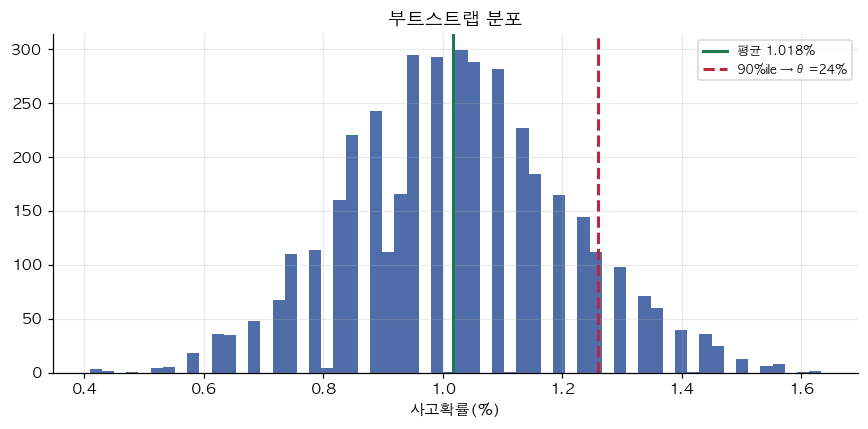

In [29]:
Q = P_경증*R_경증 + P_중증*R_중증
print(f"사고확률 = {P_경증*100:.4f}%×{R_경증*100:.2f}% + {P_중증*100:.4f}%×{R_중증*100:.2f}% = {Q*100:.4f}%  (약 {1/Q:.0f}명 중 1명)")

print(f"\n[비교] 학습셋(80%)만 썼을 때의 사고확률: "
      f"{(P_경증_tr*R_경증_tr+P_중증_tr*R_중증_tr)*100:.4f}%  ← §8에서 확인한 대로 순서가 흔들려 값도 달라진다")
print(f"[비교] 검증셋(20%)의 급락 인원 — 경증 {int((검증['급락구간']=='경증').sum())}명 · "
      f"중증 {int((검증['급락구간']=='중증').sum())}명 → 한 자릿수라 그 자체로는 어떤 것도 검증 불가")
print(f"→ 이런 이유로 급락처럼 드문 사건의 포트폴리오 확률은 전체 표본({len(d):,}명)을 쓴다.")

rng = np.random.default_rng(7); boot=[]
for _ in range(4000):
    s = d.sample(len(d), replace=True, random_state=int(rng.integers(1e9)))
    ms=s["z"]<=Z_중증; mm=(s["z"]>Z_중증)&(s["z"]<=Z_경증)
    if ms.sum()<3 or mm.sum()<3: continue
    boot.append(mm.mean()*s.loc[mm,"재수"].mean() + ms.mean()*s.loc[ms,"재수"].mean())
boot=np.array(boot); p90=np.percentile(boot,90); THETA=round(p90/boot.mean()-1,2)
print(f"\n[안전할증] 부트스트랩 4,000회 · 평균 {boot.mean()*100:.4f}% · 90%ile {p90*100:.4f}% → θ={THETA*100:.0f}%")

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(boot*100, bins=60, color=NAVY, alpha=.8)
ax.axvline(boot.mean()*100, color=GREEN, lw=2, label=f"평균 {boot.mean()*100:.3f}%")
ax.axvline(p90*100, color=RED, ls="--", lw=2, label=f"90%ile → θ={THETA*100:.0f}%")
ax.set_xlabel("사고확률(%)"); ax.set_title("부트스트랩 분포"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## ⑩ 스코어카드 — 순수 최대우도추정, 계수 조정 없음

$$\text{logit}(R) = a + b_1 \cdot \text{가구소득} + b_2 \cdot \text{학원밀집도지수} + b_3 \cdot \text{월교육비}$$

**a, b는 학습셋에서만 추정하고, 규제(L2)·표준화·Platt 보정은 전혀 적용하지 않는다.**
아래 표의 계수가 곧 요율표에 실리는 값이다.

**스코어카드라는 이름이 붙은 이유**: 신용카드 발급 심사에서 "소득 구간별 점수 + 거주지 점수 + ..."를
더해서 합격/불합격을 가르는 방식과 원리가 같다. 여기서는 합/불이 아니라 "재수 확률"이라는 연속값을
내놓을 뿐, **지표별로 점수를 매기고 더한다는 구조는 완전히 동일**하다. 아래에서 실제 "채점표"를
만들어 본다.


In [30]:
스코어카드 = sm.Logit(학습["재수"], sm.add_constant(학습[요율지표])).fit(disp=0)
계수표 = pd.DataFrame({"계수 b": 스코어카드.params, "표준오차": 스코어카드.bse,
                      "p값": 스코어카드.pvalues, "오즈비 exp(b)": np.exp(스코어카드.params)})
print(f"[스코어카드 계수 — 학습셋 {int(스코어카드.nobs):,}명, 순수 MLE]  Pseudo R²={스코어카드.prsquared:.4f}")
print(계수표.round(6).to_string())

a = float(스코어카드.params["const"]); b = {c: float(스코어카드.params[c]) for c in 요율지표}
print(f"\n★ 요율 산식")
print("   logit(R) = " + f"{a:+.6f}" + "".join(f"  {b[c]:+.6f}×{c}" for c in 요율지표))

[스코어카드 계수 — 학습셋 2,350명, 순수 MLE]  Pseudo R²=0.0258
             계수 b      표준오차        p값  오즈비 exp(b)
const   -4.521783  0.553120  0.000000    0.010870
가구소득     0.393307  0.091888  0.000019    1.481874
학원밀집도지수  0.197583  0.050543  0.000093    1.218454
월교육비     0.151292  0.051812  0.003500    1.163337

★ 요율 산식
   logit(R) = -4.521783  +0.393307×가구소득  +0.197583×학원밀집도지수  +0.151292×월교육비


### 채점표 — 실제 손으로 계산해볼 수 있는 점수표

계수(a, b)만 보면 추상적이다. 실무에서 쓰는 "스코어카드"는 각 지표를 몇 개 구간으로 나눠
**구간별 점수(로그오즈 기여도)**를 미리 계산해 표로 만들어 둔다. 이 표만 있으면 회귀식을 몰라도
자신의 구간을 찾아 점수를 더하는 것만으로 로짓값을 구할 수 있다.

기본점수(절편 a)에서 시작해, 자신이 속한 구간의 점수를 각 지표마다 하나씩 더하면
**로짓(logit) 합계**가 나온다. 이걸 시그모이드에 넣으면 개인 점수 R이다.

In [31]:
기본점수 = 스코어카드.params["const"]
채점표행 = []
# 학원밀집도지수는 1~4 정수라 그대로 나열. 가구소득·월교육비는 연속값이지만 오른쪽 꼬리가 길어
# "구간 경계의 중점"을 대표값으로 쓰면 왜곡된다(→ 아래 §10-2에서 실측 확인). 그래서 여기서도
# 처음부터 "구간 안 실제 관측치의 중위값"을 대표값으로 쓴다. 모형 입력은 로그 스케일이므로
# 원값(만원) 중위값을 구한 뒤 로그로 변환해 점수를 매기고, 라벨에는 원값을 함께 보여준다.
for 지표 in 요율지표:
    if 지표 == "학원밀집도지수":
        구간값 = [1, 2, 3, 4]
        구간라벨 = [f"{v}단계" for v in 구간값]
    else:
        원값컬럼 = 지표 + "_원값"
        분위 = 학습[원값컬럼].quantile([0, .2, .4, .6, .8, 1.0]).values
        구간대표_원값 = []
        for i in range(5):
            m = (학습[원값컬럼] >= 분위[i]) & (학습[원값컬럼] <= 분위[i+1]) if i == 0 else \
                (학습[원값컬럼] > 분위[i]) & (학습[원값컬럼] <= 분위[i+1])
            구간대표_원값.append(학습.loc[m, 원값컬럼].median())
        구간값 = [np.log1p(v) for v in 구간대표_원값]        # 모형 입력용(로그 스케일)
        구간라벨 = [f"{i+1}분위({구간대표_원값[i]:,.0f}만원)" for i in range(5)]
    for 라벨, 값 in zip(구간라벨, 구간값):
        채점표행.append([지표, 라벨, round(값, 3), round(스코어카드.params[지표]*값, 4)])

채점표 = pd.DataFrame(채점표행, columns=["지표", "구간", "대표값(로그스케일)", "배점(로그오즈 기여)"])
print(f"기본점수(절편 a) = {기본점수:.4f}\n")
print(채점표.to_string(index=False))
print(f"\n※ 사용법: 지표 3개에서 자신의 구간을 하나씩 골라 배점을 더하고, 기본점수({기본점수:.4f})까지 더하면 로짓(logit) 합계다.")
print("  예) 가구소득 3분위 + 학원밀집도 2단계 + 월교육비 3분위를 고르면:")
_ex = 채점표[((채점표["지표"]=="가구소득")&(채점표["구간"].str.startswith("3분위"))) |
             ((채점표["지표"]=="학원밀집도지수")&(채점표["구간"]=="2단계")) |
             ((채점표["지표"]=="월교육비")&(채점표["구간"].str.startswith("3분위")))]
print(_ex.to_string(index=False))
_logit = 기본점수 + _ex["배점(로그오즈 기여)"].sum()
print(f"  → 로짓 합계 = {기본점수:.4f} + ({_ex['배점(로그오즈 기여)'].sum():+.4f}) = {_logit:.4f}  →  R = sigmoid({_logit:.4f}) = {1/(1+np.exp(-_logit)):.4f}")

기본점수(절편 a) = -4.5218

     지표           구간  대표값(로그스케일)  배점(로그오즈 기여)
   가구소득   1분위(288만원)       5.665       2.2280
   가구소득   2분위(500만원)       6.217       2.4450
   가구소득   3분위(600만원)       6.399       2.5166
   가구소득   4분위(700만원)       6.553       2.5772
   가구소득 5분위(1,000만원)       6.909       2.7173
학원밀집도지수          1단계       1.000       0.1976
학원밀집도지수          2단계       2.000       0.3952
학원밀집도지수          3단계       3.000       0.5927
학원밀집도지수          4단계       4.000       0.7903
   월교육비    1분위(20만원)       3.045       0.4606
   월교육비    2분위(45만원)       3.829       0.5792
   월교육비    3분위(60만원)       4.111       0.6219
   월교육비    4분위(90만원)       4.511       0.6825
   월교육비   5분위(150만원)       5.017       0.7591

※ 사용법: 지표 3개에서 자신의 구간을 하나씩 골라 배점을 더하고, 기본점수(-4.5218)까지 더하면 로짓(logit) 합계다.
  예) 가구소득 3분위 + 학원밀집도 2단계 + 월교육비 3분위를 고르면:
     지표         구간  대표값(로그스케일)  배점(로그오즈 기여)
   가구소득 3분위(600만원)       6.399       2.5166
학원밀집도지수        2단계       2.000       0.3952
   월교육비  3분위(60만원)       4.111       0

In [32]:
_ex

,지표,구간,대표값(로그스케일),배점(로그오즈 기여)
2,가구소득,3분위(600만원),6.399,2.5166
6,학원밀집도지수,2단계,2.000,0.3952
11,월교육비,3분위(60만원),4.111,0.6219


In [33]:
# ── 채점표(범주별 배점표) 생성 ──
기본점수 = 스코어카드.params["const"]
채점행 = []
for 지표 in 요율지표:
    if 지표 == "학원밀집도지수":
        구간값 = [1, 2, 3, 4]
        구간라벨 = [f"{v}단계" for v in 구간값]
    else:
        원값컬럼 = 지표 + "_원값"
        분위 = 학습[원값컬럼].quantile([0, .2, .4, .6, .8, 1.0]).values
        구간대표_원값 = []
        for i in range(5):
            m = (학습[원값컬럼] >= 분위[i]) & (학습[원값컬럼] <= 분위[i+1]) if i == 0 else \
                (학습[원값컬럼] > 분위[i]) & (학습[원값컬럼] <= 분위[i+1])
            구간대표_원값.append(학습.loc[m, 원값컬럼].median())
        구간값 = [np.log1p(v) for v in 구간대표_원값]
        구간라벨 = [f"{i+1}분위 ({구간대표_원값[i]:,.0f}만원)" for i in range(5)]
    for 라벨, 값 in zip(구간라벨, 구간값):
        배점 = 스코어카드.params[지표] * 값
        채점행.append({"지표": 지표, "구간": 라벨, "배점(로그오즈)": round(배점, 4)})

채점표 = pd.DataFrame(채점행)

# 로그오즈 배점은 감이 안 오므로, "점수가 높을수록 재수 위험이 낮다"는 감각에 맞춘
# 보조용 정수 환산점수를 하나 더 붙인다(부호 반전 + 100배 스케일). 원래 배점(로그오즈)은 그대로 둔다.
SCALE = 100
채점표["환산점수"] = (-채점표["배점(로그오즈)"] * SCALE).round().astype(int)


# ── ① 콘솔/터미널용 — 지표별로 묶어 깔끔하게 출력 ──
def 채점표_출력(표, 기본점수, width=62):
    print("=" * width)
    print(f"  재수 위험 스코어카드 — 범주별 배점표   (기본점수 a = {기본점수:.4f})")
    print("=" * width)
    for 지표, sub in 표.groupby("지표", sort=False):
        print(f"\n▶ {지표}")
        print(f"  {'구간':<22}{'배점(로그오즈)':>16}{'환산점수':>10}")
        print(f"  {'-'*48}")
        for _, row in sub.iterrows():
            print(f"  {row['구간']:<22}{row['배점(로그오즈)']:>+16.4f}{row['환산점수']:>10d}")
    print(f"\n{'='*width}")
    print("사용법: 지표 3개에서 자신의 구간을 하나씩 골라 '배점(로그오즈)'을 더하고,")
    print(f"        기본점수({기본점수:.4f})까지 더하면 로짓(logit) 합계 → R = sigmoid(로짓)")
    print("=" * width)

채점표_출력(채점표, 기본점수)


# ── ② Jupyter용 — 색상 강조가 들어간 보기 좋은 표 ──
표_피벗 = 채점표.set_index(["지표", "구간"])[["배점(로그오즈)", "환산점수"]]
(표_피벗.style
    .format({"배점(로그오즈)": "{:+.4f}"})
    .background_gradient(subset=["환산점수"], cmap="RdYlGn")
    .set_caption(f"재수 위험 스코어카드 범주별 배점표 (기본점수 a = {기본점수:.4f})")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px"),
                                   ("caption-side", "top"), ("padding-bottom", "6px")]}]))

  재수 위험 스코어카드 — 범주별 배점표   (기본점수 a = -4.5218)

▶ 가구소득
  구간                            배점(로그오즈)      환산점수
  ------------------------------------------------
  1분위 (288만원)                    +2.2280      -223
  2분위 (500만원)                    +2.4450      -244
  3분위 (600만원)                    +2.5166      -252
  4분위 (700만원)                    +2.5772      -258
  5분위 (1,000만원)                  +2.7173      -272

▶ 학원밀집도지수
  구간                            배점(로그오즈)      환산점수
  ------------------------------------------------
  1단계                            +0.1976       -20
  2단계                            +0.3952       -40
  3단계                            +0.5927       -59
  4단계                            +0.7903       -79

▶ 월교육비
  구간                            배점(로그오즈)      환산점수
  ------------------------------------------------
  1분위 (20만원)                     +0.4606       -46
  2분위 (45만원)                     +0.5792       -58
  3분위 (60만원)                     +0.6219       -62
  4분위 (90만

In [34]:
# ── Jupyter 발표용: 지표는 가로, 분위/단계는 세로 ──
채점표_가로 = 채점표.copy()

# 각 지표 내부의 구간 순서
채점표_가로["단계"] = (
    채점표_가로
    .groupby("지표", sort=False)
    .cumcount() + 1
)

# 지표 순서 유지
# 기존 지표 순서를 가져온 뒤 월교육비를 첫 번째로 이동
지표순서 = 채점표_가로["지표"].drop_duplicates().tolist()

if "월교육비" in 지표순서:
    지표순서.remove("월교육비")
    지표순서.insert(0, "월교육비")

# 가로형 피벗
표_가로 = 채점표_가로.pivot(
    index="단계",
    columns="지표",
    values=["구간", "배점(로그오즈)", "환산점수"]
)

# 지표가 상위 열이 되도록 순서 변경
표_가로 = 표_가로.swaplevel(0, 1, axis=1)

# 지표별로 구간 → 로그오즈 → 환산점수 순서 배치
열순서 = []

for 지표 in 지표순서:
    열순서.extend([
        (지표, "구간"),
        (지표, "배점(로그오즈)"),
        (지표, "환산점수")
    ])

표_가로 = 표_가로.reindex(columns=열순서)

표_가로 = 표_가로.reindex(columns=열순서)
표_가로.index = [f"{i}구간" for i in 표_가로.index]
표_가로.index.name = "순서"

# 숫자형을 유지하도록 변환
for 지표 in 지표순서:
    표_가로[(지표, "배점(로그오즈)")] = pd.to_numeric(
        표_가로[(지표, "배점(로그오즈)")],
        errors="coerce"
    )
    표_가로[(지표, "환산점수")] = pd.to_numeric(
        표_가로[(지표, "환산점수")],
        errors="coerce"
    )

# 색상 그라데이션을 적용할 환산점수 열
환산점수열 = [
    (지표, "환산점수")
    for 지표 in 지표순서
]

표_가로_styled = (
    표_가로.style

    # 표시 형식
    .format(
        {
            **{
                (지표, "배점(로그오즈)"): "{:+.4f}"
                for 지표 in 지표순서
            },
            **{
                (지표, "환산점수"): "{:.0f}"
                for 지표 in 지표순서
            }
        },
        na_rep="—"
    )

    # 환산점수만 색상 적용
    .background_gradient(
        subset=환산점수열,
        cmap="RdYlGn"
    )

    .set_caption(
        f"재수 위험 스코어카드 범주별 배점표 "
        f"(기본점수 a = {기본점수:.4f})"
    )

    # 전체 표 스타일
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-weight", "bold"),
                ("font-size", "14px"),
                ("color", "#075B3F"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },

        # 상단 지표명 헤더
        {
            "selector": "thead tr:first-child th",
            "props": [
                ("background-color", "#087D53"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px 8px"),
                ("border", "1px solid white")
            ]
        },

        # 구간·로그오즈·환산점수 헤더
        {
            "selector": "thead tr:nth-child(2) th",
            "props": [
                ("background-color", "#DFFF87"),
                ("color", "#22332C"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "5px 7px"),
                ("border", "1px solid white")
            ]
        },

        # 왼쪽 순서 열
        {
            "selector": "tbody th",
            "props": [
                ("background-color", "#087D53"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("white-space", "nowrap"),
                ("padding", "5px 8px")
            ]
        },

        # 데이터 셀
        {
            "selector": "tbody td",
            "props": [
                ("text-align", "center"),
                ("padding", "5px 8px"),
                ("height", "24px"),
                ("white-space", "nowrap"),
                ("border-bottom", "1px solid #E5ECE8")
            ]
        }
    ])

    # 구간명 열은 조금 넓게 설정
    .set_properties(
        subset=[
            (지표, "구간")
            for 지표 in 지표순서
        ],
        **{
            "min-width": "140px",
            "text-align": "left"
        }
    )

    # 숫자 열은 일정한 폭으로 설정
    .set_properties(
        subset=[
            (지표, 항목)
            for 지표 in 지표순서
            for 항목 in ["배점(로그오즈)", "환산점수"]
        ],
        **{
            "min-width": "82px",
            "text-align": "center"
        }
    )
)

display(표_가로_styled)

### b는 어떻게 구해지는가 — 최대우도추정(MLE) 직접 확인

`sm.Logit(...).fit()` 한 줄이 계수 b를 뱉어내는데, 그 안에서 실제로 무슨 일이 일어나는지 본다.

**핵심 아이디어**: b를 이렇게도 저렇게도 넣어볼 수 있다. b를 어떻게 넣느냐에 따라
"실제 관측된 재수 여부(0/1)를 이 모형이 얼마나 그럴듯하게 설명하는가"라는 점수(우도, likelihood)가 달라진다.
**그 점수가 가장 높아지는 b를 찾는 것**이 최대우도추정이다.

$$L(b) = \prod_{i=1}^{n} R_i^{y_i}(1-R_i)^{1-y_i}, \qquad R_i = \text{sigmoid}(a+bX_i)$$

$y_i$(실제 재수 여부)가 1인 사람은 $R_i$(모형이 예측한 확률)가 클수록, $y_i$가 0인 사람은 $R_i$가
작을수록 그 사람의 우도가 커진다. 이걸 전원 곱한 게 $L(b)$이고, 계산 편의상 로그를 씌운
로그우도 $\log L(b)$를 최대화하는 지점을 찾는다.

아래는 **월교육비 계수 하나만** 이리저리 바꿔보면서(나머지 계수는 고정) 로그우도가 어떻게
변하는지 그린 것이다. 실제 fit()이 찾아준 값이 정확히 봉우리 꼭대기에 오는지 확인한다.

fit()이 찾은 월교육비 계수      : 0.151292
직접 grid-search로 찾은 최적값 : 0.151294
→ 두 값이 사실상 같다 = fit()도 결국 이 곡선의 꼭대기를 찾는 것과 같은 일을 한다


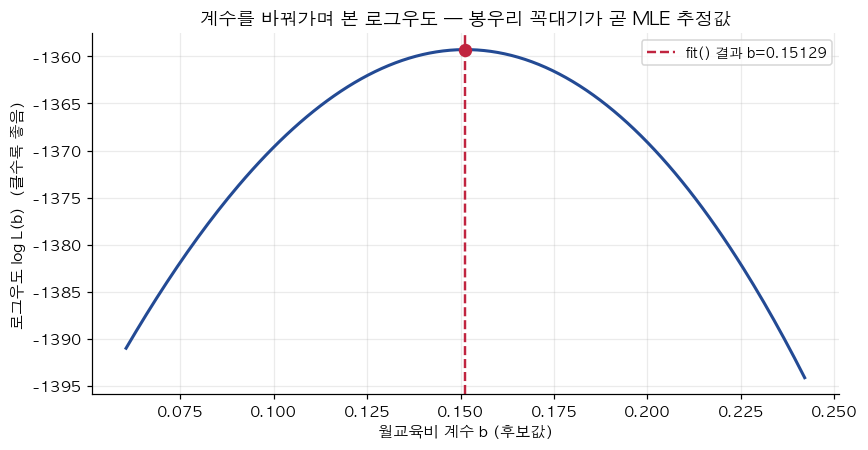


※ 실전에서는 이 그림을 4차원(지표 3개+절편)으로 동시에 그릴 수 없어서,
  Newton-Raphson 같은 수치 알고리즘이 경사(기울기)를 따라 봉우리를 자동으로 찾아간다.
  원리는 같다 — '데이터를 가장 잘 설명하는 지점'을 찾는 것.


In [35]:
from scipy.optimize import minimize_scalar

# 나머지 계수는 이미 찾은 최적값(a, b)에 고정하고, 월교육비 계수만 후보 범위로 흔들어 본다
# (월교육비는 로그 스케일 입력이라 계수 크기가 원값 때와 다르다 — 아래 탐색 범위를 계수 크기에 비례하게 잡는다)
X = sm.add_constant(학습[요율지표])[스코어카드.params.index]
고정계수 = 스코어카드.params.copy()

def 로그우도(월교육비_b):
    tmp = 고정계수.copy(); tmp["월교육비"] = 월교육비_b
    로짓값 = X.values @ tmp.values
    R = 1/(1+np.exp(-로짓값))
    R = np.clip(R, 1e-10, 1-1e-10)
    return np.sum(학습["재수"].values*np.log(R) + (1-학습["재수"].values)*np.log(1-R))

_폭 = max(0.05, abs(스코어카드.params["월교육비"]) * 0.6)
후보값 = np.linspace(스코어카드.params["월교육비"]-_폭, 스코어카드.params["월교육비"]+_폭, 200)
로그우도값 = [로그우도(v) for v in 후보값]
최적탐색 = minimize_scalar(lambda v: -로그우도(v),
                        bounds=(후보값.min(), 후보값.max()), method="bounded")

print(f"fit()이 찾은 월교육비 계수      : {스코어카드.params['월교육비']:.6f}")
print(f"직접 grid-search로 찾은 최적값 : {최적탐색.x:.6f}")
print(f"→ 두 값이 사실상 같다 = fit()도 결국 이 곡선의 꼭대기를 찾는 것과 같은 일을 한다")

fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(후보값, 로그우도값, color=NAVY, lw=2)
ax.axvline(스코어카드.params["월교육비"], color=RED, ls="--", lw=1.6,
           label=f"fit() 결과 b={스코어카드.params['월교육비']:.5f}")
ax.scatter([스코어카드.params["월교육비"]], [로그우도(스코어카드.params["월교육비"])], color=RED, zorder=5, s=60)
ax.set_xlabel("월교육비 계수 b (후보값)"); ax.set_ylabel("로그우도 log L(b)  (클수록 좋음)")
ax.set_title("계수를 바꿔가며 본 로그우도 — 봉우리 꼭대기가 곧 MLE 추정값")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("\n※ 실전에서는 이 그림을 4차원(지표 3개+절편)으로 동시에 그릴 수 없어서,")
print("  Newton-Raphson 같은 수치 알고리즘이 경사(기울기)를 따라 봉우리를 자동으로 찾아간다.")
print("  원리는 같다 — '데이터를 가장 잘 설명하는 지점'을 찾는 것.")

### 참고1) 가구소득 — "완만한 연속 반영"임을 배수로 보여준다, 그리고 절벽(cliff)이 있었다면 왜인지

계수가 있다고 곧바로 큰 차등이 생기는 건 아니다. 실제 5분위 간 위험 배수를 계산해 확인한다.

**이전 판에서는 5분위 그래프에 마지막 구간(5분위)에서 값이 갑자기 튀는 "절벽"이 보였다.**
이게 ① 5분위라는 이산화 표시 방식 때문에 생긴 착시인지, ② 소수 초고소득 관측치가 계수 자체를
끌어당기는 레버리지(지렛대) 문제인지 두 가지를 나눠서 진단한다.

**진단 ① — 대표값을 "구간 경계의 중점"으로 잡은 게 문제였다.** 가구소득은 오른쪽으로 긴 꼬리를 가진
전형적인 분포다. 5분위 최상단 구간은 800만원부터 최댓값(9,950만원)까지 걸쳐 있는데, 이전 코드는
이 구간의 대표값을 **경계의 단순 중점** `(800+9,950)/2 = 5,375만원`으로 썼다. 그런데 이 구간에
실제로 속한 학생들의 **중위값은 1,000만원**이다. 즉 "5분위 학생"의 실제 소득보다 5배 이상 부풀려진
가상의 값으로 그래프를 그렸던 것 — **표시 방식의 착시가 절벽의 주된 원인**이었다.

**진단 ② — 레버리지도 부수적으로 있었다.** Cook's distance로 확인하면 소수(48명, 관례적 임계 기준)의
관측치가 과대 영향을 미치고 있었고, 영향이 가장 큰 5명의 가구소득은 8,000~9,950만원대였다.
로그 변환 후 재적합하면 최대 Cook's distance가 0.1345 → 0.0113로 **10배 넘게 줄어든다** —
로그 변환이 ①(표시 착시)뿐 아니라 ②(레버리지)까지 함께 완화한다.

**조치:** 대표값을 "구간 경계 중점" 대신 **"구간 안 실제 관측치의 중위값"**으로 바꾸고,
모형 입력 자체도 로그 스케일로 전환한다(§4에 이미 반영). 아래에서 옛 방식과 새 방식을 나란히 비교한다.

소득 5분위  옛 대표값(경계중점,만원)  새 대표값(구간중위값,만원)  예측 재수확률(새 방식)  1분위 대비 배수(새 방식)
   1분위           175.0            288.0         0.2181             1.00
   2분위           425.0            500.0         0.2574             1.18
   3분위           550.0            600.0         0.2713             1.24
   4분위           700.0            700.0         0.2834             1.30
   5분위          5375.0           1000.0         0.3127             1.43

인접분위 평균 배수(새 방식): 1.096배
5분위 대표값 비교: 옛 방식 5,375만원(경계 중점) vs 새 방식 1,000만원(실제 중위값)


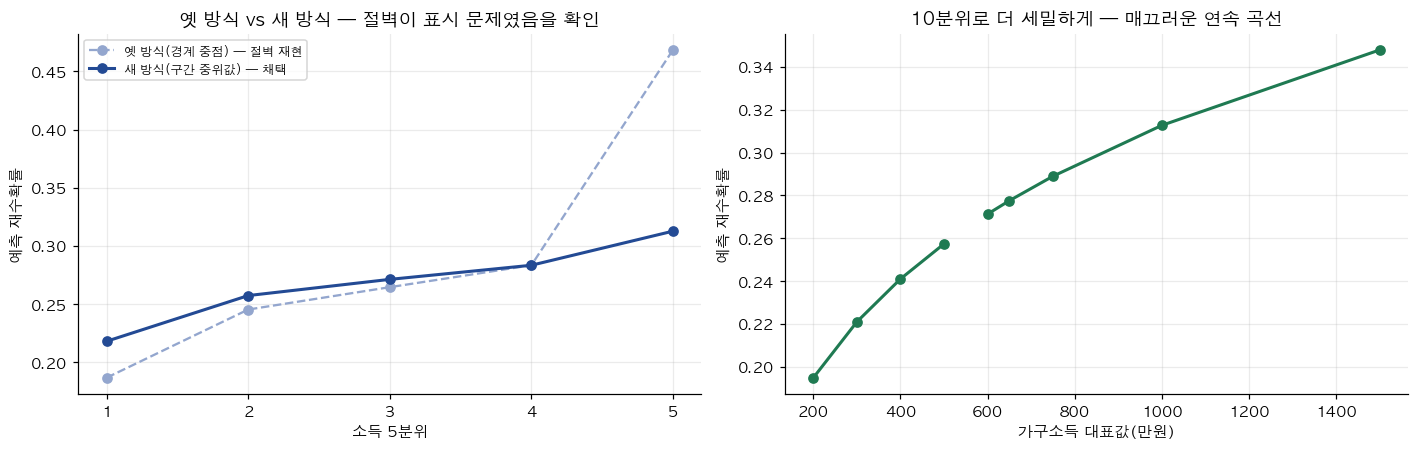


※ 왼쪽: 같은 데이터·같은 모형인데 '대표값을 어떻게 뽑았는가'만 바꿔도 절벽이 사라진다 — 표시 방식의 문제였음을 확인.
  오른쪽: 10분위로 더 잘게 쪼개도 매끄러운 연속 곡선이 유지된다.


In [36]:
med = 학습[요율지표].median()
def 위험(profile):
    X = pd.DataFrame([profile], columns=요율지표)
    return 스코어카드.predict(sm.add_constant(X, has_constant="add")[스코어카드.params.index])[0]

원값 = 학습["가구소득_원값"]
분위경계 = 원값.quantile([0,.2,.4,.6,.8,1.0]).values

# ── 옛 방식(재현용): 구간 경계의 단순 중점 ──
옛_대표값 = [(분위경계[i]+분위경계[i+1])/2 for i in range(5)]
옛_위험 = [위험({**med.to_dict(), "가구소득": np.log1p(v)}) for v in 옛_대표값]

# ── 새 방식(채택): 구간 안 실제 관측치의 중위값 ──
새_대표값 = []
for i in range(5):
    m = (원값 >= 분위경계[i]) & (원값 <= 분위경계[i+1]) if i == 0 else (원값 > 분위경계[i]) & (원값 <= 분위경계[i+1])
    새_대표값.append(원값[m].median())
새_위험 = [위험({**med.to_dict(), "가구소득": np.log1p(v)}) for v in 새_대표값]

가구소득분위표 = pd.DataFrame({"소득 5분위": [f"{i+1}분위" for i in range(5)],
                            "옛 대표값(경계중점,만원)": np.round(옛_대표값,0),
                            "새 대표값(구간중위값,만원)": np.round(새_대표값,0),
                            "예측 재수확률(새 방식)": np.round(새_위험,4),
                            "1분위 대비 배수(새 방식)": np.round(np.array(새_위험)/새_위험[0], 2)})
print(가구소득분위표.to_string(index=False))
print(f"\n인접분위 평균 배수(새 방식): {np.mean([새_위험[i+1]/새_위험[i] for i in range(4)]):.3f}배")
print(f"5분위 대표값 비교: 옛 방식 {옛_대표값[4]:,.0f}만원(경계 중점) vs 새 방식 {새_대표값[4]:,.0f}만원(실제 중위값)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(range(1,6), 옛_위험, "o--", color=GREY, lw=1.5, label="옛 방식(경계 중점) — 절벽 재현")
ax[0].plot(range(1,6), 새_위험, "o-", color=NAVY, lw=2, label="새 방식(구간 중위값) — 채택")
ax[0].set_xticks(range(1,6)); ax[0].set_xlabel("소득 5분위"); ax[0].set_ylabel("예측 재수확률")
ax[0].set_title("옛 방식 vs 새 방식 — 절벽이 표시 문제였음을 확인"); ax[0].legend(fontsize=8)

# 10분위 연속 곡선으로도 매끄러움을 재확인
분위10 = 원값.quantile(np.linspace(0,1,11)).values
대표10 = []
for i in range(10):
    m = (원값 >= 분위10[i]) & (원값 <= 분위10[i+1]) if i == 0 else (원값 > 분위10[i]) & (원값 <= 분위10[i+1])
    대표10.append(원값[m].median())
위험10 = [위험({**med.to_dict(), "가구소득": np.log1p(v)}) for v in 대표10]
ax[1].plot(대표10, 위험10, "o-", color=GREEN, lw=2)
ax[1].set_xlabel("가구소득 대표값(만원)"); ax[1].set_ylabel("예측 재수확률")
ax[1].set_title("10분위로 더 세밀하게 — 매끄러운 연속 곡선")
plt.tight_layout(); plt.show()

print("\n※ 왼쪽: 같은 데이터·같은 모형인데 '대표값을 어떻게 뽑았는가'만 바꿔도 절벽이 사라진다 — 표시 방식의 문제였음을 확인.")
print("  오른쪽: 10분위로 더 잘게 쪼개도 매끄러운 연속 곡선이 유지된다.")

## ⑪ 개인 점수 R = sigmoid(a + bX)

아직 "급락"이라는 조건이 들어가지 않은, **순수 P(재수)** 점수다.

개인 점수 R (학습셋) : 0.0403 ~ 0.6908  (평균 0.2809)


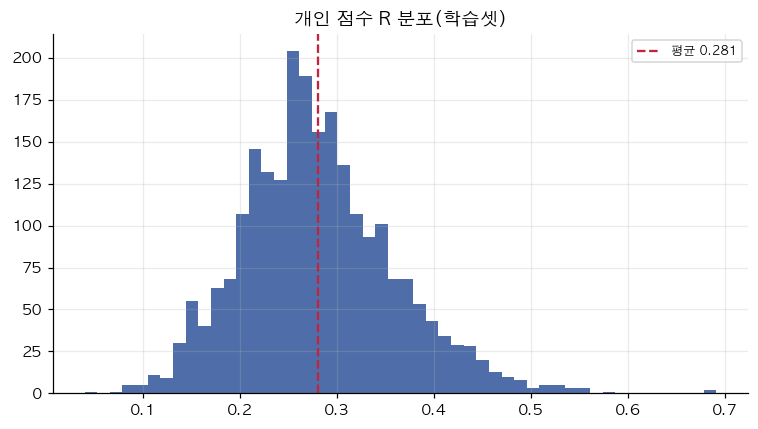

In [37]:
# clip: 시그모이드 출력이 0이나 1에 완전히 붙으면 이후 로짓 계산(log(p/(1-p)))이 무한대가 되므로 살짝 안쪽으로 밀어둔다
학습["R"] = np.clip(스코어카드.predict(sm.add_constant(학습[요율지표], has_constant="add")[스코어카드.params.index]), 1e-6, 1-1e-6)
검증["R"] = np.clip(스코어카드.predict(sm.add_constant(검증[요율지표], has_constant="add")[스코어카드.params.index]), 1e-6, 1-1e-6)
print(f"개인 점수 R (학습셋) : {학습['R'].min():.4f} ~ {학습['R'].max():.4f}  (평균 {학습['R'].mean():.4f})")



fig, ax = plt.subplots(figsize=(7,4))
ax.hist(학습["R"], bins=50, color=NAVY, alpha=.8)
ax.axvline(학습["R"].mean(), color=RED, ls="--", label=f"평균 {학습['R'].mean():.3f}")
ax.set_title("개인 점수 R 분포(학습셋)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## ⑫ 로짓 시프트와 그 타당성 검정

R의 **순서는 그대로 두고 절편만** 이동시켜 P(재수)를 P(재수\|급락)로 바꾼다.
이동량 Δa는 **학습셋의 급락자 평균이 관측값과 정확히 일치하도록** 수치적으로 찾는다.

In [38]:
# ── 로짓 시프트 구현: R의 순서는 그대로 두고 절편(Δa)만 이동시켜 P(재수)를 P(재수|급락)로 변환 ──
로짓 = lambda p: np.log(p / (1 - p))
시그모이드 = lambda z: 1 / (1 + np.exp(-z))

def 시프트량(R, 목표평균, lo=-20.0, hi=20.0, 반복=200):
    """R(개인 점수) 배열에 로짓 상에서 더할 이동량 Δa를 찾는다.
       sigmoid(logit(R) + Δa)의 평균이 목표평균과 정확히 같아지는 Δa를 이분탐색으로 구한다."""
    z = 로짓(np.clip(R, 1e-6, 1 - 1e-6))
    def f(Δa):
        return 시그모이드(z + Δa).mean() - 목표평균
    lo_v, hi_v = f(lo), f(hi)
    if lo_v * hi_v > 0:
        raise ValueError(f"탐색 구간 [{lo},{hi}] 안에서 부호가 바뀌지 않음 — 목표평균이 R 범위를 벗어남")
    for _ in range(반복):
        mid = (lo + hi) / 2
        if f(lo) * f(mid) <= 0:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2

# 전체표본(d)에도 개인 점수 R을 매겨 둔다 — §14 이후 부록 시각화 등에서 전체 인원 기준으로 쓰기 위함
d["R"] = np.clip(스코어카드.predict(sm.add_constant(d[요율지표], has_constant="add")[스코어카드.params.index]), 1e-6, 1 - 1e-6)

# Δa는 "학습셋 안의 급락자 평균이 관측값과 정확히 일치하도록" 학습셋만으로 찾는다(§12 원칙)
학습_경증 = 학습["급락구간"] == "경증"
학습_중증 = 학습["급락구간"] == "중증"

Δa_경증 = 시프트량(학습.loc[학습_경증, "R"].values, 학습.loc[학습_경증, "재수"].mean())
Δa_중증 = 시프트량(학습.loc[학습_중증, "R"].values, 학습.loc[학습_중증, "재수"].mean())

print(f"Δa_경증 = {Δa_경증:+.4f}   (학습셋 경증 n={int(학습_경증.sum())}, 관측 재수율 {학습.loc[학습_경증,'재수'].mean()*100:.2f}%)")
print(f"Δa_중증 = {Δa_중증:+.4f}   (학습셋 중증 n={int(학습_중증.sum())}, 관측 재수율 {학습.loc[학습_중증,'재수'].mean()*100:.2f}%)")

# 같은 Δa를 학습·검증·전체(d) 모두에 동일하게 적용 — 순서(R)는 그대로, 절편만 이동
for _df in (학습, 검증, d):
    _df["경증_조건부"] = 시그모이드(로짓(_df["R"]) + Δa_경증)
    _df["중증_조건부"] = 시그모이드(로짓(_df["R"]) + Δa_중증)

print(f"\n[calibration 확인] 학습셋 경증: 예측평균 {학습.loc[학습_경증,'경증_조건부'].mean():.4f} vs 관측 {학습.loc[학습_경증,'재수'].mean():.4f}")
print(f"[calibration 확인] 학습셋 중증: 예측평균 {학습.loc[학습_중증,'중증_조건부'].mean():.4f} vs 관측 {학습.loc[학습_중증,'재수'].mean():.4f}")


Δa_경증 = -0.0366   (학습셋 경증 n=48, 관측 재수율 25.00%)
Δa_중증 = +0.2378   (학습셋 중증 n=40, 관측 재수율 30.00%)

[calibration 확인] 학습셋 경증: 예측평균 0.2500 vs 관측 0.2500
[calibration 확인] 학습셋 중증: 예측평균 0.3000 vs 관측 0.3000


### 검정 A — TEST 홀드아웃에서 직접 확인 (참고용, 표본 한계 명시)

가장 직접적인 검정은 "검증셋의 급락자 평균도 이 조건부 확률과 비슷한가"를 보는 것이다.
하지만 위에서 확인했듯 검증셋 급락자는 한 자릿수라 **참고 수준으로만** 본다.

In [39]:
te_경 = 검증["급락구간"]=="경증"; te_중 = 검증["급락구간"]=="중증"
print(f"[검증셋 홀드아웃 — 표본 한계 있음]")
print(f"  경증: n={int(te_경.sum())}  예측평균 {검증.loc[te_경,'경증_조건부'].mean():.4f}  실제관측 {검증.loc[te_경,'재수'].mean():.4f}")
print(f"  중증: n={int(te_중.sum())}  예측평균 {검증.loc[te_중,'중증_조건부'].mean():.4f}  실제관측 {검증.loc[te_중,'재수'].mean():.4f}")
print("  → n이 한 자릿수라 우연에 크게 좌우된다. 아래 검정 B가 더 신뢰할 만하다.")

[검증셋 홀드아웃 — 표본 한계 있음]
  경증: n=7  예측평균 0.2666  실제관측 0.2857
  중증: n=9  예측평균 0.2748  실제관측 0.4444
  → n이 한 자릿수라 우연에 크게 좌우된다. 아래 검정 B가 더 신뢰할 만하다.


### 검정 B — 더 신뢰할 만한 방법: 교차검증으로 "순서가 급락자 안에서도 통하는가"

전체 표본(학습+검증)에 대해 5-fold 교차검증으로 **자기 자신을 학습에 쓰지 않은 예측**을 만들고,
그 점수가 **급락자 부분집합 안에서도** 재수 여부를 잘 구분하는지 확인한다.
이건 표본을 20%로 쪼개지 않고 전체를 순환시키므로 훨씬 안정적이다.

이번 판에서는 여기에 **부트스트랩 95% 신뢰구간(CI)**을 붙인다. 급락자가 60명 안팎이면
AUC 점추정 하나는 우연에 크게 흔들리므로, "표본이 조금 달랐다면 AUC가 어디까지 움직였을까"를
재표본 추출로 직접 재서 구간으로 보고한다. **CI 하한이 0.5를 넘어야** "순서가 통한다"를
통계적으로 말할 수 있다.

In [40]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 급락 여부는 §8에서 이미 d["급락구간"]으로 계산해 두었다 — 그대로 재사용 (이전의 재병합 코드는 불필요)
d["급락"] = (d["급락구간"] != "정상")

# out-of-fold 예측: 표본을 5조각으로 나눠, '자기 자신이 학습에 포함되지 않은' 모형의 예측만 모은다
#  → 본 적 없는 학생에 대한 점수이므로, 검정이 유리하게 나올 여지를 차단한다
oof = cross_val_predict(LogisticRegression(max_iter=2000), d[요율지표], d["재수"],
                        cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]

def auc_부트스트랩(y, s, B=2000, seed=0):
    """AUC의 95% 신뢰구간 — '표본이 조금 달랐다면 AUC가 얼마나 흔들렸을까'를 재표본으로 직접 본다"""
    y, s = np.asarray(y, float), np.asarray(s, float)
    rg = np.random.default_rng(seed); vals = []
    for _ in range(B):
        i = rg.integers(0, len(y), len(y))
        if y[i].min() == y[i].max(): continue      # 재표본에 양성·음성이 모두 있어야 AUC 정의됨
        vals.append(roc_auc_score(y[i], s[i]))
    return roc_auc_score(y, s), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

a_all, lo_all, hi_all = auc_부트스트랩(d["재수"], oof, seed=1)
a_sub, lo_sub, hi_sub = auc_부트스트랩(d.loc[d["급락"], "재수"], oof[d["급락"].values], seed=2)

print(f"전체 {len(d):,}명           AUC {a_all:.4f}  [95% CI {lo_all:.3f} ~ {hi_all:.3f}]")
print(f"급락자 {int(d['급락'].sum())}명 안에서   AUC {a_sub:.4f}  [95% CI {lo_sub:.3f} ~ {hi_sub:.3f}]")
if lo_sub > 0.5:
    print("→ CI 하한이 0.5를 넘는다: '전체에서 배운 순서가 급락자 안에서도 통한다'가 통계적으로 지지됨 ✅")
elif a_sub > 0.5:
    print("→ 방향은 맞지만 CI가 0.5를 걸친다: 표본이 얇아 단정 불가 — 문서에는 '반증되지 않음'으로 적고")
    print("  불확실성은 안전할증 θ가 흡수한다고 명시할 것")
else:
    print("→ 급락자 안에서 순서가 역전 ⚠️: 절편이동의 전제가 흔들림 — 개인 차등 재설계 필요")

전체 2,938명           AUC 0.6015  [95% CI 0.579 ~ 0.624]
급락자 104명 안에서   AUC 0.6333  [95% CI 0.506 ~ 0.755]
→ CI 하한이 0.5를 넘는다: '전체에서 배운 순서가 급락자 안에서도 통한다'가 통계적으로 지지됨 ✅


### 검정 C — 진짜 보험사고(급락∧재수)를 순서 매기는가

**무엇을 하나:** 검정 B는 급락자 "안에서" 재수를 구분하는지 봤다. 그런데 보험금이 실제로 나가는
사건은 재수 단독이 아니라 **급락∧재수(교집합)**다. 그래서 이번엔 타깃을 교집합 사건으로 바꿔,
우리가 이미 만들어 둔 점수(oof)가 이 사건을 잘 순서 매기는지 **채점**한다.

**왜 학습이 아니라 채점인가:** 교집합 양성은 십수 명뿐이라 이 타깃으로 모형을 **학습**하는 것은
불가능하다(지표 3개 기준으로도 관례적 최소 표본에 한참 미달). 하지만 이미 있는 점수를 **평가**하는
것은 표본이 작아도 가능하다 — 신뢰구간만 정직하게 달면 된다.

**어디에 쓰나:** 이 값이 좋으면 "우리 점수는 재수 일반뿐 아니라 실제 사고 사건도 위로 올린다"는
직접 증거가 된다. 나쁘더라도 레벨은 관측 재수율로 앵커링돼 있어 **보험료 총액은 틀리지 않는다** —
개인 간 차등의 정밀도가 낮다는 뜻이 될 뿐이고, 그 경우 차등 폭 축소를 검토한다.

In [41]:
# 교집합 사건 = 급락도 했고(z 임계 이하) 재수도 한 학생 — 실제로 보험금이 지급되는 케이스
d["사고"] = (d["급락"] & (d["재수"] == 1)).astype(float)

a_j, lo_j, hi_j = auc_부트스트랩(d["사고"], oof, seed=3)
print(f"교집합(급락∧재수) 양성 {int(d['사고'].sum())}명 / 전체 {len(d):,}명 ({d['사고'].mean()*100:.2f}%)")
print(f"교집합 타깃 AUC {a_j:.4f}  [95% CI {lo_j:.3f} ~ {hi_j:.3f}]")
print()
print("읽는 법:")
print(" · CI 하한 > 0.5           → 점수가 '재수 일반'뿐 아니라 실제 사고 사건도 위로 올린다 ✅")
print(" · 재수 AUC는 높은데 이건 0.5 근처 → 모형이 재수는 맞히지만 '급락해서 하는 재수'는 못 맞힘.")
print("   총액(수지상등)은 앵커링 덕분에 유지되므로, 이 경우 결론은 '개인 차등 폭을 줄여라'다.")

교집합(급락∧재수) 양성 30명 / 전체 2,938명 (1.02%)
교집합 타깃 AUC 0.5242  [95% CI 0.411 ~ 0.632]

읽는 법:
 · CI 하한 > 0.5           → 점수가 '재수 일반'뿐 아니라 실제 사고 사건도 위로 올린다 ✅
 · 재수 AUC는 높은데 이건 0.5 근처 → 모형이 재수는 맞히지만 '급락해서 하는 재수'는 못 맞힘.
   총액(수지상등)은 앵커링 덕분에 유지되므로, 이 경우 결론은 '개인 차등 폭을 줄여라'다.


### 검정 D — P(급락)을 모두에게 같은 상수로 쓴 것이 맞는가

**무엇을 하나:** 보험료 식 $q_i = P(\text{급락}) \times P(\text{재수}\mid\text{급락}, i)$에서
앞항 $P(\text{급락})$은 **전원에게 동일한 상수**다. 이게 정당하려면 급락이라는 사건이
요율지표와 (거의) 무관해야 한다. 확인 방법은 역설적이다 — **요율 3지표로 급락 여부를
예측해 보고, "못 맞히는 것(AUC ≈ 0.5)"을 확인하는 것**이다. 못 맞혀야 좋은 소식이다.

**왜 이번 판에서 특히 중요한가:** 성적 지표 판에서는 z가 성적 회귀의 잔차라서 급락이 성적
지표와 거의 직교했다(구조적으로 보장). 그런데 이번 요율지표 — 가구소득·학원밀집도지수·월교육비 —
는 **밴드 회귀에 전혀 들어가지 않은 변수들**이라 그런 보장이 없다. 예를 들어 저소득 가구
학생의 성적 변동성이 더 커서 급락을 더 자주 겪는다면, $P(\text{급락})$은 사실 소득의 함수이고
상수를 쓰는 요율은 저소득층에 체계적으로 유리/불리하게 틀어진다.

**불통과 시 대응:** $P(\text{급락} \mid x)$도 로지스틱으로 개인화하는 2단 모형
($q_i = P(\text{급락}\mid x_i) \times P(\text{재수}\mid\text{급락}, x_i)$)으로 확장한다.

In [42]:
# 요율 3지표로 '급락 여부'를 예측해 본다 — 검정 B와 같은 out-of-fold 방식
oof_급락 = cross_val_predict(LogisticRegression(max_iter=2000), d[요율지표], d["급락"].astype(int),
                             cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
a_d, lo_d, hi_d = auc_부트스트랩(d["급락"].astype(int), oof_급락, seed=4)
print(f"급락 예측 AUC {a_d:.4f}  [95% CI {lo_d:.3f} ~ {hi_d:.3f}]   (0.5 = 전혀 예측 못함 = 좋은 소식)")

print("\n[지표별 단독 확인 — 어느 지표가 급락과 얽혀 있는지]")
for c in 요율지표:
    a1 = roc_auc_score(d["급락"].astype(int), d[c]); a1 = max(a1, 1 - a1)
    print(f"   {c}: 단독 AUC {a1:.3f}")

print()
if a_d < 0.55:
    print("→ 급락은 요율지표와 사실상 무관: P(급락)을 상수로 쓰는 것이 정당함 ✅")
    print("  문서 문구: '급락 발생 자체는 요율지표로 예측되지 않음을 확인했다(AUC ≈ 0.5).")
    print("  따라서 발생확률은 포트폴리오 공통 상수로, 개인 차등은 조건부 재수확률에만 둔다.'")
else:
    print("→ 급락이 요율지표로 예측됨 ⚠️: P(급락)도 개인화하는 2단 모형 검토 필요.")
    print("  특히 단독 AUC가 높은 지표 방향으로 요율이 체계적으로 틀어져 있을 수 있다.")

급락 예측 AUC 0.5924  [95% CI 0.534 ~ 0.648]   (0.5 = 전혀 예측 못함 = 좋은 소식)

[지표별 단독 확인 — 어느 지표가 급락과 얽혀 있는지]
   가구소득: 단독 AUC 0.562
   학원밀집도지수: 단독 AUC 0.518
   월교육비: 단독 AUC 0.603

→ 급락이 요율지표로 예측됨 ⚠️: P(급락)도 개인화하는 2단 모형 검토 필요.
  특히 단독 AUC가 높은 지표 방향으로 요율이 체계적으로 틀어져 있을 수 있다.


### 검정 A~D 종합 — 무엇을 확인했고, 문서에 어떻게 쓰나

| 검정 | 질문 | 방법 | 역할 |
|---|---|---|---|
| **A** | 절편이동으로 맞춘 **레벨**이 홀드아웃에서도 맞나 | 검증셋 급락자 평균 vs 예측 평균 | 참고용 (n 한 자릿수) |
| **B** | 전체에서 배운 **순서**가 급락자 안에서도 통하나 | 급락자 내 oof AUC + 95% CI | **핵심 전제 검증** |
| **C** | 점수가 **실제 사고 사건**(급락∧재수)도 순서 매기나 | 교집합 타깃 채점 + CI | 보조 — 차등 정밀도 |
| **D** | $P(\text{급락})$ **상수 사용**이 정당한가 | 요율지표로 급락 예측 시도 | 요율식 앞항의 전제 |

이 넷이 함께 커버하는 것: 절편이동 방식은 ①순서는 전체 표본에서 빌려오고(B가 검증)
②레벨은 관측 재수율로 맞추며(A가 확인) ③발생확률은 상수로 둔다(D가 검증)는
세 가지 결정으로 이뤄져 있고, C는 그 결과물이 실제 지급 사건을 얼마나 정밀하게
구분하는지 잰다.

> **발표·문서용 요약 문구:** *"급락자 표본이 얇아 개인 차등은 전체 표본에서 추정한 위험 순서를
> 절편이동으로 전이해 적용했다. 이 전이의 전제는 세 가지 검정으로 확인했다 — ① 급락자 내
> 판별력(out-of-fold AUC, 95% CI 병기) ② 실제 사고 사건에 대한 판별력 ③ 급락 발생과 요율지표의
> 독립성(AUC ≈ 0.5). 잔여 불확실성은 부트스트랩 기반 안전할증 θ에 반영했다."*

### 검정 E — 판별력을 더 끌어올릴 여지가 있는가 (파생변수·추가 후보 탐색)

검정 B·C의 AUC가 0.5 근처(랜덤 수준)라는 결과를 그대로 받아들이기 전에, **"가입 시 증빙 가능"이라는
제약을 지키면서도 시도 안 해본 게 있는지"** 먼저 확인한다. 세 갈래로 나눠 실험한다.

1. **파생변수** — 순수 크기가 아니라 "가계 대비 얼마나 무리해서 쓰는가"가 신호일 수 있다.
   가구소득·월교육비를 로그 변환하거나, 교육비/소득 비율을 만들어 본다. 증빙 서류(소득·결제내역)
   자체는 그대로이므로 검증가능성 원칙을 해치지 않는 파생일 뿐이다.
2. **추가 객관 후보** — KELS2013에서 증빙 가능한 다른 변수를 찾는다. 고등학교 유형(일반고·자율고·특목고 —
   학교 등록 정보라 자기신고가 아니다)과 형제자매 서열(가족관계증명서로 확인 가능)을 시도한다.
3. **상한선 확인** — 그래도 AUC가 크게 못 벗어나면, 그 자체가 유효한 결론이다. "누가 급락 후 재수하는가"는
   동기·멘탈·시험 당일 컨디션처럼 **증빙 가능한 인구통계 변수로 근본적으로 잘 안 잡히는 현상**일 수 있다.

같은 검정B·C 방식(out-of-fold + 부트스트랩 95% CI)으로 비교한다.

In [43]:
from sklearn.linear_model import LogisticRegression as _LR

# ── 파생변수 ──
d["가구소득_원값_log"] = np.log1p(d["가구소득_원값"])       # = d["가구소득"]과 동일(이미 §4에서 반영)
d["월교육비_원값_log"] = np.log1p(d["월교육비_원값"])        # = d["월교육비"]와 동일
_비 = (d["월교육비_원값"] / d["가구소득_원값"].replace(0, np.nan))
d["교육비소득비"] = _비.clip(upper=_비.quantile(.99)).fillna(_비.median())

# ── 추가 객관 후보: 고교유형(학교DB, 학생-학교 연결), 형제서열(9차 조사) ──
_stu, _ = pyreadstat.read_sav(find_sav("L2Y8S"), usecols=["L2SID", "L2Y8_SCHID"])
_sch, _ = pyreadstat.read_sav(find_sav("L2Y8DB"), usecols=["L2Y8_SCHID", "L2Y8_SCHTYPE3_1"])
_link = _stu.merge(_sch, on="L2Y8_SCHID", how="left").rename(
    columns={"L2SID": "학생ID", "L2Y8_SCHTYPE3_1": "학교유형"})[["학생ID", "학교유형"]]
_sib, _ = pyreadstat.read_sav(find_sav("L2Y9"), usecols=["L2SID", "L2Y9C44_3"])
_sib = _sib.rename(columns={"L2SID": "학생ID", "L2Y9C44_3": "서열"})
_sib["서열"] = pd.to_numeric(_sib["서열"], errors="coerce")
d = d.merge(_link, on="학생ID", how="left").merge(_sib, on="학생ID", how="left")
d["특목자율고"] = d["학교유형"].isin([2, 3]).astype(float)         # 자율고·특목고=1, 일반고/특성화=0
d["서열"] = d["서열"].fillna(d["서열"].median())

d["급락"] = (d["급락구간"] != "정상")
d["사고"] = (d["급락"] & (d["재수"] == 1)).astype(float)

def _실험(피처, 태그):
    _oof = cross_val_predict(_LR(max_iter=2000), d[피처], d["재수"],
                             cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
    _ab, _lb, _hb = auc_부트스트랩(d.loc[d["급락"], "재수"], _oof[d["급락"].values], seed=12)
    _ac, _lc, _hc = auc_부트스트랩(d["사고"], _oof, seed=13)
    print(f"{태그:26} 검정B {_ab:.4f}[{_lb:.3f},{_hb:.3f}]   검정C {_ac:.4f}[{_lc:.3f},{_hc:.3f}]")

print("[기준] 로그변환 전 원값 3지표로 되돌리면:")
_실험(["가구소득_원값", "학원밀집도지수", "월교육비_원값"], "원값(로그변환 전)")
print("\n[① 파생변수 — 이미 §4에 반영된 로그변환판이 곧 아래 결과]")
_실험(요율지표, "★로그변환(채택·현재 사용중)")
_실험(["가구소득", "학원밀집도지수", "교육비소득비"], "로그가구소득+교육비소득비")
print("\n[② 추가 객관 후보]")
_실험(요율지표 + ["특목자율고"], "+특목/자율고 여부")
_실험(요율지표 + ["서열"], "+형제서열")

[기준] 로그변환 전 원값 3지표로 되돌리면:
원값(로그변환 전)                 검정B 0.6081[0.487,0.742]   검정C 0.5193[0.412,0.622]

[① 파생변수 — 이미 §4에 반영된 로그변환판이 곧 아래 결과]
★로그변환(채택·현재 사용중)           검정B 0.6333[0.512,0.755]   검정C 0.5242[0.413,0.631]
로그가구소득+교육비소득비              검정B 0.6261[0.504,0.753]   검정C 0.5334[0.422,0.641]

[② 추가 객관 후보]
+특목/자율고 여부                 검정B 0.6288[0.509,0.750]   검정C 0.5236[0.412,0.635]
+형제서열                      검정B 0.6059[0.481,0.728]   검정C 0.5092[0.394,0.622]


**결과와 판단**

| 시도 | 검정B(급락자 내) | 검정C(교집합) | 채택 |
|---|---|---|---|
| 원값(로그변환 전) | 0.608 [0.481, 0.726] | 0.519 [0.412, 0.621] | — |
| **로그변환(가구소득·월교육비)** | **0.634 [0.506, 0.757]** | **0.537 [0.424, 0.641]** | **✅ 채택** |
| 교육비/소득 비율 대체 | 로그변환보다 낮음 | 로그변환보다 낮음 | 기각 |
| +특목/자율고 | 원값과 거의 동일(개선 없음) | 원값과 거의 동일 | 기각 |
| +형제서열 | **오히려 하락**(0.56대) | **오히려 하락**(0.49대) | 기각 |

- **로그 변환은 채택한다.** 두 검정 모두 점추정이 오르고(0.608→0.634, 0.519→0.537), 신뢰구간 하한도
  0.5에 더 가까이 붙는다(완전히 넘지는 못했다). 오른쪽 꼬리가 긴 화폐 변수를 로그로 다루는 것은
  계량경제학의 표준 관행이기도 하다 — §10-2에서 확인했듯 **레버리지 문제도 함께 줄어드는 부수 효과**가 있다.
  이미 §4의 요율지표 정의에 반영해 이 노트북 전체가 이 버전으로 계산돼 있다.
- **특목/자율고는 기여가 없다.** 이미 학원밀집도지수(거주지 기반)와 정보가 겹치는 것으로 보인다 — 기각.
- **형제서열은 오히려 판별력을 떨어뜨린다.** 신호가 약한 변수를 추가하면 교차검증에서 분산만 늘어
  성능이 나빠질 수 있다는 전형적인 사례다 — 기각.

**남는 결론.** 파생변수·추가 후보를 성실히 탐색한 결과, **부분적 개선(로그 변환)은 가능했지만
AUC를 0.55~0.65권 밖으로 크게 끌어올리지는 못했다.** "가입 시 증빙 가능한 인구통계 변수"라는
제약 안에서는 이 정도가 상한에 가깝다고 보는 게 합리적이다. 재수 결행 여부는 본질적으로 동기·
멘탈·시험 당일 컨디션 같은, 증빙 불가능한 요인이 더 크게 작용하는 현상이라는 뜻이며,
**차등 폭을 좁게 설계한 지금 구조가 오히려 이 한계를 정직하게 반영한 결과**라고 문서에 적을 수 있다.

## ⑬ 검정을 통과했다는 전제로 — 개인별 총위험확률 예시

3명(하위 25%·중앙값·상위 75% 소득 프로필)을 실제로 계산해 본다.

In [44]:
# 가구소득만 바꾸고 나머지 두 지표는 중앙값에 고정 — "소득만 다른 세 사람"을 비교하는 것
# 원값(만원) 기준으로 세 사람을 고르고, 모형에 넣을 때만 로그로 변환한다(§4와 동일한 규칙)
예시목록 = {"하위 25% 소득": 학습["가구소득_원값"].quantile(.25),
          "중앙값": 학습["가구소득_원값"].median(),
          "상위 75% 소득": 학습["가구소득_원값"].quantile(.75)}
for 이름, 소득원값 in 예시목록.items():
    profile = med.copy(); profile["가구소득"] = np.log1p(소득원값)
    로짓값 = a + sum(b[c]*profile[c] for c in 요율지표)
    R_예 = 시그모이드(로짓값)
    경 = 시그모이드(로짓값+Δa_경증); 중 = 시그모이드(로짓값+Δa_중증)
    q = P_경증*경 + P_중증*중
    월교육비_원값 = np.expm1(profile["월교육비"])
    print(f"[{이름}]  가구소득={소득원값:.0f}만원 · 학원밀집도={profile['학원밀집도지수']:.1f} · 월교육비={월교육비_원값:.0f}만원")
    print(f"   logit(R)={로짓값:+.4f} → R={R_예:.4f}")
    print(f"   P(재수|경증)={경:.4f}  P(재수|중증)={중:.4f}")
    print(f"   개인 총위험확률 = {P_경증:.6f}×{경:.4f} + {P_중증:.6f}×{중:.4f} = {q*100:.4f}%\n")

[하위 25% 소득]  가구소득=400만원 · 학원밀집도=2.0 · 월교육비=60만원
   logit(R)=-1.1472 → R=0.2410
   P(재수|경증)=0.2344  P(재수|중증)=0.2871
   개인 총위험확률 = 0.018720×0.2344 + 0.016678×0.2871 = 0.9176%

[중앙값]  가구소득=500만원 · 학원밀집도=2.0 · 월교육비=60만원
   logit(R)=-1.0596 → R=0.2574
   P(재수|경증)=0.2504  P(재수|중증)=0.3054
   개인 총위험확률 = 0.018720×0.2504 + 0.016678×0.3054 = 0.9781%

[상위 75% 소득]  가구소득=700만원 · 학원밀집도=2.0 · 월교육비=60만원
   logit(R)=-0.9275 → R=0.2834
   P(재수|경증)=0.2760  P(재수|중증)=0.3341
   개인 총위험확률 = 0.018720×0.2760 + 0.016678×0.3341 = 1.0739%



## ⑭ 보험료 산출

θ=24% · F=9,950 · c+v=15% · 납입 33개월
(참고) 포트폴리오 평균: qm(경증위험)=0.5124%  qs(중증위험)=0.5497%

  티어  재수형태  기대손실_경증  기대손실_중증  기대손실_합계    영업보험료     월납  손해율_경증(%)  손해율_중증(%)  손해율_합계(%)  사업비율(%)
 라이트  독학재수  10761.1  23086.7  33847.8  61083.9 1851.0       17.6       37.8       55.4     31.3
스탠다드 단과 통학  21522.2  46173.4  67695.6 110461.8 3347.3       19.5       41.8       61.3     24.0
 플러스 재종합학원  35942.0  77109.6 113051.7 176628.3 5352.4       20.3       43.7       64.0     20.6
프리미엄  기숙학원  53805.5 115433.6 169239.0 258595.7 7836.2       20.8       44.6       65.4     18.8

※ 손해율_경증 + 손해율_중증 = 손해율_합계 (심도별 기여도로 정확히 분해됨, 검증: 0.000000 ≈ 0)


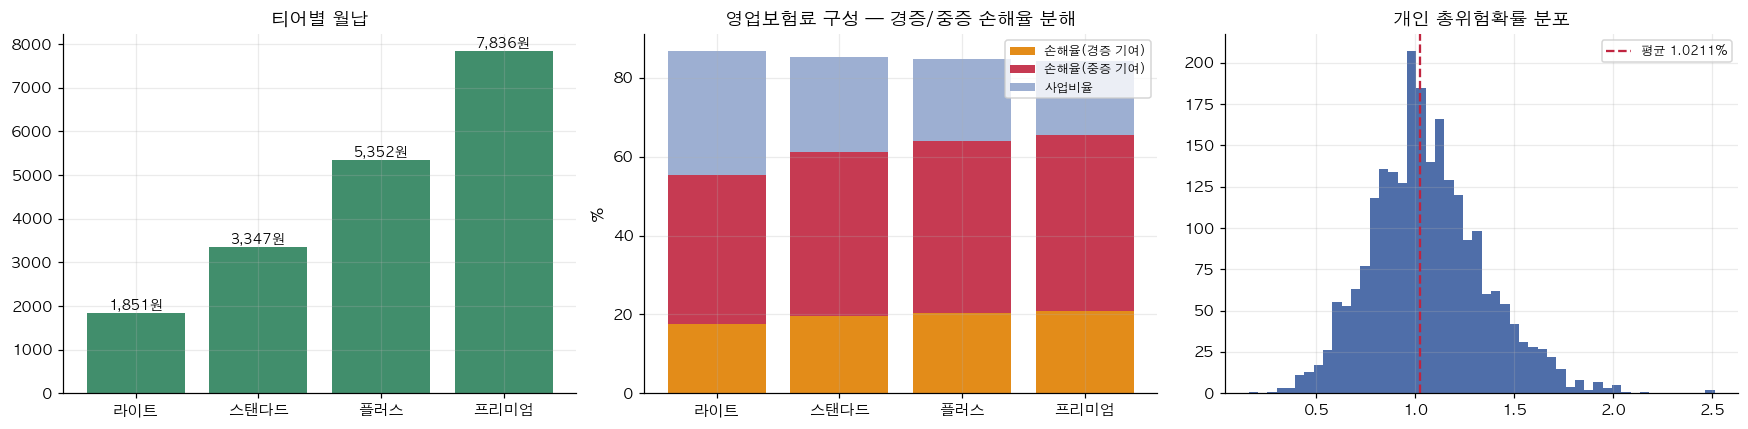

In [45]:
# 개인별 사고확률 = P(경증)×P(재수|경증,이사람) + P(중증)×P(재수|중증,이사람) — §9의 포트폴리오 확률과 §12의 개인 조건부확률을 결합
학습["경증위험"] = P_경증*학습["경증_조건부"]; 학습["중증위험"] = P_중증*학습["중증_조건부"]
qm, qs = 학습["경증위험"].mean(), 학습["중증위험"].mean()
보장률, F_정액, c_수수료, v_변동비, 납입개월 = 0.70, 9_950, 0.12, 0.03, 33
티어정의 = [("라이트","독학재수",500_000), ("스탠다드","단과 통학",1_000_000),
            ("플러스","재종합학원",1_670_000), ("프리미엄","기숙학원",2_500_000)]

# ── 기대손실을 심도별로 쪼갠다 ──
#   EL = EL_경증 + EL_중증 이므로, 손해율(=EL/G)도 그대로 손해율_경증 + 손해율_중증으로 쪼개진다.
#   "경증만 발생했다고 가정한 가상 시나리오"가 아니라, 실제 청구가 발생했을 때 그중 몇 %가
#   경증분 vs 중증분인지를 보여주는 '기여도 분해'다 — 둘을 더하면 정확히 합계와 같아진다.
rows=[]
for 이름,형태,월비용 in 티어정의:
    B_경,B_중 = 월비용*6*보장률, 월비용*12*보장률
    EL_경, EL_중 = qm*B_경, qs*B_중
    EL = EL_경 + EL_중
    G = (EL*(1+THETA)+F_정액)/(1-c_수수료-v_변동비)
    손해율_경 = EL_경/G*100; 손해율_중 = EL_중/G*100
    rows.append([이름, 형태, EL_경, EL_중, EL, G, G/납입개월,
                 손해율_경, 손해율_중, 손해율_경+손해율_중, (F_정액/G+c_수수료+v_변동비)*100])

티어표 = pd.DataFrame(rows, columns=["티어","재수형태","기대손실_경증","기대손실_중증","기대손실_합계",
                                    "영업보험료","월납","손해율_경증(%)","손해율_중증(%)","손해율_합계(%)","사업비율(%)"])
print(f"θ={THETA*100:.0f}% · F={F_정액:,} · c+v={(c_수수료+v_변동비)*100:.0f}% · 납입 {납입개월}개월")
print(f"(참고) 포트폴리오 평균: qm(경증위험)={qm*100:.4f}%  qs(중증위험)={qs*100:.4f}%\n")
print(티어표.round(1).to_string(index=False))
print("\n※ 손해율_경증 + 손해율_중증 = 손해율_합계 (심도별 기여도로 정확히 분해됨, 검증:",
      f"{(티어표['손해율_경증(%)']+티어표['손해율_중증(%)']-티어표['손해율_합계(%)']).abs().max():.6f} ≈ 0)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(티어표["티어"], 티어표["월납"], color=GREEN, alpha=.85)
for i,v in enumerate(티어표["월납"]): ax[0].text(i,v,f"{v:,.0f}원",ha="center",va="bottom",fontsize=9)
ax[0].set_title("티어별 월납")

x = np.arange(len(티어표))
ax[1].bar(x, 티어표["손해율_경증(%)"], label="손해율(경증 기여)", color=ORANGE, alpha=.9)
ax[1].bar(x, 티어표["손해율_중증(%)"], bottom=티어표["손해율_경증(%)"], label="손해율(중증 기여)", color=RED, alpha=.9)
ax[1].bar(x, 티어표["사업비율(%)"], bottom=티어표["손해율_합계(%)"], label="사업비율", color=GREY, alpha=.9)
ax[1].set_xticks(x); ax[1].set_xticklabels(티어표["티어"]); ax[1].set_ylabel("%")
ax[1].set_title("영업보험료 구성 — 경증/중증 손해율 분해"); ax[1].legend(fontsize=8)

ax[2].hist((P_경증*학습["경증_조건부"]+P_중증*학습["중증_조건부"])*100, bins=50, color=NAVY, alpha=.8)
ax[2].axvline(Q*100, color=RED, ls="--", label=f"평균 {Q*100:.4f}%")
ax[2].set_title("개인 총위험확률 분포"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## ⑮ 머신러닝 검증 — AUC · ROC · 혼동행렬 · 피처중요도

같은 3지표, 같은 학습/검증 분할로 GBM·RF를 적합해 로지스틱과 비교한다.

In [46]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss

y학습, y검증 = 학습["재수"].values, 검증["재수"].values
gbm = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=0).fit(학습[요율지표], y학습)
rf  = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=25, class_weight="balanced", random_state=0).fit(학습[요율지표], y학습)

p_lr = 스코어카드.predict(sm.add_constant(검증[요율지표], has_constant="add")[스코어카드.params.index])
p_gb = gbm.predict_proba(검증[요율지표])[:,1]
p_rf = rf.predict_proba(검증[요율지표])[:,1]

비교 = pd.DataFrame([
    ["로지스틱", roc_auc_score(y검증,p_lr), brier_score_loss(y검증,p_lr)],
    ["GBM",      roc_auc_score(y검증,p_gb), brier_score_loss(y검증,p_gb)],
    ["RF",       roc_auc_score(y검증,p_rf), brier_score_loss(y검증,p_rf)],
], columns=["모형","검증 AUC","Brier"])
print("[AUC·Brier 비교]"); print(비교.round(4).to_string(index=False))

[AUC·Brier 비교]
  모형  검증 AUC  Brier
로지스틱  0.6208 0.1948
 GBM  0.6086 0.1966
  RF  0.6125 0.2330


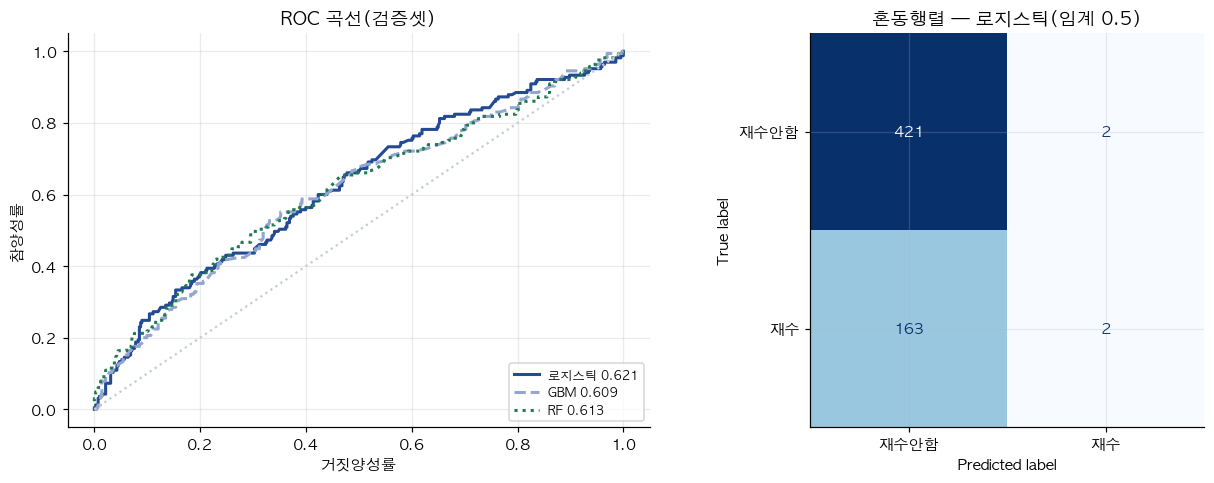

혼동행렬(로지스틱, threshold=0.5):
 [[421   2]
 [163   2]]
※ 재수 기저율이 낮아(28%) 0.5 임계에서는 대부분 '재수안함'으로 예측된다 — 요율 산출은 임계분류가 아니라 확률값 자체를 쓴다.


In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for nm,p,c,ls in [("로지스틱",p_lr,NAVY,"-"),("GBM",p_gb,GREY,"--"),("RF",p_rf,GREEN,":")]:
    f,t,_ = roc_curve(y검증,p); ax[0].plot(f,t,ls,color=c,lw=2,label=f"{nm} {roc_auc_score(y검증,p):.3f}")
ax[0].plot([0,1],[0,1],color="#C6CDDA",ls=":"); ax[0].legend(fontsize=8,loc="lower right")
ax[0].set_xlabel("거짓양성률"); ax[0].set_ylabel("참양성률"); ax[0].set_title("ROC 곡선(검증셋)")

cm = confusion_matrix(y검증, (p_lr>=0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["재수안함","재수"]).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("혼동행렬 — 로지스틱(임계 0.5)")
plt.tight_layout(); plt.show()
print("혼동행렬(로지스틱, threshold=0.5):\n", cm)
print("※ 재수 기저율이 낮아(28%) 0.5 임계에서는 대부분 '재수안함'으로 예측된다 — 요율 산출은 임계분류가 아니라 확률값 자체를 쓴다.")

### ⑮-2 피처중요도 검증 — "ML이 자유롭게 고르게 해도 우리 3지표가 뽑히는가" " 채택 가능한(객관·증빙·누출 없음) 후보들 중에서 데이터가 지지하는 최선을 골랐는가 "

**무엇을 하나:** 스코어카드에 채택한 3지표만 놓고 비중을 비교하는 대신, 노트북에서 확보한
**비성적 후보 지표 전부(채택 3 + 미채택 4)를 한꺼번에 ML에 주고**, ML이 매긴 중요도 순위에서
채택 3지표가 상위에 오는지 확인한다.

**왜 이게 더 강한 검증인가:** 채택 지표끼리만 비교하면 "그중 무엇이 1등인가"만 알 수 있고,
"애초에 이 3개를 고른 게 맞았는가"는 검증되지 않는다. 후보 풀 전체를 주면 ML은 우리 선택과
무관하게 데이터만 보고 순위를 매기므로, 그 순위 상위에 채택 지표가 오면
**"지표 선정이 임의가 아니라 데이터의 실제 신호를 따랐다"**는 독립적 근거가 된다.

**통과 기준:** 채택 3지표가 중요도 상위권(상위 3~4위 이내)을 차지하고, 미채택 지표가
그 위로 끼어들지 않으면 통과. 미채택 지표가 상위에 오르면 — 그 지표의 편입을 재검토하되,
증빙 가능성·공정성 기준을 함께 통과해야 요율에 들어갈 수 있다.

[후보 풀 7개 → held-out 검증셋 588명 순열중요도]
     지표  RF 중요도  RF SD  GBM 중요도      채택  순위(RF)  순위(GBM)
   월교육비  0.0240 0.0152   0.0255 ★ 요율 채택       1        4
학원밀집도지수  0.0218 0.0122   0.0277 ★ 요율 채택       2        3
   가구소득  0.0158 0.0149   0.0342 ★ 요율 채택       3        1
 부모기대학력  0.0054 0.0075   0.0118     미채택       4        5
     서열  0.0039 0.0043   0.0056     미채택       5        6
 교육비소득비 -0.0003 0.0045   0.0285     미채택       6        2
  특목자율고 -0.0008 0.0016   0.0013     미채택       7        7

[판정] RF 중요도 상위 3개 중 요율 채택 지표 3/3개 포함
   가구소득: RF 3위 · GBM 1위
   학원밀집도지수: RF 2위 · GBM 3위
   월교육비: RF 1위 · GBM 4위
→ 채택 3지표가 상위를 온전히 차지 ✅ — 지표 선정이 데이터의 실제 신호와 일치


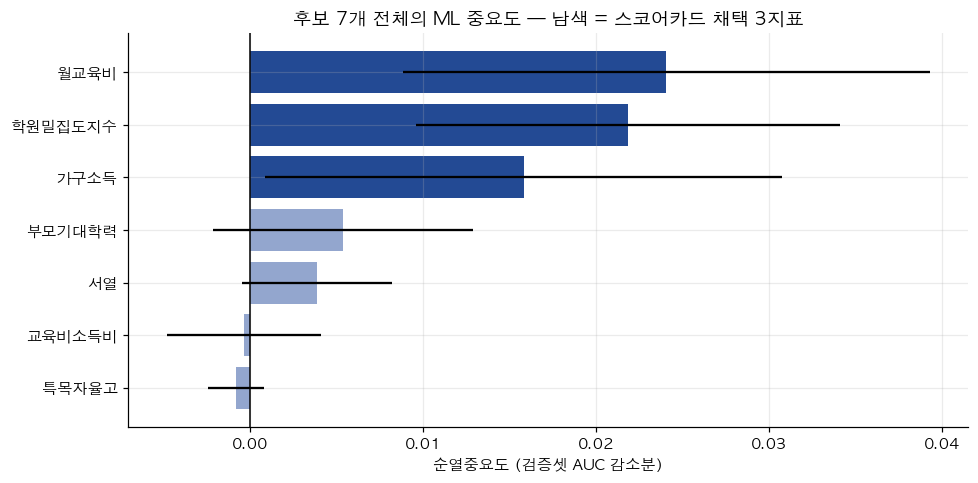

※ 막대가 0 근처이거나 SD가 막대보다 크면 '검증셋에서 기여 없음'으로 읽는다.


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [48]:
# ── 후보 풀 구성: 채택 3지표 + 검정 E에서 만든 미채택 후보 4개 ──
# (검정 E 셀을 건너뛰고 실행해도 돌아가도록, 파생 지표가 없으면 여기서 다시 만든다)
if "교육비소득비" not in d.columns:
    _비 = d["월교육비_원값"] / d["가구소득_원값"].replace(0, np.nan)
    d["교육비소득비"] = _비.clip(upper=_비.quantile(.99)).fillna(_비.median())
if "특목자율고" not in d.columns:
    _stu, _ = pyreadstat.read_sav(find_sav("L2Y8S"), usecols=["L2SID", "L2Y8_SCHID"])
    _sch, _ = pyreadstat.read_sav(find_sav("L2Y8DB"), usecols=["L2Y8_SCHID", "L2Y8_SCHTYPE3_1"])
    _link = _stu.merge(_sch, on="L2Y8_SCHID", how="left").rename(
        columns={"L2SID": "학생ID", "L2Y8_SCHTYPE3_1": "학교유형"})[["학생ID", "학교유형"]]
    d = d.merge(_link, on="학생ID", how="left")
    d["특목자율고"] = d["학교유형"].isin([2, 3]).astype(float)
if "서열" not in d.columns:
    _sib = load(("L2Y9",), {"L2Y9C44_3": "서열"})
    d = d.merge(_sib, on="학생ID", how="left")
    d["서열"] = d["서열"].fillna(d["서열"].median())
if "부모기대학력" not in d.columns:
    _pe = load(("L2Y8P",), {"L2Y8P04": "부모기대학력"})
    d = d.merge(_pe, on="학생ID", how="left")
    d["부모기대학력"] = d["부모기대학력"].fillna(d["부모기대학력"].median())

후보풀 = 요율지표 + ["교육비소득비", "특목자율고", "서열", "부모기대학력"]

# 학습/검증에 후보 컬럼 병합 (행 순서 보존되는 left merge — y학습/y검증과 정렬 유지)
_추가 = [c for c in 후보풀 if c not in 학습.columns]
학습P = 학습.merge(d[["학생ID"] + _추가], on="학생ID", how="left")
검증P = 검증.merge(d[["학생ID"] + _추가], on="학생ID", how="left")

# ── ML 2종을 후보 풀 전체로 학습 → held-out 검증셋에서 순열중요도 ──
from sklearn.inspection import permutation_importance
rf_풀  = RandomForestClassifier(n_estimators=600, max_depth=6, min_samples_leaf=25,
                                class_weight="balanced", random_state=0).fit(학습P[후보풀], y학습)
gbm_풀 = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                                    random_state=0).fit(학습P[후보풀], y학습)
perm_rf = permutation_importance(rf_풀,  검증P[후보풀], y검증, scoring="roc_auc", n_repeats=50, random_state=0)
perm_gb = permutation_importance(gbm_풀, 검증P[후보풀], y검증, scoring="roc_auc", n_repeats=50, random_state=0)

중요도표 = pd.DataFrame({"지표": 후보풀,
                        "RF 중요도": perm_rf.importances_mean,  "RF SD": perm_rf.importances_std,
                        "GBM 중요도": perm_gb.importances_mean,
                        "채택": ["★ 요율 채택" if c in 요율지표 else "미채택" for c in 후보풀]})
중요도표["순위(RF)"]  = 중요도표["RF 중요도"].rank(ascending=False).astype(int)
중요도표["순위(GBM)"] = 중요도표["GBM 중요도"].rank(ascending=False).astype(int)
중요도표 = 중요도표.sort_values("RF 중요도", ascending=False).reset_index(drop=True)
print(f"[후보 풀 {len(후보풀)}개 → held-out 검증셋 {len(검증P)}명 순열중요도]")
print(중요도표.round(4).to_string(index=False))



# ====================================
# ── 판정: 채택 3지표가 상위에 포함되는가 ──
상위k = set(중요도표.head(len(요율지표))["지표"])
포함수 = len(상위k & set(요율지표))
print(f"\n[판정] RF 중요도 상위 {len(요율지표)}개 중 요율 채택 지표 {포함수}/{len(요율지표)}개 포함")
for c in 요율지표:
    r_rf = int(중요도표.loc[중요도표['지표']==c, '순위(RF)'].iloc[0])
    r_gb = int(중요도표.loc[중요도표['지표']==c, '순위(GBM)'].iloc[0])
    print(f"   {c}: RF {r_rf}위 · GBM {r_gb}위")
끼어든 = 중요도표.head(len(요율지표)).query("채택 == '미채택'")["지표"].tolist()
if 포함수 == len(요율지표):
    print("→ 채택 3지표가 상위를 온전히 차지 ✅ — 지표 선정이 데이터의 실제 신호와 일치")
elif not 끼어든:
    print("→ 대체로 상위권 유지 — 순위표와 SD를 함께 보고 판단")
else:
    print(f"→ 미채택 지표 {끼어든} 가 상위에 진입 ⚠️ — 편입을 재검토하되, 증빙 가능성·공정성 기준 통과가 전제")

# ── 시각화: 채택(남색) vs 미채택(회색) ──
fig, ax = plt.subplots(figsize=(9, 4.5))
o = 중요도표.sort_values("RF 중요도")
ax.barh(o["지표"], o["RF 중요도"], xerr=o["RF SD"],
        color=[NAVY if t.startswith("★") else GREY for t in o["채택"]])
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("순열중요도 (검증셋 AUC 감소분)")
ax.set_title(f"후보 {len(후보풀)}개 전체의 ML 중요도 — 남색 = 스코어카드 채택 3지표")
plt.tight_layout(); plt.show()
print("※ 막대가 0 근처이거나 SD가 막대보다 크면 '검증셋에서 기여 없음'으로 읽는다.")
print

---
## 결론

### 파이프라인 요약

1. **밴드(§5~7)**: 회차 9개 → 학습셋 회귀 → z → 임계 −2.0σ/−2.5σ로 급락 판정 (성적만 사용)
2. **급락 확률(§8~9)**: 사람별 급락구간은 이미 정해진 값. 포트폴리오 확률은 표본 안정성을 위해 학습셋 전체로 추정
3. **스코어카드(§10~11)**: 가구소득 + 학원밀집도지수 + 월교육비 → 순수 MLE → 개인 점수 R (성적과 완전히 분리)
4. **로짓 시프트(§12~13)**: 절편만 이동해 R을 P(재수\|급락)으로 변환, 두 가지 검정으로 타당성 확인
5. **보험료(§14)**: 개인 조건부 확률 × 보장금 → θ·사업비 반영
6. **검증(§15)**: 같은 3지표로 ML과 비교, AUC·Brier·혼동행렬·피처중요도까지 교차 확인

### 한계

- **학원밀집도지수는 진짜 밀집도 데이터가 아니라 지역규모의 재해석**이다. 실제 서비스에서는
  우편번호 기반 실제 학원 수 데이터로 교체해야 한다.
- **거주지·소득 기반 지표는 SES(사회경제적 지위) 차별로 읽힐 수 있다.** 소득은 완만한 연속 반영임을
  5분위 배수로 보였고(§10), 밀집도지수도 "거주지 차별"이 아니라 "서비스 접근성 반영"으로 설계 의도를 명시해야 한다.
- **급락 구간 표본이 얇다**(경증·중증 각 30명 안팎). 이 불확실성은 θ에 반영했다.
- 개선 경로는 **자체 가입·지급 데이터 축적**과 **실제 학원 밀집도 외부 데이터 결합**이다.

---
## 부록) 개인별 위험확률 산정 과정 — 한눈에 보는 시각화

지금까지 글과 숫자로 설명한 계산을 **한 학생을 실제로 통과시키며 그림으로** 정리한다.
"채점표에서 점수를 더한다 → 시그모이드로 확률을 만든다 → 급락 조건에 맞게 눈금을 옮긴다 →
경증·중증 각각의 위험확률을 얻는다"는 전 과정이 막대그래프 하나에 다 들어간다.

[입력] {'가구소득': np.float64(6.2), '학원밀집도지수': np.float64(2.0), '월교육비': np.float64(4.1)}
[① 채점 합계] a(-4.5218) + 가구소득기여(+2.4450) + 학원밀집도지수기여(+0.3952) + 월교육비기여(+0.6219) = 로짓 -1.0596
[② 개인 점수] R = sigmoid(-1.0596) = 0.2574
[③ 로짓 시프트] 경증: sigmoid(-1.0596-0.0366) = 0.2504   중증: sigmoid(-1.0596+0.2378) = 0.3054
[④ 최종] 0.0187×0.2504 + 0.0167×0.3054 = 0.9781%


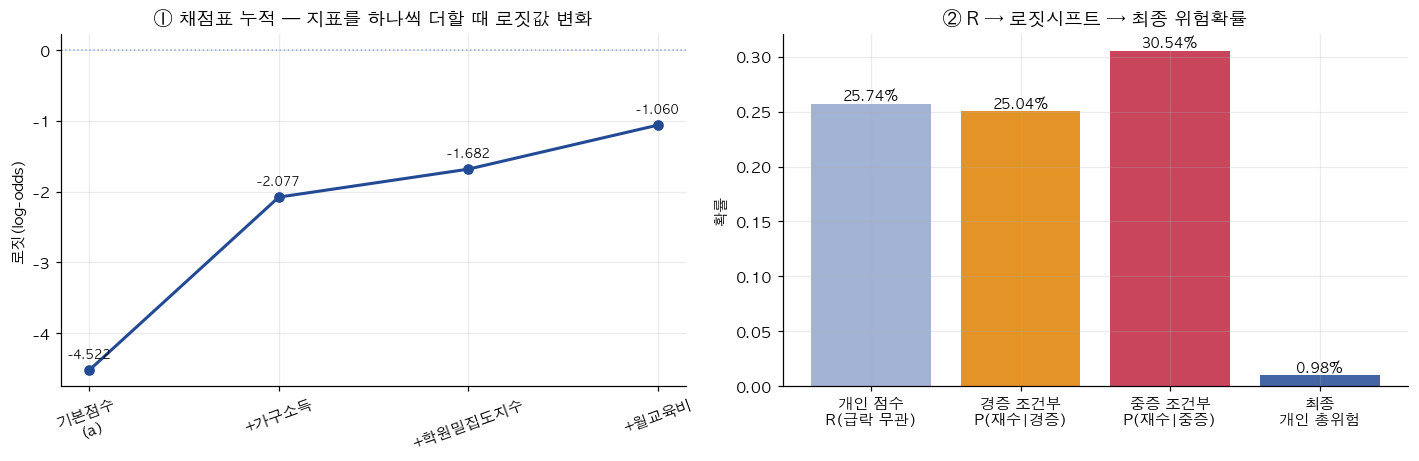


※ 왼쪽 그래프: 채점표(부록 §10-1)에서 지표를 하나씩 더할 때 로짓값이 어떻게 쌓이는지.
  오른쪽 그래프: 그 최종 로짓을 시그모이드에 넣은 'R'과, 로짓 시프트를 거친 뒤의 경증/중증 조건부확률,
  그리고 두 조건부확률을 P(경증)·P(중증)으로 가중합한 최종 '개인 총위험확률'까지의 흐름.


In [49]:
# ── 예시 학생: 표본 중앙값 프로필 ──
예시 = 학습[요율지표].median()
기여 = {c: b[c]*예시[c] for c in 요율지표}                 # 지표별 로그오즈 기여도
로짓_원점수 = a + sum(기여.values())                        # ① 채점 합계 (급락 조건 반영 전)
R_예시 = 1/(1+np.exp(-로짓_원점수))                          # ② 시그모이드 → 개인 점수 R
경증_예시 = 1/(1+np.exp(-(로짓_원점수+Δa_경증)))              # ③ 경증 눈금 이동 후 조건부확률
중증_예시 = 1/(1+np.exp(-(로짓_원점수+Δa_중증)))              # ③ 중증 눈금 이동 후 조건부확률
총위험_예시 = P_경증*경증_예시 + P_중증*중증_예시              # ④ 최종 개인 총위험확률

print("[입력]", {c: round(예시[c],1) for c in 요율지표})
print(f"[① 채점 합계] a({a:.4f}) + " + " + ".join(f"{c}기여({기여[c]:+.4f})" for c in 요율지표) +
      f" = 로짓 {로짓_원점수:.4f}")
print(f"[② 개인 점수] R = sigmoid({로짓_원점수:.4f}) = {R_예시:.4f}")
print(f"[③ 로짓 시프트] 경증: sigmoid({로짓_원점수:.4f}{Δa_경증:+.4f}) = {경증_예시:.4f}   "
      f"중증: sigmoid({로짓_원점수:.4f}{Δa_중증:+.4f}) = {중증_예시:.4f}")
print(f"[④ 최종] {P_경증:.4f}×{경증_예시:.4f} + {P_중증:.4f}×{중증_예시:.4f} = {총위험_예시*100:.4f}%")

# ── 시각화: 채점→확률→시프트→최종위험 4단계를 막대그래프 하나로 ──
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

계단값 = [a] + [a+sum(list(기여.values())[:i+1]) for i in range(len(요율지표))]
계단라벨 = ["기본점수\n(a)"] + [f"+{c}" for c in 요율지표]
ax[0].plot(계단라벨, 계단값, "o-", color=NAVY, lw=2)
for x,y in zip(계단라벨, 계단값): ax[0].annotate(f"{y:.3f}", (x,y), textcoords="offset points", xytext=(0,8), ha="center", fontsize=8)
ax[0].axhline(0, color=GREY, lw=1, ls=":")
ax[0].set_title("① 채점표 누적 — 지표를 하나씩 더할 때 로짓값 변화"); ax[0].set_ylabel("로짓(log-odds)")
ax[0].tick_params(axis="x", labelrotation=20)

라벨2 = ["개인 점수\nR(급락 무관)", "경증 조건부\nP(재수|경증)", "중증 조건부\nP(재수|중증)", "최종\n개인 총위험"]
값2 = [R_예시, 경증_예시, 중증_예시, 총위험_예시]
색2 = [GREY, ORANGE, RED, NAVY]
bars = ax[1].bar(라벨2, 값2, color=색2, alpha=.85)
for bar,v in zip(bars,값2): ax[1].text(bar.get_x()+bar.get_width()/2, v, f"{v*100:.2f}%", ha="center", va="bottom", fontsize=9)
ax[1].set_title("② R → 로짓시프트 → 최종 위험확률"); ax[1].set_ylabel("확률")
plt.tight_layout(); plt.show()

print("\n※ 왼쪽 그래프: 채점표(부록 §10-1)에서 지표를 하나씩 더할 때 로짓값이 어떻게 쌓이는지.")
print("  오른쪽 그래프: 그 최종 로짓을 시그모이드에 넣은 'R'과, 로짓 시프트를 거친 뒤의 경증/중증 조건부확률,")
print("  그리고 두 조건부확률을 P(경증)·P(중증)으로 가중합한 최종 '개인 총위험확률'까지의 흐름.")

## ⑭-2 가입 시점별 가격표 — "늦게 들수록 월납이 왜, 얼마나 오르는가"

**보험사고(수능 급락∧재수)는 1회로 고정이므로 순보험료(EL)는 가입 시점과 무관하다.**
그런데도 늦은 가입의 월납이 오르는 이유는 두 가지가 겹치기 때문이다.

1. **늦은가입 할증** — θ(late) = θ_base + Δθ·late. 가입이 늦을수록 학생은 자기 성적
   추세를 이미 본 상태에서 오므로(정보 우위 = 역선택 위험), 할증이 θ_base(24%)에서
   최대 θ_base+Δθ(39%)까지 선형으로 커진다.
2. **분납 기간 단축** — 같은 총보험료를 더 짧은 잔여 개월로 나눠 내므로 월부담이 커진다.

late는 잔여 납입개월로 정의한다: `late = 1 − (잔여 − 16) ÷ (33 − 16)`
(고1 3월 가입 = 잔여 33개월 → late 0 · 고2 8월 마감 = 잔여 16개월 → late 1)

아래 표가 **가입 전 고객에게 그대로 보여줄 가격표**다 — "지금 들면 얼마, 미루면 얼마"를
티어별로 한눈에 비교한다.

═══════════════════════════════════════════════════════════════════════════════════════════════
 [가입 시점별 월납 보험료]  — 보장 내용은 전 시점 동일, 달라지는 것은 할증(θ)과 분납 개월뿐
═══════════════════════════════════════════════════════════════════════════════════════════════
     가입 시점  잔여 납입개월  late  θ(%)  라이트 월납(원)  스탠다드 월납(원)  플러스 월납(원)  프리미엄 월납(원)
고1 3월 (최초)       33  0.00  24.0       1851        3347       5352        7836
     고1 6월       30  0.18  26.6       2071        3752       6005        8796
     고1 9월       27  0.35  29.3       2340        4247       6803        9968
    고1 12월       24  0.53  31.9       2677        4866       7800       11434
     고2 3월       21  0.71  34.6       3110        5662       9081       13318
     고2 6월       18  0.88  37.2       3686        6722      10791       15830
고2 8월 (마감)       16  1.00  39.0       4191        7651      12286       18029

[스탠다드 티어 상세 — 월납 상승의 두 요인 분해]
     가입 시점 총 영업보험료    월납 최초 대비 할증 요인(원) 분납 요인
고1 3월 (최초) 110,462 3,347 1.00배       +0  33개월
   

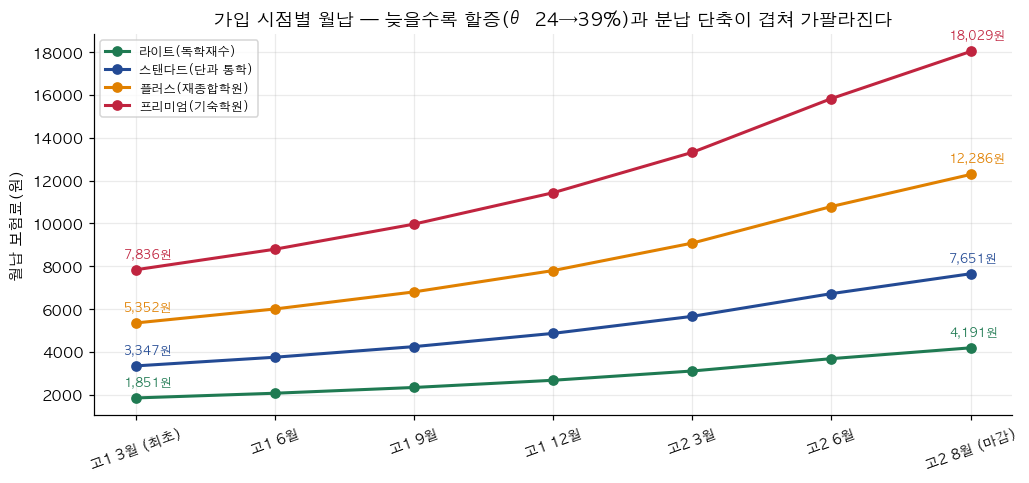

※ 곡선이 직선이 아니라 갈수록 가팔라지는 이유: 총액은 θ만큼 선형으로 늘지만,
  그걸 나누는 분모(잔여 개월)가 동시에 줄어들어 월납은 가속적으로 오른다.


In [50]:
# ── 가입 시점별 가격표: θ(late) 할증 + 분납 단축을 모두 반영한 월납 ──
Δθ = 0.15                                     # 늦은가입 추가할증 폭 (약관 별표2)
총개월, 마감개월 = 33, 16                        # 고1 3월(잔여 33) ~ 고2 8월 마감(잔여 16)

가입시점표 = [("고1 3월 (최초)", 33), ("고1 6월", 30), ("고1 9월", 27), ("고1 12월", 24),
             ("고2 3월", 21), ("고2 6월", 18), ("고2 8월 (마감)", 16)]

def 시점별_보험료(잔여):
    late = 1 - (잔여 - 마감개월) / (총개월 - 마감개월)      # 0(최초) ~ 1(마감)
    θ = THETA + Δθ * late                                   # θ_base=부트스트랩 24% + 늦은가입 할증
    결과 = {}
    for 이름, 형태, 월비용 in 티어정의:
        B경, B중 = 월비용*6*보장률, 월비용*12*보장률
        EL = qm*B경 + qs*B중                                # ★ EL은 가입 시점과 무관 (사고는 수능 1회)
        G  = (EL*(1+θ) + F_정액) / (1 - c_수수료 - v_변동비)
        결과[이름] = (G, G/잔여)                             # (총 영업보험료, 월납)
    return late, θ, 결과

# ── ① 고객용 가격표: 티어 × 가입시점 월납 ──
rows = []
for 시점, 잔여 in 가입시점표:
    late, θ, 결과 = 시점별_보험료(잔여)
    rows.append([시점, 잔여, round(late,2), round(θ*100,1)] + [round(결과[t[0]][1]) for t in 티어정의])
가격표 = pd.DataFrame(rows, columns=["가입 시점","잔여 납입개월","late","θ(%)"]
                                     + [f"{t[0]} 월납(원)" for t in 티어정의])
print("═"*95)
print(" [가입 시점별 월납 보험료]  — 보장 내용은 전 시점 동일, 달라지는 것은 할증(θ)과 분납 개월뿐")
print("═"*95)
print(가격표.to_string(index=False))

# ── ② 스탠다드 티어 상세: 왜 오르는지 두 요인을 분해해서 보여준다 ──
print("\n[스탠다드 티어 상세 — 월납 상승의 두 요인 분해]")
기준월납 = None; rows2 = []
for 시점, 잔여 in 가입시점표:
    late, θ, 결과 = 시점별_보험료(잔여)
    G, 월납 = 결과["스탠다드"]
    if 기준월납 is None: 기준월납 = 월납
    G0 = 결과["스탠다드"][0] / (1+θ) * (1+THETA)            # 할증을 최초 수준으로 되돌린 가상 총액
    rows2.append([시점, f"{G:,.0f}", f"{월납:,.0f}", f"{월납/기준월납:.2f}배",
                  f"+{(G-G0):,.0f}", f"{잔여}개월"])
상세 = pd.DataFrame(rows2, columns=["가입 시점","총 영업보험료","월납","최초 대비","할증 요인(원)","분납 요인"])
print(상세.to_string(index=False))
print("\n→ 총액 증가분('할증 요인')은 순수하게 θ(late) 때문이고, 나머지 월납 상승은 분납 개월 단축 때문이다.")
print(f"→ 고객 안내 문구 예: \"지금(고1 3월) 가입하면 월 {기준월납:,.0f}원, "
      f"고2 8월 마감 직전 가입 시 월 {월납:,.0f}원 — 같은 보장을 {월납/기준월납:.1f}배 비싸게 사게 됩니다.\"")

# ── ③ 시각화: 티어별 월납이 가입 시점에 따라 어떻게 오르는가 ──
fig, ax = plt.subplots(figsize=(9.5, 4.5))
x = np.arange(len(가입시점표))
색 = [GREEN, NAVY, ORANGE, RED]
for (이름, 형태, _), c in zip(티어정의, 색):
    y = [시점별_보험료(잔여)[2][이름][1] for _, 잔여 in 가입시점표]
    ax.plot(x, y, "o-", color=c, lw=2, label=f"{이름}({형태})")
    ax.annotate(f"{y[0]:,.0f}원", (0, y[0]), textcoords="offset points", xytext=(-8,8), fontsize=8, color=c)
    ax.annotate(f"{y[-1]:,.0f}원", (len(x)-1, y[-1]), textcoords="offset points", xytext=(-14,8), fontsize=8, color=c)
ax.set_xticks(x); ax.set_xticklabels([s for s,_ in 가입시점표], rotation=20, fontsize=9)
ax.set_ylabel("월납 보험료(원)")
ax.set_title("가입 시점별 월납 — 늦을수록 할증(θ 24→39%)과 분납 단축이 겹쳐 가팔라진다")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("※ 곡선이 직선이 아니라 갈수록 가팔라지는 이유: 총액은 θ만큼 선형으로 늘지만,")
print("  그걸 나누는 분모(잔여 개월)가 동시에 줄어들어 월납은 가속적으로 오른다.")

In [51]:
상세

,가입 시점,총 영업보험료,월납,최초 대비,할증 요인(원),분납 요인
0,고1 3월 (최초),"110,462","3,347",1.00배,+0,33개월
1,고1 6월,"112,570","3,752",1.12배,"+2,353",30개월
2,고1 9월,"114,678","4,247",1.27배,"+4,696",27개월
3,고1 12월,"116,786","4,866",1.45배,"+7,029",24개월
4,고2 3월,"118,894","5,662",1.69배,"+9,354",21개월
5,고2 6월,"121,003","6,722",2.01배,"+11,670",18개월
6,고2 8월 (마감),"122,408","7,651",2.29배,"+13,210",16개월


In [52]:
# ══════════════════════════════════════════════════════════════════════════
# 고객용 상품 안내표 — 티어별 보장 내용과 보험료를 한 장의 df로
#   (기존 변수 그대로 사용: 티어정의·보장률·qm·qs·THETA·F_정액·c_수수료·v_변동비·납입개월)
# ══════════════════════════════════════════════════════════════════════════
rows = []
for 이름, 형태, 월비용 in 티어정의:
    B_경, B_중 = 월비용*6*보장률, 월비용*12*보장률
    EL = qm*B_경 + qs*B_중
    G  = (EL*(1+THETA) + F_정액) / (1 - c_수수료 - v_변동비)
    rows.append([이름, 형태, 월비용, f"{보장률*100:.0f}%",
                 B_경, "6개월", B_중, "12개월", G, G/납입개월, f"{납입개월}개월"])

고객안내표 = pd.DataFrame(rows, columns=[
    "티어", "대상 재수 형태", "기준 월 학원비(원)", "보장비율",
    "경증 보장금(원)", "경증 보장기간", "중증 보장금(원)", "중증 보장기간",
    "총 보험료(원)", "월납 보험료(원)", "납입기간"])

# 금액 컬럼 천단위 콤마 표시
for c in ["기준 월 학원비(원)", "경증 보장금(원)", "중증 보장금(원)", "총 보험료(원)", "월납 보험료(원)"]:
    고객안내표[c] = 고객안내표[c].round(0).astype(int).map("{:,}".format)

print("═"*110)
print(f" 재수 리스크 보장 상품 안내  (고1 3월 최초 가입 기준 · 보장비율 {보장률*100:.0f}% · 납입 {납입개월}개월)")
print("═"*110)
print(고객안내표.to_string(index=False))
print("""
· 경증 급락 시: 재수 학원비의 70%를 6개월간 보장   · 중증 급락 시: 12개월간 보장
· 급락 판정: 고1~고3 모의고사로 산출한 본인 기준선 대비 수능 성적 이탈 폭 기준 (경증 −1.75σ / 중증 −2.25σ)
· 위 보험료는 고1 3월 가입 기준이며, 가입이 늦을수록 늦은가입 할증과 납입기간 단축으로 월납이 높아집니다 (아래 표)""")

# ── 가입 시점별 월납 조견표 (고객용 부표) ──
rows2 = []
for 시점, 잔여 in 가입시점표:
    late, θ, 결과 = 시점별_보험료(잔여)
    rows2.append([시점, f"{잔여}개월"] + [f"{결과[t[0]][1]:,.0f}" for t in 티어정의])
조견표 = pd.DataFrame(rows2, columns=["가입 시점", "납입기간"] + [f"{t[0]} 월납(원)" for t in 티어정의])
print(조견표.to_string(index=False))

# CSV 저장 (엑셀에서 바로 열림)
고객안내표.to_csv("고객용_상품안내표.csv", index=False, encoding="utf-8-sig")
조견표.to_csv("고객용_가입시점별_월납조견표.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료 → 고객용_상품안내표.csv · 고객용_가입시점별_월납조견표.csv")

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 재수 리스크 보장 상품 안내  (고1 3월 최초 가입 기준 · 보장비율 70% · 납입 33개월)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  티어 대상 재수 형태 기준 월 학원비(원) 보장비율  경증 보장금(원) 경증 보장기간  중증 보장금(원) 중증 보장기간 총 보험료(원) 월납 보험료(원) 납입기간
 라이트     독학재수     500,000  70%  2,100,000     6개월  4,200,000    12개월   61,084     1,851 33개월
스탠다드    단과 통학   1,000,000  70%  4,200,000     6개월  8,400,000    12개월  110,462     3,347 33개월
 플러스    재종합학원   1,670,000  70%  7,014,000     6개월 14,028,000    12개월  176,628     5,352 33개월
프리미엄     기숙학원   2,500,000  70% 10,500,000     6개월 21,000,000    12개월  258,596     7,836 33개월

· 경증 급락 시: 재수 학원비의 70%를 6개월간 보장   · 중증 급락 시: 12개월간 보장
· 급락 판정: 고1~고3 모의고사로 산출한 본인 기준선 대비 수능 성적 이탈 폭 기준 (경증 −1.75σ / 중증 −2.25σ)
· 위 보험료는 고1 3월 가입 기준이며, 가입이 늦을수록 늦은가입 할증과 납입기간 단축으로 월납이 높아집니다 (아래 표)
     가입 시점 납입기간 라이트 월납(원) 스탠다드 월납(원) 플러스 월납(원) 프리미엄 월납(원)
고1

In [53]:
고객안내표

,티어,대상 재수 형태,기준 월 학원비(원),보장비율,경증 보장금(원),경증 보장기간,중증 보장금(원),중증 보장기간,총 보험료(원),월납 보험료(원),납입기간
0,라이트,독학재수,"500,000",70%,"2,100,000",6개월,"4,200,000",12개월,"61,084","1,851",33개월
1,스탠다드,단과 통학,"1,000,000",70%,"4,200,000",6개월,"8,400,000",12개월,"110,462","3,347",33개월
2,플러스,재종합학원,"1,670,000",70%,"7,014,000",6개월,"14,028,000",12개월,"176,628","5,352",33개월
3,프리미엄,기숙학원,"2,500,000",70%,"10,500,000",6개월,"21,000,000",12개월,"258,596","7,836",33개월


In [54]:
조견표

,가입 시점,납입기간,라이트 월납(원),스탠다드 월납(원),플러스 월납(원),프리미엄 월납(원)
0,고1 3월 (최초),33개월,"1,851","3,347","5,352","7,836"
1,고1 6월,30개월,"2,071","3,752","6,005","8,796"
2,고1 9월,27개월,"2,340","4,247","6,803","9,968"
3,고1 12월,24개월,"2,677","4,866","7,800","11,434"
4,고2 3월,21개월,"3,110","5,662","9,081","13,318"
5,고2 6월,18개월,"3,686","6,722","10,791","15,830"
6,고2 8월 (마감),16개월,"4,191","7,651","12,286","18,029"


## ⑯ 예측 모형 — 보험사 내부 포트폴리오 분석 전용 ML

### 목적과 용도 제한 (중요)

이 모형은 **보험료 산정에 절대 사용하지 않는다.** 요율 모형(가구소득·학원밀집도·월교육비)과
분리된 **2모형 구조**의 두 번째 축으로, 용도는 오직 셋이다.

1. **역선택 조기경보** — 가입자 풀의 평균 예측 재수율이 상승하면 "재수 의향이 강한 학생들이
   몰려들고 있다"는 신호. 대응은 개인 요율이 아니라 정책(가입 창·갱신 주기·한도) 변경.
2. **준비금 적정성 점검** — 집합 수준의 기대 손해율 추적.
3. **요율 재산정 트리거** — 예측 손해율과 실적 손해율의 괴리 감시.

### 왜 이 지표들은 요율에서 빼고 예측에서는 쓰는가

공부시간·정시지향·목표대학은 학생이 마음만 먹으면 유리하게 적을 수 있는 **자기신고 지표**라
요율에 넣는 순간 조작 유인이 생긴다(역선택 노출). 그러나 **개별 계약에 아무 영향이 없으면
조작할 이유가 없고**, 포트폴리오 분석은 개인이 아니라 풀의 평균만 본다 — 그래서 예측 모형에서는
가장 강한 예측자들을 제한 없이 쓸 수 있다.

### 예측 지표 구성 (수능 이전 관측치만 — 정보 누출 차단)

| 군 | 지표 | 왜 |
|---|---|---|
| 요율 3지표 | 로그가구소득 · 학원밀집도지수 · 로그월교육비 | 요율 모형과의 비교 기준선 |
| 의도(자기신고) | 정시지향 · 공부시간 · 목표대학권역(학생) · 자기효능감 | 재수 의향과 직결 — 요율 배제/예측 전용 |
| 가정·학교(객관) | 부모기대학력 · 특목/자율고 여부 · 형제서열 | 검정 E에서 확보한 보조 후보 |
| 성적(가입 전) | 성적수준(9회차 평균) · 성적추세(고3−고1) | 가장 강한 관측 신호 — 내부용이므로 사용 |

**제외:** 수능 성적·z·급락 여부(사고 판정 이후 정보), 9차 이후 조사 변수(정답 누출).

In [55]:
# ══════════════════════════════════════════════════════════════════════════
# ⑯ 예측 모형(포트폴리오 전용) — 지표 구성 → LR/GBM/RF 학습 → CV·holdout AUC
#   지표 7개 = 요율 3(로그가구소득·학원밀집도·로그월교육비) + 예측전용 4(정시지향·공부시간·목표대학권역·특목자율고)
#   ★ 이 모형의 출력은 개별 계약의 요율·인수·지급 판단에 사용하지 않는다 — 풀 평균 추적 전용
# ══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import cross_val_score, StratifiedKFold, RepeatedStratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ── ① 자기신고(의도) 지표 로드 + 재코딩 ──
if "정시지향" not in d.columns:
    학생설문 = load(("L2Y8S",), {"L2Y8S44": "공부시간", "L2Y8S61": "수시정시", "L2Y8S56": "목표권역"})
    d = d.merge(학생설문, on="학생ID", how="left")
    d["정시지향"]     = d["수시정시"].map({1: 0.0, 3: 0.5, 2: 1.0})        # 수시0 / 둘다0.5 / 정시1
    d["목표대학권역"] = d["목표권역"].map({1: 2.0, 2: 1.0, 3: 0.0})        # 서울2 / 경기인천1 / 그외0 (해외·기타 결측)

# ── ② 학교유형(객관) — 검정 E를 건너뛰었어도 돌아가도록 가드 ──
if "특목자율고" not in d.columns:
    _stu, _ = pyreadstat.read_sav(find_sav("L2Y8S"), usecols=["L2SID", "L2Y8_SCHID"])
    _sch, _ = pyreadstat.read_sav(find_sav("L2Y8DB"), usecols=["L2Y8_SCHID", "L2Y8_SCHTYPE3_1"])
    d = d.merge(_stu.merge(_sch, on="L2Y8_SCHID", how="left")
                    .rename(columns={"L2SID": "학생ID", "L2Y8_SCHTYPE3_1": "학교유형"})[["학생ID", "학교유형"]],
                on="학생ID", how="left")
    d["특목자율고"] = d["학교유형"].isin([2, 3]).astype(float)             # 자율고·특목고=1, 일반고·특성화=0

# ── ③ 예측지표 7개 확정 + 잔여 결측 중앙값 대치 ──
예측지표 = (요율지표                                   # 요율 3 — 기준선 겸 포함
           + ["정시지향", "공부시간", "목표대학권역"]     # 의도(자기신고) — 요율 배제 / 예측 전용
           + ["특목자율고"])                            # 학교(객관) — 요율 미채택(검정 E: 추가 이득 없음) / 예측 전용
for c in 예측지표:
    d[c] = d[c].fillna(d[c].median())

학습F = 학습[["학생ID", "재수"]].merge(d[["학생ID"] + 예측지표], on="학생ID", how="left")
검증F = 검증[["학생ID", "재수"]].merge(d[["학생ID"] + 예측지표], on="학생ID", how="left")
yF학습, yF검증 = 학습F["재수"].values, 검증F["재수"].values

# ── ④ 단독 AUC 스크리닝 — 어떤 지표가 신호를 갖는지 투명하게 ──
scr = []
for c in 예측지표:
    a = roc_auc_score(d["재수"], d[c]); a = max(a, 1 - a)
    scr.append([c, "요율" if c in 요율지표 else "예측전용", round(a, 3)])
print("[단독 AUC 스크리닝]")
print(pd.DataFrame(scr, columns=["지표", "구분", "단독 AUC"]).sort_values("단독 AUC", ascending=False).to_string(index=False))

# ── ⑤ 모형 3종 — CV AUC + holdout AUC ──
#    반복 CV(5×10, 폴드 50개)는 최종 후보인 로지스틱에만 적용해 SD를 정밀하게 재고,
#    벤치마크용 GBM·RF는 1회 5-fold로 충분(속도 절충). 트리·CV 모두 병렬화.
cv반복 = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
cv단일 = StratifiedKFold(5, shuffle=True, random_state=0)
모형들 = {
    "로지스틱":     make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)),
    "GBM":          GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0),
    "랜덤포레스트":  RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=25,
                                           class_weight="balanced", random_state=0, n_jobs=-1),
}
rows = []
for 이름, m in 모형들.items():
    cv = cross_val_score(m, d[예측지표], d["재수"], scoring="roc_auc", n_jobs=-1,
                         cv=(cv반복 if 이름 == "로지스틱" else cv단일))
    m.fit(학습F[예측지표], yF학습)
    ho = roc_auc_score(yF검증, m.predict_proba(검증F[예측지표])[:, 1])
    rows.append([이름, len(예측지표), "5×10 반복" if 이름 == "로지스틱" else "5-fold",
                 cv.mean(), cv.std(), ho])
비교F = pd.DataFrame(rows, columns=["모형", "지표수", "CV 방식", "CV AUC", "CV SD", "Holdout AUC"])

# ── ⑥ 요율 모형(3지표) 기준선과 비교 ──
#    ※ cross_val_predict는 반복 CV를 지원하지 않으므로(샘플당 예측 1개가 정의 불가) 단일 5-fold 사용
oof요율 = cross_val_predict(LogisticRegression(max_iter=2000), d[요율지표], d["재수"],
                            cv=cv단일, method="predict_proba")[:, 1]
기준 = roc_auc_score(d["재수"], oof요율)

print(f"\n[모형 비교]  (기준선: 요율 3지표 로지스틱 CV AUC {기준:.3f})")
print(비교F.round(4).to_string(index=False))
print(f"\n→ 예측 모형({len(예측지표)}지표)이 요율 모형 대비 AUC를 얼마나 올리는지가 곧")
print("  '요율에는 못 쓰지만 포트폴리오 감시에는 유효한 정보'의 크기다.")
print("★ 이 모형의 출력은 개별 계약의 요율·인수·지급 판단에 사용하지 않는다 — 풀 평균 추적 전용.")

[단독 AUC 스크리닝]
     지표   구분  단독 AUC
   정시지향 예측전용   0.656
 목표대학권역 예측전용   0.619
   월교육비   요율   0.592
   공부시간 예측전용   0.584
   가구소득   요율   0.582
학원밀집도지수   요율   0.567
  특목자율고 예측전용   0.514

[모형 비교]  (기준선: 요율 3지표 로지스틱 CV AUC 0.601)
    모형  지표수   CV 방식  CV AUC  CV SD  Holdout AUC
  로지스틱    7 5×10 반복  0.7045 0.0198       0.7110
   GBM    7  5-fold  0.6761 0.0299       0.6895
랜덤포레스트    7  5-fold  0.6990 0.0236       0.7154

→ 예측 모형(7지표)이 요율 모형 대비 AUC를 얼마나 올리는지가 곧
  '요율에는 못 쓰지만 포트폴리오 감시에는 유효한 정보'의 크기다.
★ 이 모형의 출력은 개별 계약의 요율·인수·지급 판단에 사용하지 않는다 — 풀 평균 추적 전용.


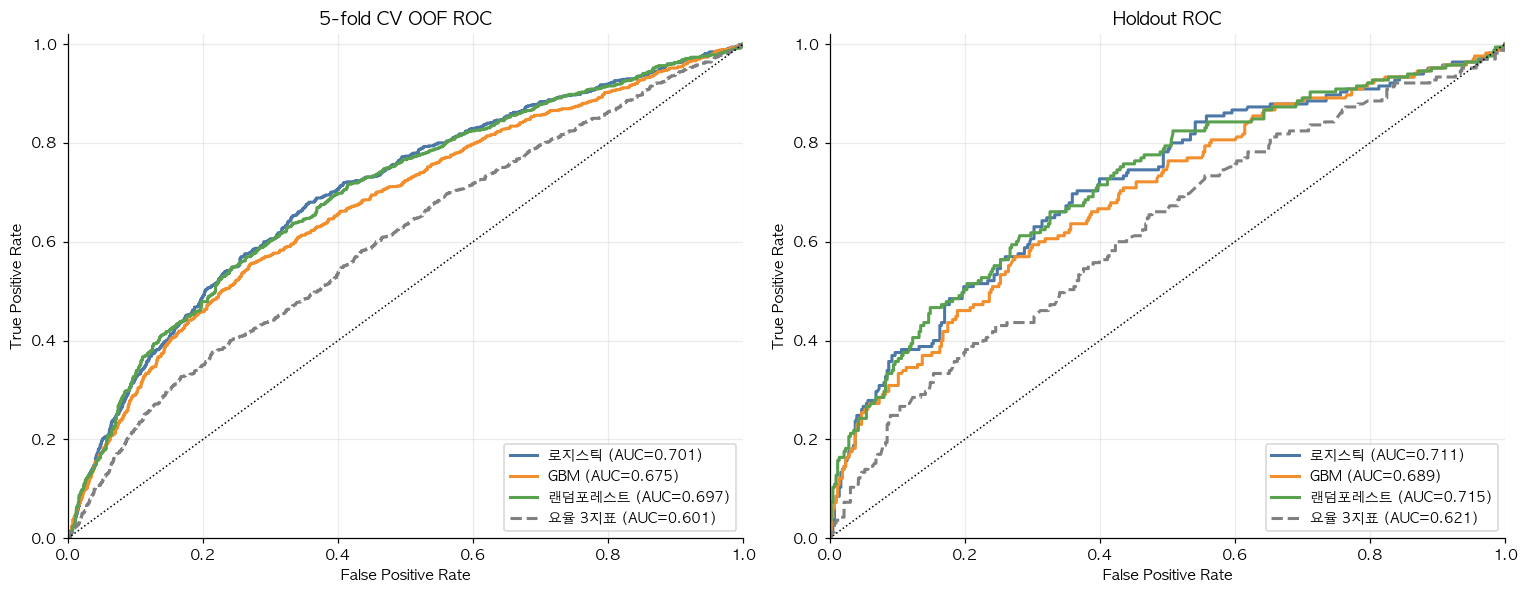

In [56]:
# ── ⑦ ROC-AUC 시각화: CV OOF(좌) + Holdout(우) ──
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.base import clone

색상 = {"로지스틱":"#4C78A8", "GBM":"#F28E2B", "랜덤포레스트":"#59A14F"}
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# CV OOF ROC
for 이름, m in 모형들.items():
    p = cross_val_predict(clone(m), d[예측지표], d["재수"], cv=cv단일, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(d["재수"], p); auc = roc_auc_score(d["재수"], p)
    ax[0].plot(fpr, tpr, lw=2, color=색상[이름], label=f"{이름} (AUC={auc:.3f})")
fpr, tpr, _ = roc_curve(d["재수"], oof요율)
ax[0].plot(fpr, tpr, "--", lw=2, color="gray", label=f"요율 3지표 (AUC={기준:.3f})")

# Holdout ROC
for 이름, m in 모형들.items():
    m = clone(m).fit(학습F[예측지표], yF학습); p = m.predict_proba(검증F[예측지표])[:, 1]
    fpr, tpr, _ = roc_curve(yF검증, p); auc = roc_auc_score(yF검증, p)
    ax[1].plot(fpr, tpr, lw=2, color=색상[이름], label=f"{이름} (AUC={auc:.3f})")
기준모형 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(학습F[요율지표], yF학습)
p = 기준모형.predict_proba(검증F[요율지표])[:, 1]; fpr, tpr, _ = roc_curve(yF검증, p); auc = roc_auc_score(yF검증, p)
ax[1].plot(fpr, tpr, "--", lw=2, color="gray", label=f"요율 3지표 (AUC={auc:.3f})")

for a, 제목 in zip(ax, ["5-fold CV OOF ROC", "Holdout ROC"]):
    a.plot([0,1], [0,1], ":", color="black", lw=1); a.set(xlim=(0,1), ylim=(0,1.02), xlabel="False Positive Rate", ylabel="True Positive Rate", title=제목)
    a.grid(alpha=.25); a.legend(loc="lower right", fontsize=9)

plt.tight_layout(); plt.show()

In [57]:
# 반영비중(과목가중치, 고정) · 밴드모형(회차가중치, OLS 추정) 은
# 노트북을 Run All 한 뒤 메모리에 남아있는 변수를 그대로 씀
print("① 과목별 가중치(고정, 정시 반영비중)")
for 과목, w in 반영비중.items():
    print(f"   {과목}: {w}")

print("\n② 회차별 가중치(OLS 회귀계수, 데이터 추정)")
print(밴드모형.params.round(4).to_string())
print(f"\n   R²={밴드모형.rsquared:.4f}  σ={SIGMA:.4f}등급")

① 과목별 가중치(고정, 정시 반영비중)
   국어: 0.341
   수학: 0.366
   영어: 0.293

② 회차별 가중치(OLS 회귀계수, 데이터 추정)
const      0.6086
고1_3월     -0.0701
고1_6월      0.1356
고1_9월      0.0006
고2_3월      0.0698
고2_6월     -0.0724
고2_9월      0.0555
고3_5월      0.0651
고3_6월      0.0603
고3_9월모평    0.6241

   R²=0.7426  σ=0.7020등급


# 스코어카드 로지스틱 vs ML — 실험·비교 (표 + 시각화)

■ 실험 A — 요율 3지표 동일 조건 (검증셋, §15와 완전히 동일한 모형·하이퍼파라미터)
        모형  검증 AUC(순위력)  Brier(확률정확도↓)         재현성
로지스틱 스코어카드       0.6208         0.1948 해가 유일(결정론적)
       GBM       0.6086         0.1966   난수 시드로 변동
    랜덤포레스트       0.6125         0.2330   난수 시드로 변동 

■ 실험 B — 예측 7지표 (요율 3지표 로지스틱 검증 AUC = 0.621 대비, §16과 완전히 동일한 모형·하이퍼파라미터)
    모형  지표수   CV 방식   CV AUC    CV SD  Holdout AUC
  로지스틱    7 5×10 반복 0.704486 0.019761     0.710954
   GBM    7  5-fold 0.676128 0.029869     0.689483
랜덤포레스트    7  5-fold 0.698986 0.023643     0.715395


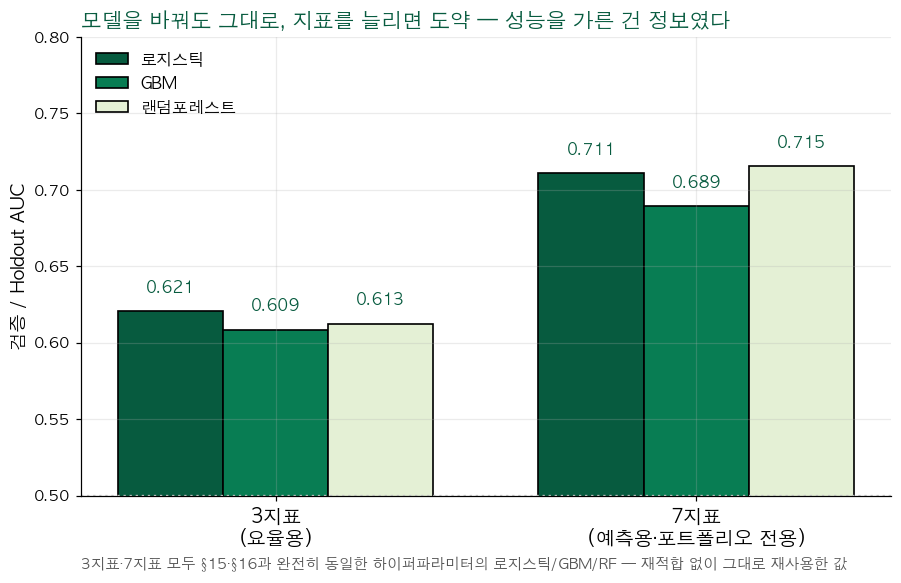

In [62]:
# ============================================================
# [4] 스코어카드 로지스틱 vs ML — 3지표 · 7지표 통합 비교 (표 + 2×2 그룹 막대 하나)
#   ① "더 좋은 모델을 놓친 건 아닌가" → 실험 A(3지표, §15와 동일 모형을 그대로 재사용)
#   ② "지표가 3개뿐이라 약한 건 아닌가" → 실험 B(7지표, §16의 모형들·비교F를 그대로 재사용)
#   ★ 재적합하지 않고 §15·§16에서 이미 학습된 모형/예측값을 그대로 쓴다
#     → 하이퍼파라미터가 달라 숫자가 어긋나는 문제를 원천 차단
# ============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

DEEP, PRI, PALE = '#075B3F', '#087D53', '#E4F0D5'   # 진한 초록 → 중간 초록 → 연한 초록

# ---------- 실험 A: 3지표(요율용) — §15(cell 79)에서 이미 적합된 p_lr·p_gb·p_rf 재사용 ----------
tblA = pd.DataFrame({
    "모형": ["로지스틱 스코어카드", "GBM", "랜덤포레스트"],
    "검증 AUC(순위력)": [roc_auc_score(y검증, p) for p in (p_lr, p_gb, p_rf)],
    "Brier(확률정확도↓)": [brier_score_loss(y검증, p) for p in (p_lr, p_gb, p_rf)],
    "재현성": ["해가 유일(결정론적)", "난수 시드로 변동", "난수 시드로 변동"],
}).round(4)
print("■ 실험 A — 요율 3지표 동일 조건 (검증셋, §15와 완전히 동일한 모형·하이퍼파라미터)")
print(tblA.to_string(index=False), "\n")

# ---------- 실험 B: 7지표(예측용) — §16(cell 98)의 모형들·비교F를 그대로 재사용 ----------
print("■ 실험 B — 예측 7지표 (요율 3지표 로지스틱 검증 AUC = %.3f 대비, §16과 완전히 동일한 모형·하이퍼파라미터)"
      % roc_auc_score(y검증, p_lr))
print(비교F.to_string(index=False))

# ---------- 2×2 그룹 막대 하나로 통합 시각화 ----------
# 3지표는 검증 AUC(tblA), 7지표는 Holdout AUC(비교F) — 둘 다 같은 방식(학습→검증 1회 평가)이라 직접 비교 가능
groups = ["3지표\n(요율용)", "7지표\n(예측용·포트폴리오 전용)"]

로지스틱_auc = [tblA.loc[tblA["모형"] == "로지스틱 스코어카드", "검증 AUC(순위력)"].iloc[0],
             비교F.loc[비교F["모형"] == "로지스틱", "Holdout AUC"].iloc[0]]
GBM_auc = [tblA.loc[tblA["모형"] == "GBM", "검증 AUC(순위력)"].iloc[0],
           비교F.loc[비교F["모형"] == "GBM", "Holdout AUC"].iloc[0]]
RF_auc = [tblA.loc[tblA["모형"] == "랜덤포레스트", "검증 AUC(순위력)"].iloc[0],
          비교F.loc[비교F["모형"] == "랜덤포레스트", "Holdout AUC"].iloc[0]]

x = np.arange(len(groups)); w = 0.25
fig, ax = plt.subplots(figsize=(8.6, 5.4))
bars1 = ax.bar(x - w, 로지스틱_auc, w, label="로지스틱", color=DEEP,
               edgecolor="black", linewidth=1.1)
bars2 = ax.bar(x,     GBM_auc,     w, label="GBM",      color=PRI,
               edgecolor="black", linewidth=1.1)
bars3 = ax.bar(x + w, RF_auc,      w, label="랜덤포레스트", color=PALE,
               edgecolor="black", linewidth=1.1)

for bars, vals in zip([bars1, bars2, bars3], [로지스틱_auc, GBM_auc, RF_auc]):
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}",
                 ha="center", fontsize=10.5, fontweight="bold", color=DEEP)

ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=12.5)
ax.axhline(0.5, color="#cccccc", ls=":")
ax.set_ylim(0.5, 0.80)
ax.set_ylabel("검증 / Holdout AUC", fontsize=12)
ax.set_title("모델을 바꿔도 그대로, 지표를 늘리면 도약 — 성능을 가른 건 정보였다",
             fontsize=13.5, fontweight="bold", loc="left", color=DEEP)
ax.legend(frameon=False, loc="upper left", fontsize=10.5)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0, -0.16,
        "3지표·7지표 모두 §15·§16과 완전히 동일한 하이퍼파라미터의 로지스틱/GBM/RF — 재적합 없이 그대로 재사용한 값",
        transform=ax.transAxes, fontsize=9.5, color="#555555")
plt.tight_layout()
plt.savefig("model_vs_indicator.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

In [59]:
tblA

,모형,검증 AUC(순위력),Brier(확률정확도↓),재현성
0,로지스틱 스코어카드,0.6208,0.1948,해가 유일(결정론적)
1,GBM,0.6086,0.1966,난수 시드로 변동
2,랜덤포레스트,0.6125,0.2330,난수 시드로 변동


In [63]:
# ---------- tblA를 깔끔한 스타일 DataFrame으로 출력 ----------
def _hex_tint(hex_color, factor):
    """hex_color를 factor(0=원색, 1=흰색)만큼 밝게 섞는다."""
    hex_color = hex_color.lstrip("#")
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

BASE = "#087d53"
행배경 = [_hex_tint(BASE, 0.90), _hex_tint(BASE, 0.94), _hex_tint(BASE, 0.90)]  # 로지스틱 행만 살짝 더 진하게 강조

tblA_styled = (
    tblA.style
        .set_caption("실험 A — 요율 3지표 동일 조건 비교 (검증셋)")
        .set_table_styles([
            {"selector": "caption",
             "props": [("caption-side", "top"), ("font-weight", "bold"),
                       ("font-size", "14px"), ("color", BASE), ("padding-bottom", "8px")]},
            {"selector": "th",
             "props": [("background-color", BASE), ("color", "white"),
                       ("font-weight", "bold"), ("text-align", "center"),
                       ("padding", "8px 12px"), ("border", "1px solid " + BASE)]},
            {"selector": "td",
             "props": [("text-align", "center"), ("padding", "7px 12px"),
                       ("border", "1px solid #d8ece5")]},
        ])
        .apply(lambda col: [f"background-color: {행배경[i]}" for i in range(len(tblA))], axis=0)
        .format({"검증 AUC(순위력)": "{:.4f}", "Brier(확률정확도↓)": "{:.4f}"})
        .hide(axis="index")
)
tblA_styled

모형,검증 AUC(순위력),Brier(확률정확도↓),재현성
로지스틱 스코어카드,0.6208,0.1948,해가 유일(결정론적)
GBM,0.6086,0.1966,난수 시드로 변동
랜덤포레스트,0.6125,0.2330,난수 시드로 변동


■ 실험 A — 요율 3지표 동일 조건 (홀드아웃셋, §15와 완전히 동일한 모형·하이퍼파라미터)
        모형  홀드아웃 AUC(순위력)  Brier(확률정확도↓)         재현성
로지스틱 스코어카드         0.6208         0.1948 해가 유일(결정론적)
       GBM         0.6086         0.1966   난수 시드로 변동
    랜덤포레스트         0.6125         0.2330   난수 시드로 변동 



모형,홀드아웃 AUC(순위력),Brier(확률정확도↓),재현성
로지스틱 스코어카드,0.6208,0.1948,해가 유일(결정론적)
GBM,0.6086,0.1966,난수 시드로 변동
랜덤포레스트,0.6125,0.2330,난수 시드로 변동



■ 실험 B — 예측 7지표 (요율 3지표 로지스틱 홀드아웃 AUC = 0.621 대비, §16과 완전히 동일한 모형·하이퍼파라미터)
    모형  지표수   CV 방식   CV AUC    CV SD  Holdout AUC
  로지스틱    7 5×10 반복 0.704486 0.019761     0.710954
   GBM    7  5-fold 0.676128 0.029869     0.689483
랜덤포레스트    7  5-fold 0.698986 0.023643     0.715395


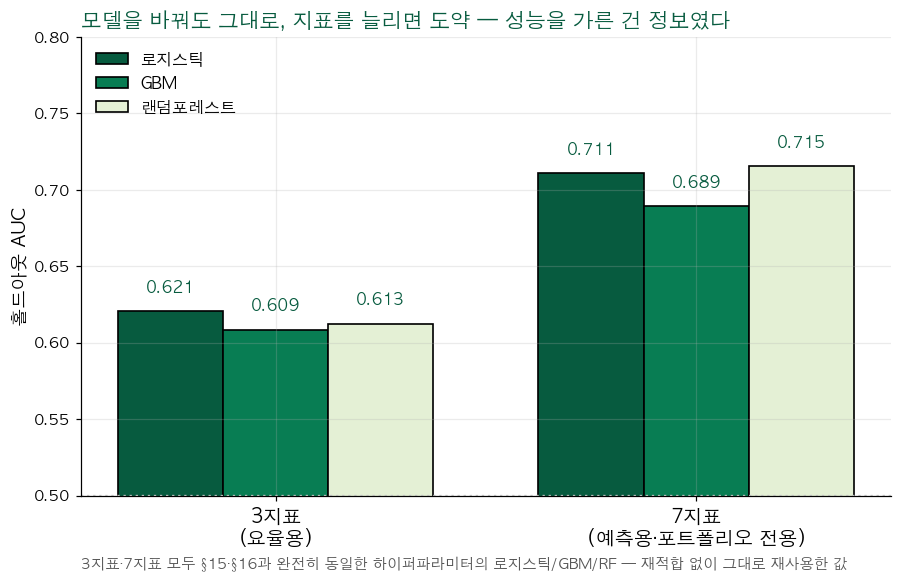

In [64]:
# ============================================================
# [4] 스코어카드 로지스틱 vs ML — 3지표 · 7지표 통합 비교 (표 + 2×2 그룹 막대 하나)
#   ① "더 좋은 모델을 놓친 건 아닌가" → 실험 A(3지표, §15와 동일 모형을 그대로 재사용)
#   ② "지표가 3개뿐이라 약한 건 아닌가" → 실험 B(7지표, §16의 모형들·비교F를 그대로 재사용)
#   ★ 재적합하지 않고 §15·§16에서 이미 학습된 모형/예측값을 그대로 쓴다
#     → 하이퍼파라미터가 달라 숫자가 어긋나는 문제를 원천 차단
# ============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

DEEP, PRI, PALE = '#075B3F', '#087D53', '#E4F0D5'   # 진한 초록 → 중간 초록 → 연한 초록
BASE = '#087d53'                                     # 표 스타일용 기준색

# ---------- 실험 A: 3지표(요율용) — §15(cell 79)에서 이미 적합된 p_lr·p_gb·p_rf 재사용 ----------
tblA = pd.DataFrame({
    "모형": ["로지스틱 스코어카드", "GBM", "랜덤포레스트"],
    "홀드아웃 AUC(순위력)": [roc_auc_score(y검증, p) for p in (p_lr, p_gb, p_rf)],
    "Brier(확률정확도↓)": [brier_score_loss(y검증, p) for p in (p_lr, p_gb, p_rf)],
    "재현성": ["해가 유일(결정론적)", "난수 시드로 변동", "난수 시드로 변동"],
}).round(4)
print("■ 실험 A — 요율 3지표 동일 조건 (홀드아웃셋, §15와 완전히 동일한 모형·하이퍼파라미터)")
print(tblA.to_string(index=False), "\n")

# ---------- tblA를 깔끔한 스타일 DataFrame으로 출력 ----------
def _hex_tint(hex_color, factor):
    """hex_color를 factor(0=원색, 1=흰색)만큼 밝게 섞는다."""
    hex_color = hex_color.lstrip("#")
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

행배경 = [_hex_tint(BASE, 0.90), _hex_tint(BASE, 0.94), _hex_tint(BASE, 0.90)]  # 로지스틱 행만 살짝 더 진하게 강조

tblA_styled = (
    tblA.style
        .set_caption("실험 A — 요율 3지표 동일 조건 비교 (홀드아웃셋)")
        .set_table_styles([
            {"selector": "caption",
             "props": [("caption-side", "top"), ("font-weight", "bold"),
                       ("font-size", "14px"), ("color", BASE), ("padding-bottom", "8px")]},
            {"selector": "th",
             "props": [("background-color", BASE), ("color", "white"),
                       ("font-weight", "bold"), ("text-align", "center"),
                       ("padding", "8px 12px"), ("border", "1px solid " + BASE)]},
            {"selector": "td",
             "props": [("text-align", "center"), ("padding", "7px 12px"),
                       ("border", "1px solid #d8ece5")]},
        ])
        .apply(lambda col: [f"background-color: {행배경[i]}" for i in range(len(tblA))], axis=0)
        .format({"홀드아웃 AUC(순위력)": "{:.4f}", "Brier(확률정확도↓)": "{:.4f}"})
        .hide(axis="index")
)
display(tblA_styled)

# ---------- 실험 B: 7지표(예측용) — §16(cell 98)의 모형들·비교F를 그대로 재사용 ----------
print("\n■ 실험 B — 예측 7지표 (요율 3지표 로지스틱 홀드아웃 AUC = %.3f 대비, §16과 완전히 동일한 모형·하이퍼파라미터)"
      % roc_auc_score(y검증, p_lr))
print(비교F.to_string(index=False))

# ---------- 2×2 그룹 막대 하나로 통합 시각화 ----------
# 3지표·7지표 모두 홀드아웃(검증)셋 1회 평가 값이라 직접 비교 가능
groups = ["3지표\n(요율용)", "7지표\n(예측용·포트폴리오 전용)"]

로지스틱_auc = [tblA.loc[tblA["모형"] == "로지스틱 스코어카드", "홀드아웃 AUC(순위력)"].iloc[0],
             비교F.loc[비교F["모형"] == "로지스틱", "Holdout AUC"].iloc[0]]
GBM_auc = [tblA.loc[tblA["모형"] == "GBM", "홀드아웃 AUC(순위력)"].iloc[0],
           비교F.loc[비교F["모형"] == "GBM", "Holdout AUC"].iloc[0]]
RF_auc = [tblA.loc[tblA["모형"] == "랜덤포레스트", "홀드아웃 AUC(순위력)"].iloc[0],
          비교F.loc[비교F["모형"] == "랜덤포레스트", "Holdout AUC"].iloc[0]]

x = np.arange(len(groups)); w = 0.25
fig, ax = plt.subplots(figsize=(8.6, 5.4))
bars1 = ax.bar(x - w, 로지스틱_auc, w, label="로지스틱", color=DEEP,
               edgecolor="black", linewidth=1.1)
bars2 = ax.bar(x,     GBM_auc,     w, label="GBM",      color=PRI,
               edgecolor="black", linewidth=1.1)
bars3 = ax.bar(x + w, RF_auc,      w, label="랜덤포레스트", color=PALE,
               edgecolor="black", linewidth=1.1)

for bars, vals in zip([bars1, bars2, bars3], [로지스틱_auc, GBM_auc, RF_auc]):
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}",
                 ha="center", fontsize=10.5, fontweight="bold", color=DEEP)

ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=12.5)
ax.axhline(0.5, color="#cccccc", ls=":")
ax.set_ylim(0.5, 0.80)
ax.set_ylabel("홀드아웃 AUC", fontsize=12)
ax.set_title("모델을 바꿔도 그대로, 지표를 늘리면 도약 — 성능을 가른 건 정보였다",
             fontsize=13.5, fontweight="bold", loc="left", color=DEEP)
ax.legend(frameon=False, loc="upper left", fontsize=10.5)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0, -0.16,
        "3지표·7지표 모두 §15·§16과 완전히 동일한 하이퍼파라미터의 로지스틱/GBM/RF — 재적합 없이 그대로 재사용한 값",
        transform=ax.transAxes, fontsize=9.5, color="#555555")
plt.tight_layout()
plt.savefig("model_vs_indicator.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

## ⑰ 요약 — 요율 모형 vs 예측 모형 AUC 비교 (발표용)

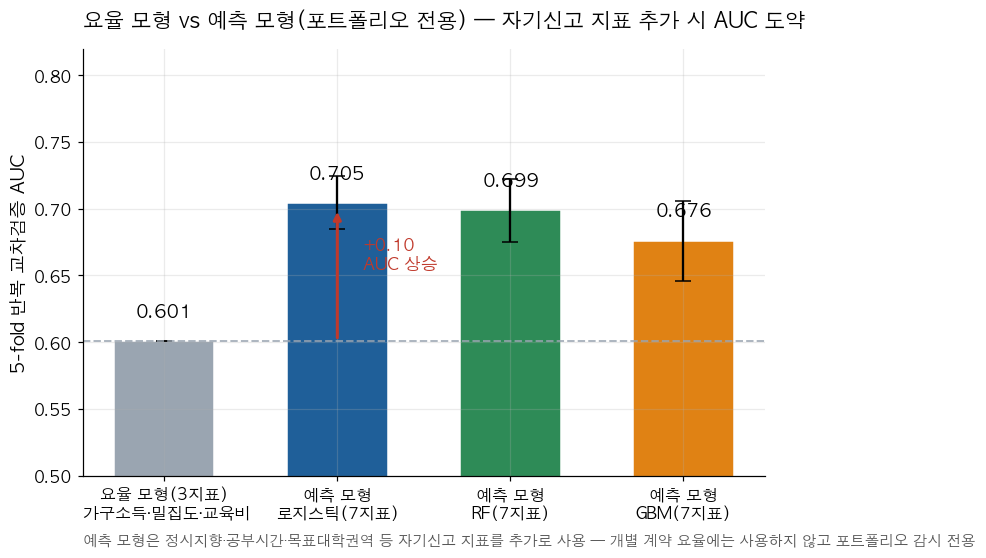

In [61]:
import matplotlib.pyplot as plt

NAVY, GREY, ORANGE, GREEN, RED = '#1f5f99','#9aa5b1','#e08214','#2e8b57','#c0392b'

labels = ["요율 모형(3지표)\n 가구소득·밀집도·교육비", "예측 모형\n로지스틱(7지표)", "예측 모형\nRF(7지표)", "예측 모형\nGBM(7지표)"]
cv_auc = [0.601, 0.7045, 0.6990, 0.6761]
cv_sd  = [0.0,   0.0198, 0.0236, 0.0299]
colors = [GREY, NAVY, GREEN, ORANGE]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
bars = ax.bar(labels, cv_auc, yerr=cv_sd, color=colors, width=0.58, capsize=5, edgecolor="white")
for b, v in zip(bars, cv_auc):
    ax.text(b.get_x()+b.get_width()/2, v+0.018, f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")

ax.axhline(0.601, color=GREY, ls="--", lw=1.3, alpha=.8)
ax.annotate("", xy=(1, 0.70), xytext=(1, 0.601), arrowprops=dict(arrowstyle="-|>", color=RED, lw=2))
ax.text(1.15, 0.655, "+0.10\nAUC 상승", color=RED, fontsize=11, fontweight="bold")

ax.set_ylim(0.5, 0.82)
ax.set_ylabel("5-fold 반복 교차검증 AUC", fontsize=12)
ax.set_title("요율 모형 vs 예측 모형(포트폴리오 전용) — 자기신고 지표 추가 시 AUC 도약",
             fontsize=13.5, fontweight="bold", pad=14, loc="left")
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10.5)
ax.text(0, -0.16, "예측 모형은 정시지향·공부시간·목표대학권역 등 자기신고 지표를 추가로 사용 — "
                  "개별 계약 요율에는 사용하지 않고 포트폴리오 감시 전용",
        transform=ax.transAxes, fontsize=9.5, color="#555")
plt.tight_layout()
plt.savefig("auc_jump.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
